# Hello, KAN!

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

Initialize KAN

In [28]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[34,10,3], grid=10, k=3, seed=42, device=device)


cuda
checkpoint directory created: ./model
saving model version 0.0


Create dataset output_one

In [27]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# ---------- 1. 基本设置 ----------
torch.set_default_dtype(torch.float64)

csv_path = "0-MY-DATASET-RR.csv"   # 确保路径正确（与你的 notebook 同级）

# ---------- 2. 读取 CSV ----------
df = pd.read_csv(csv_path)

print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- 3. 拆分特征与标签 ----------
# 前 34 列：特征
X = df.iloc[:, 0:34].apply(pd.to_numeric, errors='coerce')

# 第 35 列：信任度等级标签 (1/2/3)
y = pd.to_numeric(df.iloc[:, 34], errors='coerce')

# ---------- 4. 数据清洗 ----------
# 去掉含 NaN 的样本
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# 只保留合法标签 1/2/3
valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

# ---------- 5. numpy 化 ----------
X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.float64)

# ---------- 6. 训练 / 测试集划分 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y   # 保持 1/2/3 比例一致（非常重要）
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# ---------- 7. 特征标准化（强烈建议） ----------
# ⚠️ 只用训练集统计量，防止信息泄露
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# ---------- 8. 转为 torch Tensor ----------
X_train_t = torch.tensor(X_train, device=device)
X_test_t  = torch.tensor(X_test,  device=device)

# KAN 输出推荐使用 (N, 1)
y_train_t = torch.tensor(y_train, device=device).reshape(-1, 1)
y_test_t  = torch.tensor(y_test,  device=device).reshape(-1, 1)

# ---------- 9. 组装成 KAN 标准 dataset ----------
dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

# ---------- 10. sanity check ----------
print("dataset['train_input']:", dataset['train_input'].shape)
print("dataset['train_label']:", dataset['train_label'].shape)
#print("Unique labels in train:", torch.unique(dataset['train_label']))

def to_cpu_dataset(dataset):
    return {
        'train_input': dataset['train_input'].detach().cpu().double(),
        'train_label': dataset['train_label'].detach().cpu().double(),
        'test_input' : dataset['test_input'].detach().cpu().double(),
        'test_label' : dataset['test_label'].detach().cpu().double(),
    }

dataset_cpu = to_cpu_dataset(dataset)


Raw data shape: (10185, 35)
Columns: ['ECG_Max', 'ECG_SD', 'alpha_psd', 'ECG_Mean', 'ECG_Q1', 'delta_amp', 'ECG_Q2', 'ECG_Q3', 'beta_amp', 'ECG_AVHR', 'ECG_IBI', 'theta_psd', 'ECG_RMSSD', 'time_std', 'theta_amp', 'ECG_pNN20', 'ECG_pNN50', 'beta_psd', 'EDA_SC', 'EDA_SCL', 'alpha_amp', 'EDA_SCR', 'EDA_Max', 'EDA_SD', 'delta_psd', 'EDA_Mean', 'EDA_Q1', 'EDA_Q2', 'EDA_Q3', 'time_mean', 'time_max', 'time_min', 'time_skew', 'time_kurtosis', 'trust level']
Cleaned samples: 10143
Train samples: 8114
Test samples : 2029
dataset['train_input']: torch.Size([8114, 34])
dataset['train_label']: torch.Size([8114, 1])


Create dataset output_three

In [29]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# ---------- 1. 基本设置 ----------
torch.set_default_dtype(torch.float64)

csv_path = "0-MY-DATASET-RR.csv"   # 确保路径正确（与你的 notebook 同级）

# ---------- 2. 读取 CSV ----------
df = pd.read_csv(csv_path)

print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- 3. 拆分特征与标签 ----------
# 前 34 列：特征
X = df.iloc[:, 0:34].apply(pd.to_numeric, errors='coerce')

# 第 35 列：信任度等级标签 (1/2/3)
y = pd.to_numeric(df.iloc[:, 34], errors='coerce')

# ---------- 4. 数据清洗 ----------
# 去掉含 NaN 的样本
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# 只保留合法标签 1/2/3
valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

# ---------- 5. numpy 化 ----------
X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.float64)

# ---------- 6. 训练 / 测试集划分 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y   # 保持 1/2/3 比例一致（非常重要）
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# ---------- 7. 特征标准化（强烈建议） ----------
# ⚠️ 只用训练集统计量，防止信息泄露
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# ---------- 8. 转为 torch Tensor ----------
X_train_t = torch.tensor(X_train, device=device)
X_test_t  = torch.tensor(X_test,  device=device)

# KAN 输出推荐使用 (N, 1)
y_train_t = torch.tensor(y_train, device=device).long() - 1   # 1/2/3 -> 0/1/2, shape (N,)
y_test_t  = torch.tensor(y_test,  device=device).long() - 1

# ---------- 9. 组装成 KAN 标准 dataset ----------
dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

# ---------- 10. sanity check ----------
print("dataset['train_input']:", dataset['train_input'].shape)
print("dataset['train_label']:", dataset['train_label'].shape)
#print("Unique labels in train:", torch.unique(dataset['train_label']))

def to_cpu_dataset(dataset):
    return {
        'train_input': dataset['train_input'].detach().cpu().double(),
        'train_label': dataset['train_label'].detach().cpu().long(),
        'test_input' : dataset['test_input'].detach().cpu().double(),
        'test_label' : dataset['test_label'].detach().cpu().long(),
    }

dataset_cpu = to_cpu_dataset(dataset)


Raw data shape: (10185, 35)
Columns: ['ECG_Max', 'ECG_SD', 'alpha_psd', 'ECG_Mean', 'ECG_Q1', 'delta_amp', 'ECG_Q2', 'ECG_Q3', 'beta_amp', 'ECG_AVHR', 'ECG_IBI', 'theta_psd', 'ECG_RMSSD', 'time_std', 'theta_amp', 'ECG_pNN20', 'ECG_pNN50', 'beta_psd', 'EDA_SC', 'EDA_SCL', 'alpha_amp', 'EDA_SCR', 'EDA_Max', 'EDA_SD', 'delta_psd', 'EDA_Mean', 'EDA_Q1', 'EDA_Q2', 'EDA_Q3', 'time_mean', 'time_max', 'time_min', 'time_skew', 'time_kurtosis', 'trust level']
Cleaned samples: 10143
Train samples: 8114
Test samples : 2029
dataset['train_input']: torch.Size([8114, 34])
dataset['train_label']: torch.Size([8114])


In [30]:
import copy
import torch

import torch.nn.functional as F
def ce_loss(logits, y):
    return F.cross_entropy(logits, y)

def cpu_grid_update_once(model, dataset_cpu,
                         opt="LBFGS",
                         steps=5,
                         lamb=0.001,
                         grid_update_num=1,
                         start_grid_update_step=0,
                         stop_grid_update_step=5,
                         verbose=1):
    """
    在 CPU 上短跑几步 + update_grid=True，让 grid/coef 更新完成。
    返回搬回 GPU 的 model（参数已更新）。
    """
    # 1) 深拷贝到 CPU，避免影响你 GPU 上的对象引用
    model_cpu = copy.deepcopy(model).to("cpu").double()

    # 2) CPU 上做 grid update（短跑）
    model_cpu.fit(
        dataset_cpu,
        opt=opt,
        steps=steps,
        lamb=lamb,
        update_grid=True,
        grid_update_num=grid_update_num,
        start_grid_update_step=start_grid_update_step,
        stop_grid_update_step=stop_grid_update_step,
        loss_fn=ce_loss,   # <-- 新增这一行
    )

    # 3) 搬回原 device（cuda）
    model_gpu = model_cpu.to(model.device)
    return model_gpu


In [ ]:

# 进行一次 CPU grid update（只更新grid，不追求收敛）
model = cpu_grid_update_once(
    model,
    dataset_cpu,
    opt="LBFGS",
    steps=5,
    lamb=0.001,
    grid_update_num=1,
    start_grid_update_step=0,
    stop_grid_update_step=5,
)

# 回到 GPU 再训练
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=False)

| train_loss: 4.73e-01 | test_loss: 4.91e-01 | reg: 2.59e+01 | : 100%|█| 5/5 [00:03<00:00,  1.33it/s


saving model version 0.1


| train_loss: 3.93e-01 | test_loss: 4.13e-01 | reg: 2.11e+01 | : 100%|█| 50/50 [00:08<00:00,  6.20it

saving model version 0.2


{'train_loss': [array(0.46770615),
  array(0.45928698),
  array(0.44646316),
  array(0.43867487),
  array(0.43369974),
  array(0.4286983),
  array(0.42470258),
  array(0.4217431),
  array(0.41846819),
  array(0.41628108),
  array(0.41479903),
  array(0.41299925),
  array(0.41190196),
  array(0.41078153),
  array(0.40971533),
  array(0.40840505),
  array(0.40726823),
  array(0.4061789),
  array(0.40548282),
  array(0.40457178),
  array(0.40366199),
  array(0.40297139),
  array(0.40240524),
  array(0.40199838),
  array(0.40167285),
  array(0.40127461),
  array(0.4009825),
  array(0.40082097),
  array(0.40048944),
  array(0.40009888),
  array(0.39979128),
  array(0.39921813),
  array(0.3987823),
  array(0.39822707),
  array(0.39771077),
  array(0.39730846),
  array(0.39674601),
  array(0.39625059),
  array(0.39586421),
  array(0.39558812),
  array(0.39536886),
  array(0.39503288),
  array(0.39476502),
  array(0.39454299),
  array(0.39436859),
  array(0.39419879),
  array(0.39407308),
  ar

In [31]:
import torch.nn.functional as F
def ce_loss(logits, y):
    return F.cross_entropy(logits, y)

# 进行一次 CPU grid update（只更新grid，不追求收敛）
model = cpu_grid_update_once(
    model,
    dataset_cpu,
    opt="LBFGS",
    steps=5,
    lamb=0.001,
    grid_update_num=1,
    start_grid_update_step=0,
    stop_grid_update_step=5,
)

# 回到 GPU 再训练
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=False, loss_fn=ce_loss)

| train_loss: 4.67e-01 | test_loss: 5.74e-01 | reg: 6.98e+01 | : 100%|█| 5/5 [00:14<00:00,  2.88s/it


saving model version 0.1


| train_loss: 9.35e-02 | test_loss: 7.52e-01 | reg: 7.78e+01 | : 100%|█| 50/50 [00:11<00:00,  4.21it

saving model version 0.2


{'train_loss': [array(0.44662744),
  array(0.4166096),
  array(0.38620631),
  array(0.354103),
  array(0.32555805),
  array(0.29778973),
  array(0.27339027),
  array(0.25431701),
  array(0.23740473),
  array(0.22165376),
  array(0.20800761),
  array(0.19463121),
  array(0.18321284),
  array(0.17126895),
  array(0.16157082),
  array(0.15219233),
  array(0.14484101),
  array(0.1375313),
  array(0.13160562),
  array(0.12569095),
  array(0.12116771),
  array(0.11622577),
  array(0.11269701),
  array(0.10975449),
  array(0.1071301),
  array(0.10482905),
  array(0.10251223),
  array(0.10114439),
  array(0.0997716),
  array(0.09878),
  array(0.09851681),
  array(0.09803843),
  array(0.0971949),
  array(0.09691061),
  array(0.09684226),
  array(0.09623781),
  array(0.09598411),
  array(0.09582653),
  array(0.0959716),
  array(0.09656776),
  array(0.09701164),
  array(0.09673742),
  array(0.09639996),
  array(0.09598697),
  array(0.09532055),
  array(0.09462154),
  array(0.09389992),
  array(0.

In [6]:
# =========================================================
# SHAP importance for KAN (3-class)
# Export Top-10 mean(|SHAP|) per class to .mat for MATLAB
# =========================================================
import numpy as np
import torch
import shap
from scipy.io import savemat

# -----------------------------
# 0) 你已有：model, dataset, df (或 feature names)
#    确保 model 已训练好
# -----------------------------
model.eval()

# 1) 特征名（来自CSV前34列）
# 如果你还保留 df：names = df.columns[:34].tolist()
# 否则你可以自己给 feature_names 一个列表
try:
    feature_names = df.columns[:34].tolist()
except Exception:
    feature_names = [f"F{i+1}" for i in range(34)]

# 2) 取用于解释的数据（建议用 test set）
# SHAP 计算量大：解释样本数不要太多（例如 256~1024）
X_test = dataset["test_input"].detach()
y_test = dataset["test_label"].detach()

# 3) 选择背景集（background）与解释集（explain）
# background 常用：从训练集抽样 100~512
X_train = dataset["train_input"].detach()

rng = np.random.default_rng(42)
def sample_rows(X, n):
    n = min(n, X.shape[0])
    idx = rng.choice(X.shape[0], size=n, replace=False)
    return X[idx]

background_size = 256   # 你可以改 128/256/512
explain_size    = 512   # 你可以改 256/512/1024

X_bg = sample_rows(X_train, background_size)
X_ex = sample_rows(X_test, explain_size)

# 4) 为 SHAP 包装一个“只做前向”的模型函数（输出 logits: (N,3)）
# 注意：SHAP 对 PyTorch 一般用 CPU 更稳
# 你也可以强制用 GPU：shap_device="cuda"
shap_device = "cpu"  # 推荐先用 cpu；如果你确认 shap 在 cuda 可用再改 "cuda"

model_shap = model.to(shap_device)
X_bg_shap  = X_bg.to(shap_device)
X_ex_shap  = X_ex.to(shap_device)

# 5) 选择 SHAP explainer
# GradientExplainer：对一般 torch 网络比较通用
# DeepExplainer：有时更快，但对某些算子可能不支持
use_deep = False

with torch.no_grad():
    _ = model_shap(X_bg_shap[:2])  # warm-up forward

if use_deep:
    explainer = shap.DeepExplainer(model_shap, X_bg_shap)
else:
    explainer = shap.GradientExplainer(model_shap, X_bg_shap)

# 6) 计算 shap values
# 多分类返回 list，长度=3，每个元素形状 (N, 34, 3?) 或 (N,34) 取决于实现
# 对于输出 (N,3)，常见：list[cls] -> (N, 34)
shap_values = explainer.shap_values(X_ex_shap)

# 7) 统一 shap_values 形状为 (C, N, D)
#    C=3, D=34
def to_CND(shap_values, num_classes=3):
    # shap_values is usually a list length C
    if isinstance(shap_values, list):
        arrs = []
        for c in range(num_classes):
            sv = shap_values[c]
            sv = np.array(sv)
            # 期望 (N,D)
            if sv.ndim == 3:
                # 有的实现会给 (N,D,1) 或 (N,D,K)，取最后一维压掉
                sv = sv[..., 0]
            arrs.append(sv)
        return np.stack(arrs, axis=0)  # (C,N,D)
    else:
        # 某些情况下直接给 (N,D,C)
        sv = np.array(shap_values)
        if sv.ndim == 3 and sv.shape[-1] == num_classes:
            sv = np.transpose(sv, (2,0,1))  # (C,N,D)
            return sv
        raise ValueError(f"Unexpected shap_values shape/type: {type(shap_values)}, shape={getattr(sv,'shape',None)}")

SV = to_CND(shap_values, num_classes=3)  # (3, N, 34)

# 8) 计算每个特征在每个类别上的 mean(|SHAP|)
mean_abs = np.mean(np.abs(SV), axis=1)   # (3, 34)

# 9) 排序取 Top-10（按三个类别总和）
total_imp = mean_abs.sum(axis=0)         # (34,)
topk = 10
top_idx = np.argsort(-total_imp)[:topk]  # descending

# Top-10 数据
top_feature_names = [feature_names[i] for i in top_idx]
top_mean_abs = mean_abs[:, top_idx]      # (3, topk)

# 10) 为 MATLAB 输出：建议顺序 Low/Medium/High
# 你的标签是 0/1/2 对应原始 1/2/3，这里我们把 class_names 写成 Low/Medium/High
class_names = ["Low", "Medium", "High"]

# 11) 存 .mat
out_mat = "shap_top10_KAN_trust.mat"
savemat(out_mat, {
    "feature_names": np.array(top_feature_names, dtype=object),
    "class_names":   np.array(class_names, dtype=object),
    "mean_abs_shap": top_mean_abs,      # (3,10)
    "top_idx_0based": top_idx.astype(np.int64),
    "total_importance": total_imp[top_idx],  # (10,)
})

print(f"[OK] Saved SHAP Top-10 to: {out_mat}")
print("Top-10 features:", top_feature_names)
print("mean(|SHAP|) per class (rows=Low/Medium/High):\n", top_mean_abs)


[OK] Saved SHAP Top-10 to: shap_top10_KAN_trust.mat
Top-10 features: ['time_min', 'ECG_Q2', 'time_mean', 'ECG_SD', 'EDA_Max', 'time_max', 'ECG_Max', 'EDA_Q1', 'ECG_IBI', 'ECG_Q1']
mean(|SHAP|) per class (rows=Low/Medium/High):
 [[2.46386053 1.08944971 2.66518887 2.06482373 2.06061724 2.75835719
  2.51279373 1.37257678 1.40937639 1.12413182]
 [3.07313262 3.15738145 1.97256555 2.44012172 2.84783526 2.65737499
  2.00561141 2.64121128 2.61522471 2.14387339]
 [4.56849792 3.40777756 2.95166523 2.559302   1.76432464 1.15573075
  1.80341373 2.20859789 1.72995553 1.16644739]]


In [25]:
# ==========================================
# Robust SHAP export for 3-class model -> .mat
# Works for shap_values being:
#   1) list of 3 arrays, each (N,F)
#   2) ndarray (N,F,3)
#   3) ndarray (3,N,F)
# Ensures per-class shap_top and x_top are (N,K)
# ==========================================
import numpy as np
import torch
from scipy.io import savemat

torch.set_default_dtype(torch.float64)
model.eval()

# ----------------------------
# 0) Inputs you already have
# ----------------------------
# dataset["train_input"], dataset["test_input"] are torch tensors (on GPU)
X_train_t = dataset["train_input"]
X_test_t  = dataset["test_input"]

# Feature names (建议用真实列名)
# feature_names = df.columns[:34].tolist()
feature_names = [f"f{i+1}" for i in range(34)]

class_names = ["Low", "Medium", "High"]   # labels 0/1/2
topk = 5

# ----------------------------
# 1) Build background & explain set
# ----------------------------
bg_size = min(512, X_train_t.shape[0])
idx_bg = torch.randperm(X_train_t.shape[0], device=X_train_t.device)[:bg_size]
X_bg = X_train_t[idx_bg].detach()

# 你可以解释全部 test，也可以只取 512 个加速
# X_explain = X_test_t.detach()
explain_size = min(512, X_test_t.shape[0])
idx_ex = torch.randperm(X_test_t.shape[0], device=X_test_t.device)[:explain_size]
X_explain = X_test_t[idx_ex].detach()

X_explain_cpu = X_explain.detach().cpu().numpy()
N, F = X_explain_cpu.shape

# ----------------------------
# 2) Compute SHAP values
# ----------------------------
import shap
# 建议把 check_additivity 关掉（KAN/自定义模块经常触发 additivity assert）
explainer = shap.DeepExplainer(model, X_bg)

# 不同版本 shap：shap_values 可能是 list 或 ndarray
shap_values = explainer.shap_values(X_explain, check_additivity=False)

# ----------------------------
# 3) Normalize shap_values -> list_per_class[c] = (N,F)
# ----------------------------
def to_list_per_class(shv, num_classes=3):
    # case A: list(len=C), each (N,F)
    if isinstance(shv, list):
        out = []
        for c in range(num_classes):
            arr = np.asarray(shv[c])
            # allow (F,N) too
            if arr.shape == (N, F):
                out.append(arr)
            elif arr.shape == (F, N):
                out.append(arr.T)
            else:
                raise ValueError(f"[list] unexpected shape for class {c}: {arr.shape}")
        return out

    # case B/C: ndarray
    arr = np.asarray(shv)
    if arr.ndim != 3:
        raise ValueError(f"[ndarray] expected 3D shap array, got shape={arr.shape}")

    # (N,F,C)
    if arr.shape == (N, F, num_classes):
        return [arr[:, :, c] for c in range(num_classes)]

    # (C,N,F)
    if arr.shape == (num_classes, N, F):
        return [arr[c, :, :] for c in range(num_classes)]

    # (F,N,C) or other weird
    if arr.shape == (F, N, num_classes):
        return [arr[:, :, c].T for c in range(num_classes)]

    raise ValueError(f"[ndarray] unexpected 3D shap array shape={arr.shape}, "
                     f"expected (N,F,C) or (C,N,F) etc. N={N},F={F},C={num_classes}")

shap_list = to_list_per_class(shap_values, num_classes=len(class_names))

print("[DEBUG] shap_values type:", type(shap_values))
try:
    print("[DEBUG] shap_values shape:", np.asarray(shap_values).shape)
except Exception:
    print("[DEBUG] shap_values has no single ndarray shape (likely list).")
print("[DEBUG] per-class shapes:", [sv.shape for sv in shap_list])

# ----------------------------
# 4) Export Top-k per class
# ----------------------------
export = {
    "class_names": np.array(class_names, dtype=object),
    "feature_names_all": np.array(feature_names, dtype=object),
    "X_explain": X_explain_cpu.astype(np.float64),
}

for c, cname in enumerate(class_names):
    sv = shap_list[c]                       # (N,F)
    mean_abs = np.mean(np.abs(sv), axis=0)  # (F,)
    top_idx = np.argsort(mean_abs)[::-1][:topk]
    K = len(top_idx)

    export[f"{cname}_top_idx"] = top_idx.astype(np.int32)
    export[f"{cname}_top_names"] = np.array([feature_names[i] for i in top_idx], dtype=object)
    export[f"{cname}_top_mean_abs"] = mean_abs[top_idx].astype(np.float64)

    # beeswarm所需：每个类别 Top-K 的 shap + feature value，形状必须 (N,K)
    export[f"{cname}_shap_top"] = sv[:, top_idx].astype(np.float64)        # (N,K)
    export[f"{cname}_x_top"]    = X_explain_cpu[:, top_idx].astype(np.float64)  # (N,K)

out_mat = "shap_summary_top5_per_class.mat"
savemat(out_mat, export)
print(f"[OK] Saved: {out_mat}")
for cname in class_names:
    print(f"{cname} top-{topk}:", export[f"{cname}_top_names"])






/home/scjy/.conda/envs/pykan-5090/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: Symbolic_KANLayer
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/scjy/.conda/envs/pykan-5090/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: SiLU
  warnings.warn(f"unrecognized nn.Module: {module_type}")


[DEBUG] shap_values type: <class 'numpy.ndarray'>
[DEBUG] shap_values shape: (512, 34, 3)
[DEBUG] per-class shapes: [(512, 34), (512, 34), (512, 34)]
[OK] Saved: shap_summary_top5_per_class.mat
Low top-5: ['f17' 'f32' 'f30' 'f1' 'f16']
Medium top-5: ['f17' 'f27' 'f16' 'f23' 'f7']
High top-5: ['f17' 'f27' 'f7' 'f32' 'f23']


In [32]:
# ==========================================
# LRP-KAN style importance (per-class) for KAN logits
# Using Integrated Gradients (stable) on GPU
# Export .mat for MATLAB stacked bar plot
# ==========================================
import numpy as np
import torch
from scipy.io import savemat

torch.set_default_dtype(torch.float64)
model.eval()

# ----------------------------
# 0) Inputs you already have
# ----------------------------
X_train_t = dataset["train_input"]   # (Ntr, 34) on GPU
X_test_t  = dataset["test_input"]    # (Nte, 34) on GPU

# Feature names (建议换成真实列名)
# feature_names = df.columns[:34].tolist()
feature_names = [f"f{i+1}" for i in range(X_train_t.shape[1])]

class_names = ["Low", "Medium", "High"]   # labels 0/1/2
num_classes = len(class_names)

# 你要画 Top-10（与 MATLAB 代码一致），就设 topk=10
topk = 10

# 解释样本数（越大越慢；512 通常够稳定）
explain_size = min(512, X_test_t.shape[0])
idx_ex = torch.randperm(X_test_t.shape[0], device=X_test_t.device)[:explain_size]
X_explain = X_test_t[idx_ex].detach()   # (N, F) on GPU
N, F = X_explain.shape

# ----------------------------
# 1) Baseline for IG (background mean)
# ----------------------------
# 取训练集的均值作为 baseline（与标准化后的数据匹配：通常接近 0）
# 用一小部分训练样本估计均值，节省时间
bg_size = min(2048, X_train_t.shape[0])
idx_bg = torch.randperm(X_train_t.shape[0], device=X_train_t.device)[:bg_size]
X_bg = X_train_t[idx_bg].detach()
baseline = X_bg.mean(dim=0, keepdim=True)  # (1, F) on GPU

# ----------------------------
# 2) Integrated Gradients (per-class)
# ----------------------------
def integrated_gradients_per_class(
    model,
    x,                 # (N,F) on GPU
    baseline,          # (1,F) on GPU
    target_class,      # int
    steps=32,          # IG steps (16/32/64)
    batch_size=128     # compute in batches to avoid OOM
):
    """
    Return IG attribution for one class:
      attr: (N,F) on GPU
    """
    device = x.device
    model.eval()
    attrs = []

    # pre-create alphas on GPU
    alphas = torch.linspace(0.0, 1.0, steps, device=device, dtype=x.dtype).view(steps, 1, 1)

    with torch.no_grad():
        pass

    for s in range(0, x.shape[0], batch_size):
        xb = x[s:s+batch_size]                         # (B,F)
        B = xb.shape[0]
        base = baseline.expand(B, -1)                  # (B,F)

        # (steps,B,F) interpolation
        x_interp = base.unsqueeze(0) + alphas * (xb.unsqueeze(0) - base.unsqueeze(0))
        x_interp = x_interp.requires_grad_(True)       # enable grad

        # forward: model expects (N,F)
        logits = model(x_interp.reshape(-1, F))        # (steps*B, C)

        # select target logit
        tgt = logits[:, target_class].sum()

        # backward to get gradients wrt input
        grads = torch.autograd.grad(tgt, x_interp, retain_graph=False, create_graph=False)[0]  # (steps,B,F)

        # IG integral approximation: average grads along path * (x - baseline)
        avg_grads = grads.mean(dim=0)                  # (B,F)
        ig = (xb - base) * avg_grads                   # (B,F)
        attrs.append(ig.detach())

        # cleanup
        del x_interp, logits, tgt, grads, avg_grads, ig

    return torch.cat(attrs, dim=0)  # (N,F)

# compute per-class attributions
ig_steps = 32
batch_size_ig = 128

attr_list = []
for c in range(num_classes):
    print(f"[LRP-KAN/IG] computing class={class_names[c]} (c={c}) ...")
    attr_c = integrated_gradients_per_class(
        model, X_explain, baseline, target_class=c,
        steps=ig_steps, batch_size=batch_size_ig
    )
    attr_list.append(attr_c)  # (N,F) on GPU

# ----------------------------
# 3) Export for MATLAB bar plot (Top-10)
# ----------------------------
X_explain_cpu = X_explain.detach().cpu().numpy().astype(np.float64)

# mean_abs_relevance: (C,F)
mean_abs_all = np.stack([
    torch.mean(torch.abs(attr_list[c]), dim=0).detach().cpu().numpy()
    for c in range(num_classes)
], axis=0)  # (3,F)

# overall Top-10 by summed importance across classes
total = mean_abs_all.sum(axis=0)                   # (F,)
top_idx = np.argsort(total)[::-1][:topk]           # (topk,)

mean_abs_top = mean_abs_all[:, top_idx]            # (3, topk)
feature_top = [feature_names[i] for i in top_idx]  # length=topk

export = {
    "class_names": np.array(class_names, dtype=object),
    "feature_names": np.array(feature_top, dtype=object),     # (topk,)
    "feature_names_all": np.array(feature_names, dtype=object),
    "top_idx": top_idx.astype(np.int32),                      # (topk,)
    "mean_abs_lrp": mean_abs_top.astype(np.float64),          # (3, topk)

    # 如果你后续还想做 beeswarm（每类 topk 的散点图），可保留下面这些：
    "X_explain": X_explain_cpu,                               # (N,F)
}

# 可选：保存每类 topk 的 attribution 与 feature value，给 beeswarm 用
for c, cname in enumerate(class_names):
    attr_c = attr_list[c].detach().cpu().numpy().astype(np.float64)  # (N,F)
    export[f"{cname}_attr_top"] = attr_c[:, top_idx]                 # (N,topk)
    export[f"{cname}_x_top"] = X_explain_cpu[:, top_idx]             # (N,topk)

out_mat = "lrp_top10_KAN_trust.mat"
savemat(out_mat, export)
print(f"[OK] Saved LRP importance to: {out_mat}")

print("Top features (overall):", export["feature_names"])
print("mean(|LRP|) per class rows=Low/Medium/High:\n", export["mean_abs_lrp"])


[LRP-KAN/IG] computing class=Low (c=0) ...
[LRP-KAN/IG] computing class=Medium (c=1) ...
[LRP-KAN/IG] computing class=High (c=2) ...
[OK] Saved LRP importance to: lrp_top10_KAN_trust.mat
Top features (overall): ['f32' 'f7' 'f17' 'f30' 'f2' 'f31' 'f1' 'f23' 'f27' 'f8']
mean(|LRP|) per class rows=Low/Medium/High:
 [[3.51813339 2.11506058 2.80248045 4.67135738 3.86117097 3.16125374
  3.84784936 2.73247805 2.18919705 0.99115072]
 [7.69005031 7.94952105 7.45624452 4.09880268 4.37452853 5.6725568
  3.9456597  4.24669039 4.7348736  5.64021261]
 [7.71118893 5.24131891 3.80194166 4.15345617 4.39108093 2.47562678
  3.38079234 2.98621825 2.71220617 2.75961545]]


In [33]:
import numpy as np
import torch
from scipy.io import savemat

torch.set_default_dtype(torch.float64)
model.eval()

# ----------------------------
# 0) Grab test tensors
# ----------------------------
X_test = dataset["test_input"]    # (N,34) on GPU
y_test = dataset["test_label"]    # (N,)   on GPU, labels 0/1/2

device = X_test.device
N, F = X_test.shape

# ----------------------------
# 1) Randomly pick a TRUE High sample (label==2)
# ----------------------------
high_label = 2  # High trust in your encoding (0/1/2)
idx_candidates = torch.where(y_test == high_label)[0]
if idx_candidates.numel() == 0:
    raise RuntimeError("No test sample with true label == 2 (High). Check your label encoding.")

# random choose one index
rid = torch.randint(low=0, high=idx_candidates.numel(), size=(1,), device=device).item()
idx = int(idx_candidates[rid].item())

x0 = X_test[idx:idx+1].detach()  # (1,F)
y0_true = int(y_test[idx].item())

print(f"[Picked sample] test idx = {idx}, true label = {y0_true} (0=Low,1=Medium,2=High)")
with torch.no_grad():
    logits0 = model(x0)  # (1,3)
    pred0 = int(torch.argmax(logits0, dim=1).item())
print(f"[Model prediction] pred = {pred0}, logits = {logits0.detach().cpu().numpy().reshape(-1)}")

# ----------------------------
# 2) Baseline for IG (use train mean if available; fallback to zeros)
# ----------------------------
if "train_input" in dataset:
    X_train = dataset["train_input"]
    bg_size = min(2048, X_train.shape[0])
    idx_bg = torch.randperm(X_train.shape[0], device=X_train.device)[:bg_size]
    baseline = X_train[idx_bg].detach().mean(dim=0, keepdim=True)  # (1,F)
else:
    baseline = torch.zeros((1, F), device=device, dtype=x0.dtype)

# ----------------------------
# 3) Integrated Gradients for ONE sample & ONE target class
# ----------------------------
def integrated_gradients_single(
    model,
    x,              # (1,F) tensor on GPU
    baseline,       # (1,F) tensor on GPU
    target_class,   # int
    steps=64        # IG steps (32/64/128)
):
    """
    IG attribution for a single sample w.r.t. target_class logit.
    Returns: attr (1,F) on GPU
    """
    model.eval()
    x = x.detach()
    base = baseline.detach()

    # path interpolation
    alphas = torch.linspace(0.0, 1.0, steps, device=x.device, dtype=x.dtype).view(steps, 1, 1)  # (S,1,1)
    x_interp = base.unsqueeze(0) + alphas * (x.unsqueeze(0) - base.unsqueeze(0))               # (S,1,F)
    x_interp.requires_grad_(True)

    logits = model(x_interp.reshape(-1, x.shape[1]))  # (S,3)
    tgt = logits[:, target_class].sum()

    grads = torch.autograd.grad(tgt, x_interp, retain_graph=False, create_graph=False)[0]  # (S,1,F)
    avg_grads = grads.mean(dim=0)  # (1,F)
    ig = (x - base) * avg_grads    # (1,F)

    return ig.detach()

# compute local "LRP" (IG) values for:
# - as Low output (class=0)
# - as High output (class=2)
steps_ig = 64
attr_low  = integrated_gradients_single(model, x0, baseline, target_class=0, steps=steps_ig)  # (1,F)
attr_high = integrated_gradients_single(model, x0, baseline, target_class=2, steps=steps_ig)  # (1,F)

# move to CPU numpy
x0_cpu = x0.detach().cpu().numpy().reshape(-1)                 # (F,)
attr_low_cpu  = attr_low.detach().cpu().numpy().reshape(-1)    # (F,)
attr_high_cpu = attr_high.detach().cpu().numpy().reshape(-1)   # (F,)

# feature names
feature_names = [f"f{i+1}" for i in range(F)]  # 建议替换为 df.columns[:34].tolist()

# ----------------------------
# 4) Save two .mat files
# ----------------------------
# file 1: local explanation for "predicting Low"
out_low = f"lrp_local_asLow_idx{idx}.mat"
savemat(out_low, {
    "sample_index": np.array([idx], dtype=np.int32),
    "true_label": np.array([y0_true], dtype=np.int32),
    "pred_label": np.array([pred0], dtype=np.int32),
    "target_class": np.array([0], dtype=np.int32),            # Low
    "target_name": np.array(["Low"], dtype=object),
    "feature_names": np.array(feature_names, dtype=object),
    "x": x0_cpu.astype(np.float64),                           # (F,)
    "lrp": attr_low_cpu.astype(np.float64),                   # (F,) signed
})

# file 2: local explanation for "predicting High"
out_high = f"lrp_local_asHigh_idx{idx}.mat"
savemat(out_high, {
    "sample_index": np.array([idx], dtype=np.int32),
    "true_label": np.array([y0_true], dtype=np.int32),
    "pred_label": np.array([pred0], dtype=np.int32),
    "target_class": np.array([2], dtype=np.int32),            # High
    "target_name": np.array(["High"], dtype=object),
    "feature_names": np.array(feature_names, dtype=object),
    "x": x0_cpu.astype(np.float64),                           # (F,)
    "lrp": attr_high_cpu.astype(np.float64),                  # (F,) signed
})

print(f"[OK] Saved: {out_low}")
print(f"[OK] Saved: {out_high}")

# Optional: print top contributors (signed & abs)
def show_top(attr, names, k=10, title=""):
    a = attr.copy()
    idx_sort = np.argsort(np.abs(a))[::-1][:k]
    print(f"\n{title}")
    for i in idx_sort:
        print(f"  {names[i]:>6s}: {a[i]: .6f}")

show_top(attr_low_cpu,  feature_names, k=10, title="[Top |LRP| contributors for target=Low]")
show_top(attr_high_cpu, feature_names, k=10, title="[Top |LRP| contributors for target=High]")


[Picked sample] test idx = 1819, true label = 2 (0=Low,1=Medium,2=High)
[Model prediction] pred = 2, logits = [ 5.32359557 -9.46598763 22.77379023]
[OK] Saved: lrp_local_asLow_idx1819.mat
[OK] Saved: lrp_local_asHigh_idx1819.mat

[Top |LRP| contributors for target=Low]
     f24: -3.869285
     f17: -3.009056
     f31:  2.693000
     f22:  1.591516
     f16: -1.567457
     f30:  1.350050
     f19:  1.326844
     f27: -1.218505
     f32:  1.087078
     f26:  0.805231

[Top |LRP| contributors for target=High]
     f32: -8.988215
      f7:  5.863305
     f27:  5.721746
     f24:  4.834600
     f13:  4.122176
     f17:  3.911426
      f4:  2.832629
     f30: -2.351221
      f8:  2.216100
     f11:  1.095143


/home/scjy/gwf/pykan-master/kan/MultKAN.py:816: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
/home/scjy/gwf/pykan-master/kan/MultKAN.py:826: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  input_range = torch.std(preacts, dim=0) + 0.1
/home/scjy/gwf/pykan-master/kan/MultKAN.py:827: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  output_range_spline = torch.std(postacts_numerical, dim=0) # for training

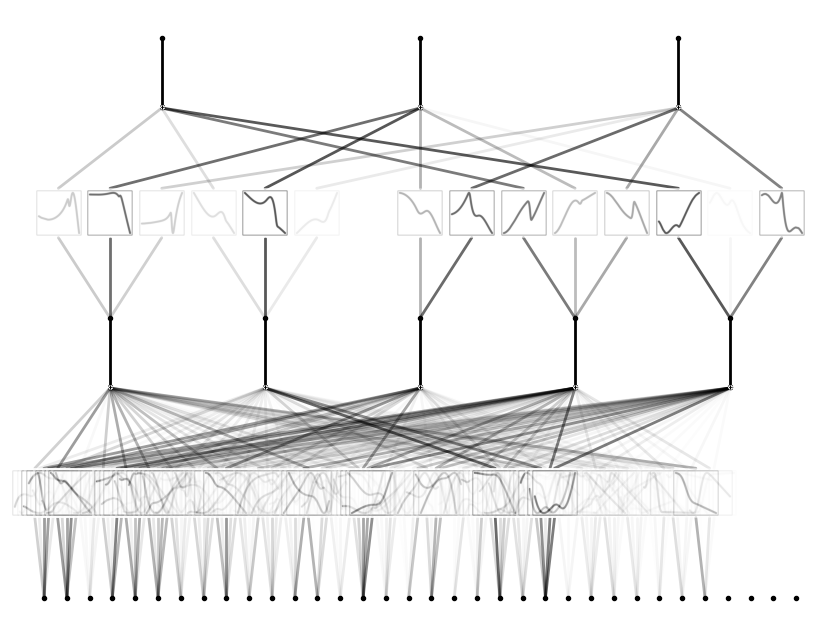

In [612]:
model.plot(beta=3, scale=1)

plt.savefig("KAN_structure.svg", bbox_inches="tight")

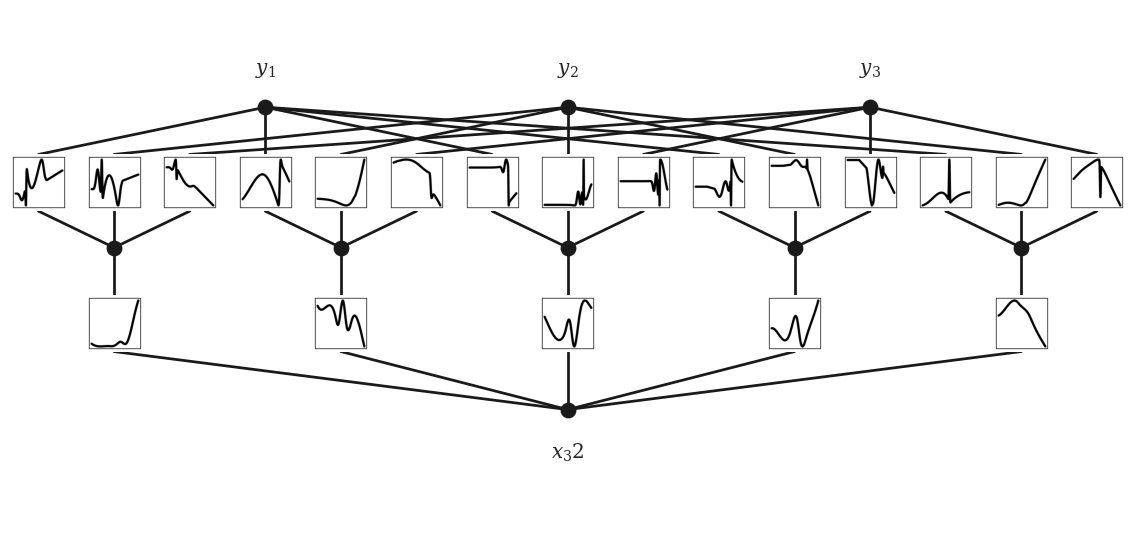

[Y] y_in=0.260, y_sp0=0.420, y_hidden=0.560, y_sp1=0.680, y_out=0.820
[layout] sp1_gap_eff=0.0000, sp1_total_use=1.050


In [606]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def redraw_single_io_path_parallel_1to3_interleaved(
    folder="./figures",
    i_in=2,                    # sp_0_{i_in}_{h}.png
    H=5,                       # hidden 个数
    J=3,                       # 输出维度（y1,y2,y3）
    in_label=r"$x_3$",
    out_labels=(r"$y_1$", r"$y_2$", r"$y_3$"),
    scale=1.0,
    fig_w=12.0,
    fig_h=6.0,

    # =========================
    # 统一尺寸/粗细
    # =========================
    img_w=0.070,               # 所有小图宽（统一）
    img_h=0.105,               # 所有小图高（统一）
    dot_size=120,              # 所有节点黑点大小（统一）
    lw=2.2,                    # 线宽

    # =========================
    # 横向紧凑度（主要调这里）
    # =========================
    sp1_total_ratio=0.41,      # 15 张整体占宽比例（0~1）
    sp1_gap=-0.8,             # 15 张小图间距（越小越紧凑）
    sp0_total_ratio=0.50,      # 5 张 sp0 整体占宽比例
    sp0_gap=0.012,             # 5 张 sp0 间距

    # ==========================================================
    # ✅ 纵向布局（你现在要控制的核心参数）
    # 采用“自顶向下/自底向上”都容易乱，所以用“锚点 + 间距”统一算
    # ==========================================================
    y_sp1=0.68,                # sp1 行中心 y（15 张那一行）
    d_out=0.14,                # sp1 -> output 的距离（输出点在 sp1 上方）
    d_hidden=0.12,             # hidden -> sp1 的距离（hidden 在 sp1 下方）
    d_sp0=0.14,                # sp0 -> hidden 的距离（sp0 在 hidden 下方）
    d_in=0.16,                 # input -> sp0 的距离（input 在 sp0 下方）

    # =========================
    # 位置钉死规则（保持你之前的要求）
    # =========================
    hidden_anchor_j=1,                    # hidden(h) 对齐到 sp1(h, j=1) 正下方
    out_anchor_map=((1, 0), (2, 1), (3, 2)),  # y1/y2/y3 锚到 sp1(h,j) 上方

    font_in=16,
    font_out=16,
    savepath=None
):
    """
    文件：
      sp0: sp_0_{i_in}_{h}.png
      sp1: sp_1_{h}_{j}.png
    """

    # ---------- 生成一排中心 x 坐标（整体居中） ----------
    def make_centered_xs(n, total_ratio, w, gap_target):
        gap_max = (total_ratio - n * w) / max(n - 1, 1)
        gap_eff = min(gap_target, gap_max) if gap_max > 0 else 0.0

        total_min = n * w
        total_use = max(total_ratio, total_min)

        left = 0.5 - total_use / 2
        xs = np.array([left + w / 2 + k * (w + gap_eff) for k in range(n)])
        return xs, gap_eff, total_use

    # ---------- sp1(15) 的 x（一整排） ----------
    xs_sp1, sp1_gap_eff, sp1_total_use = make_centered_xs(H * J, sp1_total_ratio, img_w, sp1_gap)
    xs_sp1_by_h = [[xs_sp1[h * J + j] for j in range(J)] for h in range(H)]

    # ---------- hidden 的 x：锚到 sp1(h, j=hidden_anchor_j) 下方 ----------
    hidden_anchor_j = max(0, min(J - 1, int(hidden_anchor_j)))
    x_hidden = np.array([xs_sp1_by_h[h][hidden_anchor_j] for h in range(H)], dtype=float)

    # ---------- ✅ sp0(5) 的 x：强制放在 hidden 正下方（你现在的要求 1） ----------
    x_sp0 = x_hidden.copy()

    # ---------- 输出点 x：按 out_anchor_map 钉死 ----------
    x_outs = np.zeros(J, dtype=float)
    for j in range(J):
        h_a, j_a = out_anchor_map[j]
        h_a = max(0, min(H - 1, int(h_a)))
        j_a = max(0, min(J - 1, int(j_a)))
        x_outs[j] = xs_sp1_by_h[h_a][j_a]

    # ---------- ✅ 用你给的纵向距离参数计算各层 y ----------
    y_row1 = y_sp1
    y_out = y_row1 + d_out
    y_hidden = y_row1 - d_hidden
    y_row0 = y_hidden - d_sp0
    y_in = y_row0 - d_in

    # ---------- 画布 ----------
    fig = plt.figure(figsize=(fig_w * scale, fig_h * scale))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # ---------- 贴图函数 ----------
    def place_png(center_x, center_y, png_path, w=img_w, h=img_h):
        left = center_x - w / 2
        bottom = center_y - h / 2
        if os.path.exists(png_path):
            im = mpimg.imread(png_path)
            ax_img = fig.add_axes([left, bottom, w, h])
            ax_img.imshow(im)
            ax_img.axis("off")
            ax_img.patch.set_alpha(0.0)
        else:
            rect = plt.Rectangle((left, bottom), w, h, fill=False, lw=1.2, ec="r")
            ax.add_patch(rect)

    # ---------- 输入点 ----------
    x_in = 0.5
    ax.scatter([x_in], [y_in], s=dot_size * scale, c="k", zorder=10)
    ax.text(x_in, y_in - 0.06, in_label, ha="center", va="top",
            fontsize=font_in * scale)

    # ---------- 输出点 ----------
    for j in range(J):
        ax.scatter([x_outs[j]], [y_out], s=dot_size * scale, c="k", zorder=10)
        ax.text(x_outs[j], y_out + 0.05, out_labels[j],
                ha="center", va="bottom", fontsize=font_out * scale)

    # ---------- hidden 点 ----------
    ax.scatter(x_hidden, [y_hidden] * H, s=dot_size * scale, c="k", zorder=10)

    # =========================================================
    # 下层：输入 -> sp0(5)（✅ sp0 在 hidden 正下方）
    # =========================================================
    for h in range(H):
        p0 = os.path.join(folder, f"sp_0_{i_in}_{h}.png")
        place_png(x_sp0[h], y_row0, p0)

        # input -> sp0(h)
        ax.plot([x_in, x_sp0[h]],
                [y_in, y_row0 - img_h / 2],
                c="k", lw=lw * scale, zorder=2)

        # sp0(h) -> hidden(h)（竖直更美观：x 一致）
        ax.plot([x_sp0[h], x_hidden[h]],
                [y_row0 + img_h / 2, y_hidden],
                c="k", lw=lw * scale, zorder=2)

    # =========================================================
    # 上层：sp1(15 横排交错) + 连线
    # =========================================================
    for h in range(H):
        for j in range(J):
            x_sp = xs_sp1_by_h[h][j]
            p1 = os.path.join(folder, f"sp_1_{h}_{j}.png")
            place_png(x_sp, y_row1, p1)

            # hidden(h) -> sp1(h,j)
            ax.plot([x_hidden[h], x_sp],
                    [y_hidden, y_row1 - img_h / 2],
                    c="k", lw=lw * scale, zorder=2)

            # sp1(h,j) -> y_j
            ax.plot([x_sp, x_outs[j]],
                    [y_row1 + img_h / 2, y_out],
                    c="k", lw=lw * scale, zorder=2)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    # 打印布局，方便你调参
    print(f"[Y] y_in={y_in:.3f}, y_sp0={y_row0:.3f}, y_hidden={y_hidden:.3f}, y_sp1={y_row1:.3f}, y_out={y_out:.3f}")
    print(f"[layout] sp1_gap_eff={sp1_gap_eff:.4f}, sp1_total_use={sp1_total_use:.3f}")


# =========================
# 用法示例
# =========================
redraw_single_io_path_parallel_1to3_interleaved(
    folder="./figures",
    i_in=31,
    H=5,
    J=3,
    in_label=r"$x_32$",
    out_labels=(r"$y_1$", r"$y_2$", r"$y_3$"),
    scale=0.9,
    savepath="/home/scjy/gwf/pykan-master/x32_refined6.svg"
)




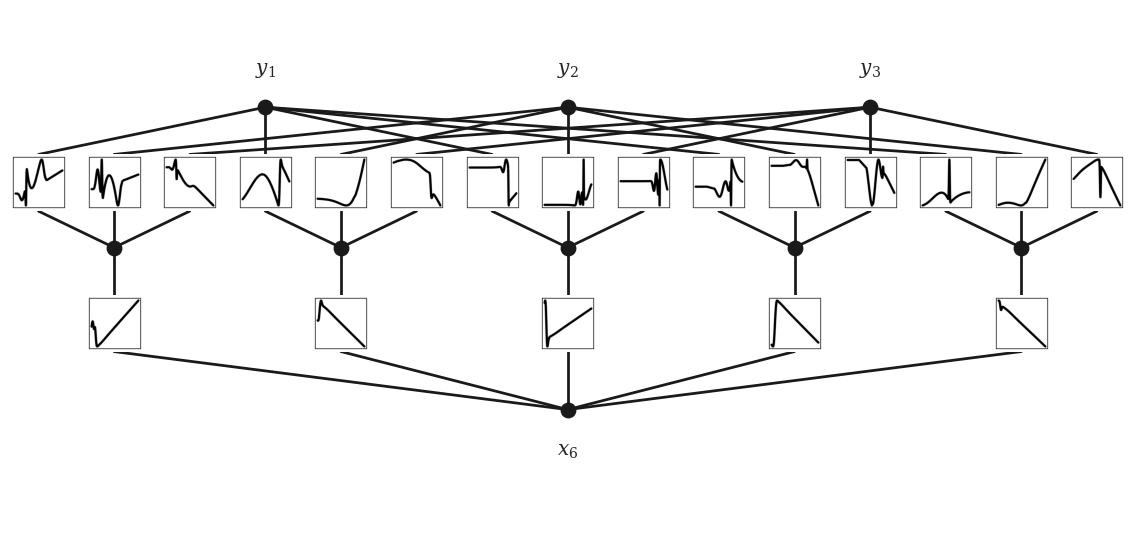

[Y] y_in=0.260, y_sp0=0.420, y_hidden=0.560, y_sp1=0.680, y_out=0.820
[layout] sp1_gap_eff=0.0000, sp1_total_use=1.050


In [607]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def redraw_single_io_path_parallel_1to3_interleaved(
    folder="./figures",
    i_in=2,                    # sp_0_{i_in}_{h}.png
    H=5,                       # hidden 个数
    J=3,                       # 输出维度（y1,y2,y3）
    in_label=r"$x_3$",
    out_labels=(r"$y_1$", r"$y_2$", r"$y_3$"),
    scale=1.0,
    fig_w=12.0,
    fig_h=6.0,

    # =========================
    # 统一尺寸/粗细
    # =========================
    img_w=0.070,               # 所有小图宽（统一）
    img_h=0.105,               # 所有小图高（统一）
    dot_size=120,              # 所有节点黑点大小（统一）
    lw=2.2,                    # 线宽

    # =========================
    # 横向紧凑度（主要调这里）
    # =========================
    sp1_total_ratio=0.41,      # 15 张整体占宽比例（0~1）
    sp1_gap=-0.8,             # 15 张小图间距（越小越紧凑）
    sp0_total_ratio=0.50,      # 5 张 sp0 整体占宽比例
    sp0_gap=0.012,             # 5 张 sp0 间距

    # ==========================================================
    # ✅ 纵向布局（你现在要控制的核心参数）
    # 采用“自顶向下/自底向上”都容易乱，所以用“锚点 + 间距”统一算
    # ==========================================================
    y_sp1=0.68,                # sp1 行中心 y（15 张那一行）
    d_out=0.14,                # sp1 -> output 的距离（输出点在 sp1 上方）
    d_hidden=0.12,             # hidden -> sp1 的距离（hidden 在 sp1 下方）
    d_sp0=0.14,                # sp0 -> hidden 的距离（sp0 在 hidden 下方）
    d_in=0.16,                 # input -> sp0 的距离（input 在 sp0 下方）

    # =========================
    # 位置钉死规则（保持你之前的要求）
    # =========================
    hidden_anchor_j=1,                    # hidden(h) 对齐到 sp1(h, j=1) 正下方
    out_anchor_map=((1, 0), (2, 1), (3, 2)),  # y1/y2/y3 锚到 sp1(h,j) 上方

    font_in=16,
    font_out=16,
    savepath=None
):
    """
    文件：
      sp0: sp_0_{i_in}_{h}.png
      sp1: sp_1_{h}_{j}.png
    """

    # ---------- 生成一排中心 x 坐标（整体居中） ----------
    def make_centered_xs(n, total_ratio, w, gap_target):
        gap_max = (total_ratio - n * w) / max(n - 1, 1)
        gap_eff = min(gap_target, gap_max) if gap_max > 0 else 0.0

        total_min = n * w
        total_use = max(total_ratio, total_min)

        left = 0.5 - total_use / 2
        xs = np.array([left + w / 2 + k * (w + gap_eff) for k in range(n)])
        return xs, gap_eff, total_use

    # ---------- sp1(15) 的 x（一整排） ----------
    xs_sp1, sp1_gap_eff, sp1_total_use = make_centered_xs(H * J, sp1_total_ratio, img_w, sp1_gap)
    xs_sp1_by_h = [[xs_sp1[h * J + j] for j in range(J)] for h in range(H)]

    # ---------- hidden 的 x：锚到 sp1(h, j=hidden_anchor_j) 下方 ----------
    hidden_anchor_j = max(0, min(J - 1, int(hidden_anchor_j)))
    x_hidden = np.array([xs_sp1_by_h[h][hidden_anchor_j] for h in range(H)], dtype=float)

    # ---------- ✅ sp0(5) 的 x：强制放在 hidden 正下方（你现在的要求 1） ----------
    x_sp0 = x_hidden.copy()

    # ---------- 输出点 x：按 out_anchor_map 钉死 ----------
    x_outs = np.zeros(J, dtype=float)
    for j in range(J):
        h_a, j_a = out_anchor_map[j]
        h_a = max(0, min(H - 1, int(h_a)))
        j_a = max(0, min(J - 1, int(j_a)))
        x_outs[j] = xs_sp1_by_h[h_a][j_a]

    # ---------- ✅ 用你给的纵向距离参数计算各层 y ----------
    y_row1 = y_sp1
    y_out = y_row1 + d_out
    y_hidden = y_row1 - d_hidden
    y_row0 = y_hidden - d_sp0
    y_in = y_row0 - d_in

    # ---------- 画布 ----------
    fig = plt.figure(figsize=(fig_w * scale, fig_h * scale))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # ---------- 贴图函数 ----------
    def place_png(center_x, center_y, png_path, w=img_w, h=img_h):
        left = center_x - w / 2
        bottom = center_y - h / 2
        if os.path.exists(png_path):
            im = mpimg.imread(png_path)
            ax_img = fig.add_axes([left, bottom, w, h])
            ax_img.imshow(im)
            ax_img.axis("off")
            ax_img.patch.set_alpha(0.0)
        else:
            rect = plt.Rectangle((left, bottom), w, h, fill=False, lw=1.2, ec="r")
            ax.add_patch(rect)

    # ---------- 输入点 ----------
    x_in = 0.5
    ax.scatter([x_in], [y_in], s=dot_size * scale, c="k", zorder=10)
    ax.text(x_in, y_in - 0.06, in_label, ha="center", va="top",
            fontsize=font_in * scale)

    # ---------- 输出点 ----------
    for j in range(J):
        ax.scatter([x_outs[j]], [y_out], s=dot_size * scale, c="k", zorder=10)
        ax.text(x_outs[j], y_out + 0.05, out_labels[j],
                ha="center", va="bottom", fontsize=font_out * scale)

    # ---------- hidden 点 ----------
    ax.scatter(x_hidden, [y_hidden] * H, s=dot_size * scale, c="k", zorder=10)

    # =========================================================
    # 下层：输入 -> sp0(5)（✅ sp0 在 hidden 正下方）
    # =========================================================
    for h in range(H):
        p0 = os.path.join(folder, f"sp_0_{i_in}_{h}.png")
        place_png(x_sp0[h], y_row0, p0)

        # input -> sp0(h)
        ax.plot([x_in, x_sp0[h]],
                [y_in, y_row0 - img_h / 2],
                c="k", lw=lw * scale, zorder=2)

        # sp0(h) -> hidden(h)（竖直更美观：x 一致）
        ax.plot([x_sp0[h], x_hidden[h]],
                [y_row0 + img_h / 2, y_hidden],
                c="k", lw=lw * scale, zorder=2)

    # =========================================================
    # 上层：sp1(15 横排交错) + 连线
    # =========================================================
    for h in range(H):
        for j in range(J):
            x_sp = xs_sp1_by_h[h][j]
            p1 = os.path.join(folder, f"sp_1_{h}_{j}.png")
            place_png(x_sp, y_row1, p1)

            # hidden(h) -> sp1(h,j)
            ax.plot([x_hidden[h], x_sp],
                    [y_hidden, y_row1 - img_h / 2],
                    c="k", lw=lw * scale, zorder=2)

            # sp1(h,j) -> y_j
            ax.plot([x_sp, x_outs[j]],
                    [y_row1 + img_h / 2, y_out],
                    c="k", lw=lw * scale, zorder=2)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    # 打印布局，方便你调参
    print(f"[Y] y_in={y_in:.3f}, y_sp0={y_row0:.3f}, y_hidden={y_hidden:.3f}, y_sp1={y_row1:.3f}, y_out={y_out:.3f}")
    print(f"[layout] sp1_gap_eff={sp1_gap_eff:.4f}, sp1_total_use={sp1_total_use:.3f}")


# =========================
# 用法示例
# =========================
redraw_single_io_path_parallel_1to3_interleaved(
    folder="./figures",
    i_in=5,
    H=5,
    J=3,
    in_label=r"$x_6$",
    out_labels=(r"$y_1$", r"$y_2$", r"$y_3$"),
    scale=0.9,
    savepath="/home/scjy/gwf/pykan-master/x6_refined6.svg"
)


In [539]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

RuntimeError: The size of tensor a (3) must match the size of tensor b (2029) at non-singleton dimension 1

In [476]:
# ================================
# Inference time (ms) per sample on test set: mean & variance (no std(df<=0) warning)
# Measure by batching (recommended for pykan)
# ================================
import torch

model.eval()
x_test = dataset["test_input"]
N = x_test.shape[0]

batch_size = 64     # 建议 32/64/128，太小会触发 std(df<=0) warning
warmup = 10         # 预热 batch 次数
use_gpu = (x_test.is_cuda and torch.cuda.is_available())

times_ms_per_sample = []

with torch.no_grad():
    # -------- warm-up --------
    if use_gpu:
        for _ in range(warmup):
            xb = x_test[:batch_size]
            _ = model(xb)
        torch.cuda.synchronize()
    else:
        for _ in range(warmup):
            xb = x_test[:batch_size]
            _ = model(xb)

    # -------- timing over batches --------
    if use_gpu:
        starter = torch.cuda.Event(enable_timing=True)
        ender   = torch.cuda.Event(enable_timing=True)

        for s in range(0, N, batch_size):
            xb = x_test[s:s+batch_size]
            b = xb.shape[0]
            if b < 2:
                # 极端情况下最后一个 batch 可能只有 1 个样本 -> 会触发 warning
                # 处理方式：与前一个样本拼成 2 个样本来测时，再按 b=1 取 per-sample
                xb = x_test[max(0, N-2):N]   # 取最后2个
                b = xb.shape[0]

            torch.cuda.synchronize()
            starter.record()
            _ = model(xb)
            ender.record()
            torch.cuda.synchronize()

            t_batch_ms = starter.elapsed_time(ender)  # ms
            times_ms_per_sample.append(float(t_batch_ms / b))

    else:
        import time
        for s in range(0, N, batch_size):
            xb = x_test[s:s+batch_size]
            b = xb.shape[0]
            if b < 2:
                xb = x_test[max(0, N-2):N]
                b = xb.shape[0]

            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()

            t_batch_ms = (t1 - t0) * 1000.0
            times_ms_per_sample.append(float(t_batch_ms / b))

t = torch.tensor(times_ms_per_sample, dtype=torch.float64)

mean_ms = t.mean().item()
var_ms2 = t.var(unbiased=False).item()
std_ms  = t.std(unbiased=False).item()

print(f"[Inference time per sample on test set (batched)]")
print(f"  N={N}, batch_size={batch_size}, device={x_test.device}")
print(f"  Mean : {mean_ms:.4f} ms")
print(f"  Var  : {var_ms2:.6f} (ms^2)")
print(f"  Std  : {std_ms:.4f} ms")



[Inference time per sample on test set (batched)]
  N=2029, batch_size=64, device=cuda:0
  Mean : 0.2342 ms
  Var  : 0.000354 (ms^2)
  Std  : 0.0188 ms


In [462]:
# ================================
# MLP baseline (3-class) + Accuracy + Inference time (ms)
# - Runs on CUDA if available
# - You can customize hidden layers via `mlp_hidden`
# - Measures per-sample inference time on test set by batching (recommended)
# ================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

torch.set_default_dtype(torch.float64)

# ----------------
# 0) Device
# ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------
# 1) Read CSV
# ----------------
csv_path = "0-MY-DATASET-RR.csv"
df = pd.read_csv(csv_path)

print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())

# ----------------
# 2) Split features & labels
# ----------------
X = df.iloc[:, 0:34].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df.iloc[:, 34], errors="coerce")

# ----------------
# 3) Clean
# ----------------
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

# numpy
X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.int64)  # integer labels 1/2/3

# ----------------
# 4) Train/test split (stratified)
# ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test  samples:", X_test.shape[0])

# ----------------
# 5) Standardize (train stats only)
# ----------------
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# ----------------
# 6) Torch tensors
# ----------------
X_train_t = torch.tensor(X_train, device=device, dtype=torch.float64)
X_test_t  = torch.tensor(X_test,  device=device, dtype=torch.float64)

# CrossEntropy expects class indices 0..C-1
y_train_t = torch.tensor(y_train - 1, device=device, dtype=torch.long)  # 0/1/2
y_test_t  = torch.tensor(y_test  - 1, device=device, dtype=torch.long)  # 0/1/2

# ============================================================
# 7) Define MLP (customize here)
# ============================================================
mlp_hidden = [64]   # <<< 你在这里自定义结构，比如 [32] / [128,64,32] 等
dropout_p = 0.0         # 可设 0.1/0.2
activation = "relu"     # "relu" / "tanh" / "gelu"

def make_act(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unsupported activation: {name}")

class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: list, out_dim: int, dropout: float = 0.0, act: str = "relu"):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, int(h)))
            layers.append(make_act(act))
            if dropout and dropout > 0:
                layers.append(nn.Dropout(p=float(dropout)))
            prev = int(h)
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(in_dim=34, hidden=mlp_hidden, out_dim=3, dropout=dropout_p, act=activation).to(device).double()
print(model)

# ============================================================
# 8) Train
# ============================================================
criterion = nn.CrossEntropyLoss()

lr = 1e-3
weight_decay = 0.0
epochs = 200
batch_size_train = 256

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

def iter_minibatches(Xt, yt, bs, shuffle=True):
    n = Xt.shape[0]
    idx = torch.randperm(n, device=Xt.device) if shuffle else torch.arange(n, device=Xt.device)
    for s in range(0, n, bs):
        j = idx[s:s+bs]
        yield Xt[j], yt[j]

best_acc = -1.0
best_state = None

for ep in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in iter_minibatches(X_train_t, y_train_t, batch_size_train, shuffle=True):
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)            # (B,3)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.shape[0]

    # eval on test each epoch (simple baseline; you can change to val set if you want)
    model.eval()
    with torch.no_grad():
        logits_te = model(X_test_t)
        pred_te = torch.argmax(logits_te, dim=1)
        acc_te = (pred_te == y_test_t).double().mean().item()

    if acc_te > best_acc:
        best_acc = acc_te
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    if ep % 10 == 0 or ep == 1:
        avg_loss = total_loss / X_train_t.shape[0]
        print(f"Epoch {ep:4d} | train_loss={avg_loss:.6f} | test_acc={acc_te*100:.2f}% | best={best_acc*100:.2f}%")

# load best
if best_state is not None:
    model.load_state_dict(best_state)

# ============================================================
# 9) Final Accuracy (3-class)
# ============================================================
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    y_pred_012 = torch.argmax(logits, dim=1)  # 0/1/2
    accuracy = (y_pred_012 == y_test_t).double().mean().item()

print(f"\n[MLP] Test Classification Accuracy: {accuracy*100:.2f}%")

# ============================================================
# 10) Inference time on test set (ms): mean & variance
#     Measure by batching; report per-sample time distribution
# ============================================================
batch_size_time = 64   # 建议 32/64/128
warmup_batches = 10

x_test = X_test_t
N = x_test.shape[0]
use_gpu = (x_test.is_cuda and torch.cuda.is_available())

times_ms_per_sample = []

model.eval()
with torch.no_grad():
    # ---- warm-up ----
    if use_gpu:
        for _ in range(warmup_batches):
            xb = x_test[:batch_size_time]
            _ = model(xb)
        torch.cuda.synchronize()
    else:
        for _ in range(warmup_batches):
            xb = x_test[:batch_size_time]
            _ = model(xb)

    # ---- timing ----
    if use_gpu:
        starter = torch.cuda.Event(enable_timing=True)
        ender   = torch.cuda.Event(enable_timing=True)

        for s in range(0, N, batch_size_time):
            xb = x_test[s:s+batch_size_time]
            b = xb.shape[0]
            if b == 0:
                continue

            torch.cuda.synchronize()
            starter.record()
            _ = model(xb)
            ender.record()
            torch.cuda.synchronize()

            t_batch_ms = starter.elapsed_time(ender)  # ms
            times_ms_per_sample.append(float(t_batch_ms / b))

    else:
        import time
        for s in range(0, N, batch_size_time):
            xb = x_test[s:s+batch_size_time]
            b = xb.shape[0]
            if b == 0:
                continue

            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()

            t_batch_ms = (t1 - t0) * 1000.0
            times_ms_per_sample.append(float(t_batch_ms / b))

t = torch.tensor(times_ms_per_sample, dtype=torch.float64)

mean_ms = t.mean().item()
var_ms2 = t.var(unbiased=False).item()  # population variance
std_ms  = t.std(unbiased=False).item()

print(f"\n[MLP] Inference time per sample on test set (batched)")
print(f"  N={N}, batch_size={batch_size_time}, device={x_test.device}")
print(f"  Mean : {mean_ms:.4f} ms")
print(f"  Var  : {var_ms2:.6f} (ms^2)")
print(f"  Std  : {std_ms:.4f} ms")



Device: cuda
Raw data shape: (10185, 35)
Columns: ['ECG_Max', 'ECG_SD', 'alpha_psd', 'ECG_Mean', 'ECG_Q1', 'delta_amp', 'ECG_Q2', 'ECG_Q3', 'beta_amp', 'ECG_AVHR', 'ECG_IBI', 'theta_psd', 'ECG_RMSSD', 'time_std', 'theta_amp', 'ECG_pNN20', 'ECG_pNN50', 'beta_psd', 'EDA_SC', 'EDA_SCL', 'alpha_amp', 'EDA_SCR', 'EDA_Max', 'EDA_SD', 'delta_psd', 'EDA_Mean', 'EDA_Q1', 'EDA_Q2', 'EDA_Q3', 'time_mean', 'time_max', 'time_min', 'time_skew', 'time_kurtosis', 'trust level']
Cleaned samples: 10143
Train samples: 8114
Test  samples: 2029
MLP(
  (net): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)
Epoch    1 | train_loss=1.011789 | test_acc=53.92% | best=53.92%
Epoch   10 | train_loss=0.638021 | test_acc=71.41% | best=71.41%
Epoch   20 | train_loss=0.536508 | test_acc=75.95% | best=75.95%
Epoch   30 | train_loss=0.485156 | test_acc=78.41% | best=78.56%
Epoch   40 | train_loss=0.450642 | test_acc

In [469]:
# ============================================
# Transformer baseline for tabular features (34 -> 3 classes)
# - Customizable architecture
# - Trainable params
# - CUDA inference time mean/var (ms per sample)
# ============================================

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

torch.set_default_dtype(torch.float64)

# -----------------------
# 0) Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# 1) Load & preprocess (same as your pipeline)
# -----------------------
csv_path = "0-MY-DATASET-RR.csv"
df = pd.read_csv(csv_path)

X = df.iloc[:, 0:34].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df.iloc[:, 34], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.int64)  # for CE loss: int64

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

# standardize (train stats only)
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# convert to torch
X_train_t = torch.tensor(X_train, device=device)
X_test_t  = torch.tensor(X_test, device=device)

# labels: map {1,2,3} -> {0,1,2}
y_train_t = torch.tensor(y_train - 1, device=device)
y_test_t  = torch.tensor(y_test  - 1, device=device)

print("Train:", X_train_t.shape, y_train_t.shape)
print("Test :", X_test_t.shape, y_test_t.shape)

# -----------------------
# 2) Transformer model (customizable)
# -----------------------
class TabTransformer(nn.Module):
    """
    Treat each scalar feature as a token.
    Input: (B, 34) -> tokens (B, 34, 1) -> embed -> transformer encoder -> pool -> classifier
    """
    def __init__(
        self,
        num_features: int = 34,
        num_classes: int = 3,
        d_model: int = 64,
        nhead: int = 8,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        pooling: str = "mean",   # "mean" or "cls"
    ):
        super().__init__()
        assert pooling in ["mean", "cls"]
        self.num_features = num_features
        self.num_classes = num_classes
        self.d_model = d_model
        self.pooling = pooling

        # each feature is a token with 1 dim -> project to d_model
        self.token_embed = nn.Linear(1, d_model)

        # optional learnable [CLS] token if using cls pooling
        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        # positional embedding (length = num_features (+1 if cls))
        seq_len = num_features + (1 if pooling == "cls" else 0)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   # (B, S, E)
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        # init (simple, stable)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 34)
        B, F = x.shape
        assert F == self.num_features

        tokens = x.unsqueeze(-1)              # (B, 34, 1)
        h = self.token_embed(tokens)          # (B, 34, d_model)

        if self.pooling == "cls":
            cls = self.cls_token.expand(B, -1, -1)     # (B, 1, d_model)
            h = torch.cat([cls, h], dim=1)             # (B, 35, d_model)

        h = h + self.pos_embed[:, :h.size(1), :]       # add position
        h = self.encoder(h)                            # (B, S, d_model)

        if self.pooling == "cls":
            pooled = h[:, 0, :]                        # CLS
        else:
            pooled = h.mean(dim=1)                     # mean pool

        pooled = self.norm(pooled)
        logits = self.head(pooled)                     # (B, 3)
        return logits


def count_trainable_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


# -----------------------
# 3) Customize architecture here
# -----------------------
cfg = dict(
    d_model=64,
    nhead=8,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    pooling="mean",  # "mean" or "cls"
)

model = TabTransformer(num_features=34, num_classes=3, **cfg).to(device)
print(model)
print("Trainable Parameters:", count_trainable_params(model))

# -----------------------
# 4) Train (simple baseline)
# -----------------------
# Dataloaders
batch_size = 256
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

epochs = 30

for ep in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.detach().cpu())

    # eval accuracy each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            correct += int((pred == yb).sum().item())
            total += int(yb.numel())
    acc = correct / max(1, total)

    if ep == 1 or ep % 5 == 0 or ep == epochs:
        print(f"Epoch {ep:02d}/{epochs} | train_loss={total_loss/len(train_loader):.6f} | test_acc={acc*100:.2f}%")

# final accuracy
print(f"\n[Transformer] Test Classification Accuracy: {acc*100:.2f}%")

# -----------------------
# 5) Inference time on test set (ms per sample): mean & var
#    Provide both:
#    (A) per-sample timing (loop)  -> closer to "single sample"
#    (B) batched timing (DataLoader) -> closer to real throughput
# -----------------------
def inference_time_per_sample(model, X, repeats=1):
    """
    Measures per-sample inference time by looping samples (slow but closest to single-sample).
    returns: times_ms (N,)
    """
    model.eval()
    N = X.shape[0]
    times = np.zeros(N, dtype=np.float64)

    # warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(X[:32])

    for i in range(N):
        xi = X[i:i+1]
        # CUDA timing needs sync
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(repeats):
                _ = model(xi)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times[i] = (t1 - t0) * 1000.0 / repeats
    return times

def inference_time_batched(model, loader, repeats=20):
    """
    Measures per-sample time using batched inference.
    returns: times_ms_per_sample (num_batches,)
    """
    model.eval()
    batch_times = []

    # warmup
    with torch.no_grad():
        for _ in range(10):
            xb, _ = next(iter(loader))
            _ = model(xb)

    with torch.no_grad():
        for xb, _ in loader:
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(repeats):
                _ = model(xb)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            # per-sample time for this batch
            ms_per_sample = (t1 - t0) * 1000.0 / (repeats * xb.shape[0])
            batch_times.append(ms_per_sample)

    return np.array(batch_times, dtype=np.float64)

# (A) single-sample style
times_ms = inference_time_per_sample(model, X_test_t, repeats=1)
mean_ms = float(times_ms.mean())
var_ms2 = float(((times_ms - mean_ms) ** 2).mean())  # population variance
std_ms = float(np.sqrt(var_ms2))

print("\n[Transformer] Inference time per sample on test set (single-sample loop)")
print(f"  N = {len(times_ms)}, repeats = 1, device = {device}")
print(f"  Mean : {mean_ms:.4f} ms")
print(f"  Var  : {var_ms2:.6f} (ms^2)")
print(f"  Std  : {std_ms:.4f} ms")

# (B) batched throughput style
batch_times_ms = inference_time_batched(model, test_loader, repeats=50)
mean_b = float(batch_times_ms.mean())
var_b = float(((batch_times_ms - mean_b) ** 2).mean())
std_b = float(np.sqrt(var_b))

print("\n[Transformer] Inference time per sample on test set (batched)")
print(f"  N_batches = {len(batch_times_ms)}, batch_size = {batch_size}, device = {device}")
print(f"  Mean : {mean_b:.4f} ms")
print(f"  Var  : {var_b:.6f} (ms^2)")
print(f"  Std  : {std_b:.4f} ms")


Device: cuda
Cleaned samples: 10143
Train: torch.Size([8114, 34]) torch.Size([8114])
Test : torch.Size([2029, 34]) torch.Size([2029])
TabTransformer(
  (token_embed): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_f

/tmp/ipykernel_708843/2951783189.py:121: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 01/30 | train_loss=1.073553 | test_acc=45.39%
Epoch 05/30 | train_loss=0.813882 | test_acc=61.51%
Epoch 10/30 | train_loss=0.564378 | test_acc=74.37%
Epoch 15/30 | train_loss=0.423896 | test_acc=81.67%
Epoch 20/30 | train_loss=0.333138 | test_acc=85.90%
Epoch 25/30 | train_loss=0.252989 | test_acc=86.89%
Epoch 30/30 | train_loss=0.228067 | test_acc=88.57%

[Transformer] Test Classification Accuracy: 88.57%

[Transformer] Inference time per sample on test set (single-sample loop)
  N = 2029, repeats = 1, device = cuda
  Mean : 0.4230 ms
  Var  : 0.004133 (ms^2)
  Std  : 0.0643 ms

[Transformer] Inference time per sample on test set (batched)
  N_batches = 8, batch_size = 256, device = cuda
  Mean : 0.0120 ms
  Var  : 0.000000 (ms^2)
  Std  : 0.0000 ms


In [471]:
# ============================================================
# TabNet baseline (3-class) with:
# - Customizable architecture
# - Trainable parameter count
# - CUDA training + inference timing (mean/var in ms per sample)
# ============================================================

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

torch.set_default_dtype(torch.float32)  # TabNet 常用 float32；如需 float64 可改，但通常没必要

# ----------------------------
# 0) Try import TabNet
# ----------------------------
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "No module named 'pytorch_tabnet'. Please install it first:\n"
        "  pip install pytorch-tabnet\n"
        "If you use conda:\n"
        "  pip install pytorch-tabnet\n"
    )

# ----------------------------
# 1) Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("CUDA available. GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# 2) Load CSV + preprocess (same logic as your KAN pipeline)
# ----------------------------
csv_path = "0-MY-DATASET-RR.csv"  # ensure this path is correct
df = pd.read_csv(csv_path)

# X: first 34 cols, y: col 35 (1/2/3)
X = df.iloc[:, 0:34].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df.iloc[:, 34], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

X = X.to_numpy(dtype=np.float32)
y = y.to_numpy(dtype=np.int64)

print("Cleaned samples:", len(y))

# IMPORTANT: TabNetClassifier expects class labels starting at 0..C-1
# Your labels are 1/2/3 -> convert to 0/1/2
y0 = y - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y0,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y0
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# Standardize with train stats (same anti-leakage rule)
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# ----------------------------
# 3) TabNet hyperparams (YOU CAN CUSTOMIZE HERE)
# ----------------------------
tabnet_cfg = dict(
    n_d=32,                 # decision layer width
    n_a=32,                 # attention layer width
    n_steps=5,              # number of decision steps
    gamma=1.5,              # relaxation parameter
    n_independent=2,        # independent GLU layers per step
    n_shared=2,             # shared GLU layers
    lambda_sparse=1e-4,     # sparsity regularization
    momentum=0.02,
    mask_type="sparsemax",  # "sparsemax" or "entmax"
)

train_cfg = dict(
    max_epochs=200,
    patience=30,
    batch_size=1024,        # you can tune
    virtual_batch_size=256, # ghost batch size
    num_workers=0,
    drop_last=False,
)

# ----------------------------
# 4) Build + train TabNet (on CUDA if available)
# ----------------------------
clf = TabNetClassifier(
    **tabnet_cfg,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 50, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10,
    device_name=device,     # "cuda" or "cpu"
)

clf.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    **train_cfg
)

# ----------------------------
# 5) Accuracy on test set
# ----------------------------
y_pred = clf.predict(X_test)  # returns 0/1/2
acc = accuracy_score(y_test, y_pred)
print(f"\n[TabNet] Test Accuracy: {acc*100:.2f}%")

# ----------------------------
# 6) Trainable Parameters
# ----------------------------
# TabNetClassifier stores torch model at clf.network (a torch.nn.Module)
net = clf.network
n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"[TabNet] Trainable Parameters: {n_params:,}")

# ----------------------------
# 7) Inference timing on GPU (ms per sample): mean / var
#    Use the torch module directly for precise timing.
# ----------------------------
net.eval()

# Prepare torch tensor on same device
x_te = torch.from_numpy(X_test).to(device=device, dtype=torch.float32)

# Warm-up (important for CUDA timing)
with torch.no_grad():
    for _ in range(10):
        _ = net(x_te[:min(512, x_te.shape[0])])

def measure_infer_time_batched(model, x, batch_size=256, repeats=30):
    """
    Returns:
      times_ms_per_sample: (repeats,) each is averaged ms/sample over whole test set (batched)
      mean_ms, var_ms2
    """
    assert x.is_cuda == (device == "cuda"), "x and device mismatch"

    N = x.shape[0]
    times = []

    if device == "cuda":
        starter = torch.cuda.Event(enable_timing=True)
        ender   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(repeats):
            if device == "cuda":
                torch.cuda.synchronize()
                starter.record()

            # batched forward over entire test set
            for s in range(0, N, batch_size):
                xb = x[s:s+batch_size]
                _ = model(xb)  # forward

            if device == "cuda":
                ender.record()
                torch.cuda.synchronize()
                elapsed_ms = starter.elapsed_time(ender)  # total ms for whole test set
            else:
                # CPU timing fallback
                import time
                t0 = time.perf_counter()
                for s in range(0, N, batch_size):
                    xb = x[s:s+batch_size]
                    _ = model(xb)
                elapsed_ms = (time.perf_counter() - t0) * 1000.0

            times.append(elapsed_ms / N)  # ms per sample

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())
    var_ms2 = float(((times - mean_ms) ** 2).mean())  # population variance
    return times, mean_ms, var_ms2

times_ms, mean_ms, var_ms2 = measure_infer_time_batched(
    net, x_te, batch_size=256, repeats=30
)
std_ms = float(np.sqrt(var_ms2))

print(f"\n[TabNet] Inference time per sample on test set (batched)")
print(f"  N = {x_te.shape[0]}, repeats = {len(times_ms)}, device = {device}")
print(f"  Mean: {mean_ms:.4f} ms")
print(f"  Var : {var_ms2:.6f} (ms^2)")
print(f"  Std : {std_ms:.4f} ms")


Device: cuda
CUDA available. GPU: NVIDIA GeForce RTX 5090
Cleaned samples: 10143
Train samples: 8114
Test samples : 2029


/home/scjy/.conda/envs/pykan-5090/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.38418 | test_accuracy: 0.43223 |  0:00:00s
epoch 10 | loss: 0.69167 | test_accuracy: 0.67521 |  0:00:01s
epoch 20 | loss: 0.67    | test_accuracy: 0.70034 |  0:00:04s
epoch 30 | loss: 0.59295 | test_accuracy: 0.724   |  0:00:07s
epoch 40 | loss: 0.60948 | test_accuracy: 0.71316 |  0:00:09s
epoch 50 | loss: 0.60728 | test_accuracy: 0.71759 |  0:00:11s
epoch 60 | loss: 0.53354 | test_accuracy: 0.76639 |  0:00:13s
epoch 70 | loss: 0.5017  | test_accuracy: 0.76737 |  0:00:15s
epoch 80 | loss: 0.46844 | test_accuracy: 0.78117 |  0:00:17s
epoch 90 | loss: 0.47653 | test_accuracy: 0.78561 |  0:00:19s
epoch 100| loss: 0.55014 | test_accuracy: 0.73977 |  0:00:21s
epoch 110| loss: 0.47174 | test_accuracy: 0.78314 |  0:00:22s

Early stopping occurred at epoch 112 with best_epoch = 82 and best_test_accuracy = 0.80483

[TabNet] Test Accuracy: 80.48%
[TabNet] Trainable Parameters: 123,004


/home/scjy/.conda/envs/pykan-5090/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



[TabNet] Inference time per sample on test set (batched)
  N = 2029, repeats = 30, device = cuda
  Mean: 0.0156 ms
  Var : 0.000000 (ms^2)
  Std : 0.0003 ms


In [472]:
# =========================
# NAM baseline (PyTorch)
# - Per-feature subnetwork f_i(x_i)
# - Sum over features -> logits for 3 classes
# - CUDA training/inference + params + timing
# =========================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# -----------------------
# 0) Repro + dtype/device
# -----------------------
torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available(), "| device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -----------------------
# 1) Load + split + standardize (same as your pipeline)
# -----------------------
csv_path = "0-MY-DATASET-RR.csv"  # keep same path

df = pd.read_csv(csv_path)
print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())

X = df.iloc[:, 0:34].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df.iloc[:, 34], errors="coerce")

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.int64)  # integer labels {1,2,3}

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# standardize by train stats
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True) + 1e-12
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

X_train_t = torch.tensor(X_train, device=device)
X_test_t  = torch.tensor(X_test, device=device)

# convert labels to 0/1/2 for CrossEntropyLoss
y_train_t = torch.tensor(y_train - 1, device=device)  # (N,)
y_test_t  = torch.tensor(y_test - 1, device=device)   # (N,)

# -----------------------
# 2) NAM model definition
# -----------------------
class FeatureMLP(nn.Module):
    """A tiny MLP for a single feature scalar x_i -> hidden -> out_dim logits contribution."""
    def __init__(self, hidden, out_dim=3, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = 1
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_1d):
        # x_1d: (B,) -> (B,1)
        return self.net(x_1d.unsqueeze(1))


class NAMClassifier(nn.Module):
    """
    NAM: logits = bias + sum_i f_i(x_i)
    where each f_i is a small MLP taking scalar input.
    """
    def __init__(self, n_features=34, num_classes=3, nam_hidden=(16, 16),
                 dropout=0.0, use_feature_dropout=False, feature_dropout_p=0.0):
        super().__init__()
        self.n_features = n_features
        self.num_classes = num_classes
        self.use_feature_dropout = use_feature_dropout
        self.feature_dropout_p = float(feature_dropout_p)

        self.feature_nets = nn.ModuleList([
            FeatureMLP(hidden=list(nam_hidden), out_dim=num_classes, dropout=dropout)
            for _ in range(n_features)
        ])
        self.bias = nn.Parameter(torch.zeros(num_classes, dtype=torch.get_default_dtype()))

    def forward(self, x):
        # x: (B, n_features)
        B, D = x.shape
        assert D == self.n_features

        # Optional: feature dropout (drops entire feature contributions)
        if self.training and self.use_feature_dropout and self.feature_dropout_p > 0:
            mask = (torch.rand(D, device=x.device) > self.feature_dropout_p).to(x.dtype)  # (D,)
        else:
            mask = torch.ones(D, device=x.device, dtype=x.dtype)

        logits = self.bias.unsqueeze(0).expand(B, -1)  # (B, C)
        for i in range(D):
            contrib = self.feature_nets[i](x[:, i])     # (B, C)
            logits = logits + contrib * mask[i]
        return logits


# -----------------------
# 3) Customizable config (you can change these)
# -----------------------
nam_hidden = [32]   # <-- you can customize: per-feature MLP hidden layers
dropout = 0.0
use_feature_dropout = False
feature_dropout_p = 0.0

lr = 1e-3
weight_decay = 1e-5
epochs = 50
batch_size = 256

model = NAMClassifier(
    n_features=34,
    num_classes=3,
    nam_hidden=nam_hidden,
    dropout=dropout,
    use_feature_dropout=use_feature_dropout,
    feature_dropout_p=feature_dropout_p
).to(device)

# -----------------------
# 4) Trainable parameters
# -----------------------
def count_trainable_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"[NAM] nam_hidden={nam_hidden}")
print(f"[NAM] Trainable Parameters: {count_trainable_params(model):,}")

# -----------------------
# 5) Training loop
# -----------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def accuracy_on_tensor(m, X, y):
    m.eval()
    with torch.no_grad():
        logits = m(X)
        pred = torch.argmax(logits, dim=1)
        acc = (pred == y).double().mean().item()
    return acc

# simple minibatch iterator
def iter_batches(X, y, bs):
    N = X.shape[0]
    idx = torch.randperm(N, device=X.device)
    for s in range(0, N, bs):
        j = idx[s:s+bs]
        yield X[j], y[j]

print("\n==== Training NAM (CUDA if available) ====")
for ep in range(1, epochs + 1):
    model.train()
    losses = []
    for xb, yb in iter_batches(X_train_t, y_train_t, batch_size):
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.detach())

    if ep == 1 or ep % 10 == 0 or ep == epochs:
        tr_acc = accuracy_on_tensor(model, X_train_t, y_train_t)
        te_acc = accuracy_on_tensor(model, X_test_t, y_test_t)
        mean_loss = torch.stack(losses).mean().item() if len(losses) else float("nan")
        print(f"Epoch {ep:3d}/{epochs} | loss={mean_loss:.6f} | train_acc={tr_acc*100:.2f}% | test_acc={te_acc*100:.2f}%")

# final accuracy
test_acc = accuracy_on_tensor(model, X_test_t, y_test_t)
print(f"\n[NAM] Test Accuracy: {test_acc*100:.2f}%")

# -----------------------
# 6) Inference timing (ms) on test set
#    Provide BOTH:
#    (A) single-sample loop (worst-case per-sample latency)
#    (B) batched timing (throughput-style per-sample time)
# -----------------------
def time_inference_single_sample(model, X, repeats=1):
    model.eval()
    N = X.shape[0]
    times_ms = []

    # warmup (GPU)
    with torch.no_grad():
        _ = model(X[:min(256, N)])
    if X.is_cuda:
        torch.cuda.synchronize()

    with torch.no_grad():
        for i in range(N):
            xi = X[i:i+1]
            if X.is_cuda:
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(repeats):
                _ = model(xi)
            if X.is_cuda:
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times_ms.append((t1 - t0) * 1000.0 / repeats)

    times_ms = np.array(times_ms, dtype=np.float64)
    mean_ms = float(times_ms.mean())
    var_ms2 = float(((times_ms - mean_ms) ** 2).mean())  # population variance
    std_ms = float(np.sqrt(var_ms2))
    return mean_ms, var_ms2, std_ms, times_ms

def time_inference_batched(model, X, batch_size=256, repeats=50):
    """
    Measure per-sample time by timing batches.
    repeats controls repeated forward calls per batch to reduce timer noise.
    """
    model.eval()
    N = X.shape[0]
    nb = int(np.ceil(N / batch_size))
    per_sample_ms = []

    # warmup
    with torch.no_grad():
        _ = model(X[:min(batch_size, N)])
    if X.is_cuda:
        torch.cuda.synchronize()

    with torch.no_grad():
        for b in range(nb):
            xb = X[b*batch_size : min((b+1)*batch_size, N)]
            if xb.numel() == 0:
                continue
            if X.is_cuda:
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(repeats):
                _ = model(xb)
            if X.is_cuda:
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            total_ms = (t1 - t0) * 1000.0
            ms_per_sample = total_ms / repeats / xb.shape[0]
            per_sample_ms.append(ms_per_sample)

    per_sample_ms = np.array(per_sample_ms, dtype=np.float64)
    mean_ms = float(per_sample_ms.mean())
    var_ms2 = float(((per_sample_ms - mean_ms) ** 2).mean())
    std_ms = float(np.sqrt(var_ms2))
    return mean_ms, var_ms2, std_ms, per_sample_ms

# (A) single-sample loop
mean_ms, var_ms2, std_ms, _ = time_inference_single_sample(model, X_test_t, repeats=1)
print("\n[NAM] Inference time per sample on test set (single-sample loop)")
print(f"  N = {int(X_test_t.shape[0])}, repeats = 1, device = {device}")
print(f"  Mean : {mean_ms:.4f} ms")
print(f"  Var  : {var_ms2:.6f} (ms^2)")
print(f"  Std  : {std_ms:.4f} ms")

# (B) batched
batch_size_time = 256
mean_ms_b, var_ms2_b, std_ms_b, _ = time_inference_batched(model, X_test_t, batch_size=batch_size_time, repeats=50)
print("\n[NAM] Inference time per sample on test set (batched)")
print(f"  N_batches = {int(np.ceil(X_test_t.shape[0]/batch_size_time))}, batch_size = {batch_size_time}, device = {device}")
print(f"  Mean : {mean_ms_b:.4f} ms")
print(f"  Var  : {var_ms2_b:.6f} (ms^2)")
print(f"  Std  : {std_ms_b:.4f} ms")


CUDA available: True | device: cuda
GPU: NVIDIA GeForce RTX 5090
Raw data shape: (10185, 35)
Columns: ['ECG_Max', 'ECG_SD', 'alpha_psd', 'ECG_Mean', 'ECG_Q1', 'delta_amp', 'ECG_Q2', 'ECG_Q3', 'beta_amp', 'ECG_AVHR', 'ECG_IBI', 'theta_psd', 'ECG_RMSSD', 'time_std', 'theta_amp', 'ECG_pNN20', 'ECG_pNN50', 'beta_psd', 'EDA_SC', 'EDA_SCL', 'alpha_amp', 'EDA_SCR', 'EDA_Max', 'EDA_SD', 'delta_psd', 'EDA_Mean', 'EDA_Q1', 'EDA_Q2', 'EDA_Q3', 'time_mean', 'time_max', 'time_min', 'time_skew', 'time_kurtosis', 'trust level']
Cleaned samples: 10143
Train samples: 8114
Test samples : 2029
[NAM] nam_hidden=[32]
[NAM] Trainable Parameters: 5,545

==== Training NAM (CUDA if available) ====
Epoch   1/50 | loss=1.038457 | train_acc=58.57% | test_acc=58.30%
Epoch  10/50 | loss=0.670364 | train_acc=71.27% | test_acc=71.51%
Epoch  20/50 | loss=0.615156 | train_acc=73.95% | test_acc=73.09%
Epoch  30/50 | loss=0.588522 | train_acc=74.45% | test_acc=73.34%
Epoch  40/50 | loss=0.572929 | train_acc=75.04% | test

In [417]:
import numpy as np
import torch
import copy
import scipy.io as sio

# ================================
# helper: compute 3-class accuracy (same rule as you used)
# ================================
def compute_acc_3class(model, test_input, test_label):
    model.eval()
    with torch.no_grad():
        y_pred_cont = model(test_input)              # (N,1)
        y_pred_cls  = torch.round(y_pred_cont)
        y_pred_cls  = torch.clamp(y_pred_cls, 1, 3)  # (N,1)
        acc = (y_pred_cls == test_label).double().mean().item()
    return acc  # in [0,1]


# ================================
# settings (match your training)
# ================================
opt = "LBFGS"
lamb = 0.001

cpu_steps = 5
gpu_steps = 100
total_steps = cpu_steps + gpu_steps  # 55

# ================================
# 0) initial accuracy (step=0)
# ================================
acc_list = []
step_list = []
phase_list = []  # 0=init, 1=CPU, 2=GPU

# initial acc on GPU test set (or CPU if you want, but keep consistent with later GPU phase)
acc0 = compute_acc_3class(model, dataset["test_input"], dataset["test_label"])
acc_list.append(acc0)
step_list.append(0)
phase_list.append(0)

print(f"[step 0 | init] acc = {acc0*100:.2f}%")

# ================================
# 1) CPU phase: run 5 steps with update_grid=True, record after each step
#    We train on CPU using dataset_cpu and evaluate on dataset_cpu test split.
# ================================
model_cpu = copy.deepcopy(model).to("cpu").double()

for s in range(1, cpu_steps + 1):
    # 1 step CPU grid update
    model_cpu.fit(
        dataset_cpu,
        opt=opt,
        steps=1,
        lamb=lamb,
        update_grid=True,
        grid_update_num=1,
        start_grid_update_step=0,
        stop_grid_update_step=1,
    )

    acc = compute_acc_3class(model_cpu, dataset_cpu["test_input"], dataset_cpu["test_label"])
    acc_list.append(acc)
    step_list.append(s)
    phase_list.append(1)

    print(f"[step {s} | CPU] acc = {acc*100:.2f}%")

# move back to your original device for GPU phase
model = model_cpu.to(model.device)

# ================================
# 2) GPU phase: run 50 steps with update_grid=False, record after each step
# ================================
for t in range(1, gpu_steps + 1):
    global_step = cpu_steps + t  # 6..55

    model.fit(
        dataset,
        opt=opt,
        steps=1,
        lamb=lamb,
        update_grid=False,
    )

    acc = compute_acc_3class(model, dataset["test_input"], dataset["test_label"])
    acc_list.append(acc)
    step_list.append(global_step)
    phase_list.append(2)

    if global_step % 5 == 0 or global_step == total_steps:
        print(f"[step {global_step} | GPU] acc = {acc*100:.2f}%")

# ================================
# 3) export to .mat
# ================================
mat_dict = {
    "steps": np.array(step_list, dtype=np.int32),                 # (56,)
    "acc":   np.array(acc_list, dtype=np.float64),                # (56,) in [0,1]
    "acc_percent": (np.array(acc_list, dtype=np.float64) * 100),  # (56,) in %
    "phase": np.array(phase_list, dtype=np.int32),                # 0 init, 1 CPU, 2 GPU
    "cpu_steps": np.array([cpu_steps], dtype=np.int32),
    "gpu_steps": np.array([gpu_steps], dtype=np.int32),
}

out_mat = "acc_vs_step_KAN.mat"
sio.savemat(out_mat, mat_dict)
print(f"[OK] saved: {out_mat}")


[step 0 | init] acc = 27.35%


| train_loss: 6.08e-01 | test_loss: 6.20e-01 | reg: 2.94e+01 | : 100%|█| 1/1 [00:01<00:00,  1.42s/it


saving model version 0.1
[step 1 | CPU] acc = 56.28%


| train_loss: 5.49e-01 | test_loss: 5.60e-01 | reg: 3.02e+01 | : 100%|█| 1/1 [00:01<00:00,  1.40s/it


saving model version 0.2
[step 2 | CPU] acc = 61.11%


...

saving model version 0.103


| train_loss: 3.86e-01 | test_loss: 4.03e-01 | reg: 2.77e+01 | : 100%|█| 1/1 [00:00<00:00,  5.56it/s


saving model version 0.104


| train_loss: 3.86e-01 | test_loss: 4.03e-01 | reg: 2.77e+01 | : 100%|█| 1/1 [00:00<00:00,  4.93it/s

saving model version 0.105
[step 105 | GPU] acc = 80.34%
[OK] saved: acc_vs_step_KAN.mat


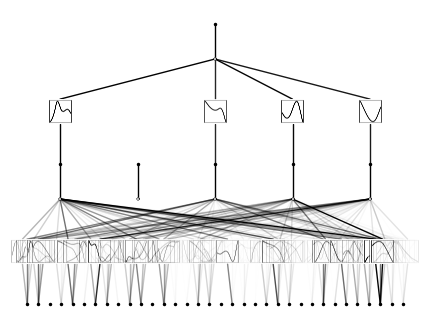

In [485]:
model.plot(beta=3, scale=0.5)


===== Top edges by FUSED importance (numeric spline edges only) =====
(l=1, i=4, j=0) | fused=0.802522 | nonlin_raw=8.173591e+00 | amp_raw=1.656397e+00
(l=0, i=33, j=2) | fused=0.716659 | nonlin_raw=8.186086e+00 | amp_raw=5.835015e-01
(l=0, i=8, j=0) | fused=0.699298 | nonlin_raw=5.399077e+00 | amp_raw=7.845859e-01
(l=0, i=33, j=4) | fused=0.583118 | nonlin_raw=4.920974e+00 | amp_raw=5.665555e-01
(l=0, i=12, j=2) | fused=0.580627 | nonlin_raw=6.459988e+00 | amp_raw=4.826319e-01
(l=1, i=2, j=0) | fused=0.570952 | nonlin_raw=3.767029e+00 | amp_raw=6.097700e-01
(l=0, i=4, j=4) | fused=0.558559 | nonlin_raw=2.152950e+00 | amp_raw=6.767109e-01
(l=0, i=14, j=4) | fused=0.557589 | nonlin_raw=1.495326e+01 | amp_raw=8.334304e-02
(l=0, i=5, j=4) | fused=0.553148 | nonlin_raw=8.006947e+00 | amp_raw=3.631934e-01
(l=0, i=31, j=3) | fused=0.540991 | nonlin_raw=1.296440e+01 | amp_raw=8.705219e-02

===== Bottom edges by FUSED importance (numeric spline edges only) =====
(l=0, i=17, j=1) | fused=0.019

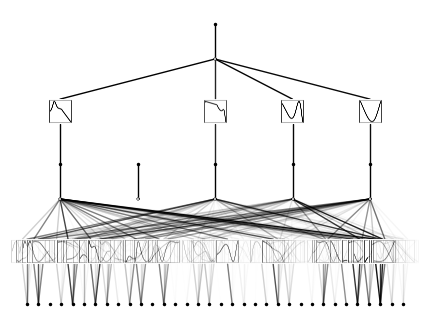

In [532]:
import torch
import numpy as np

torch.set_default_dtype(torch.float64)

# =========================
# 1) Scheme-C 非线性 raw（幅值解耦：对 v 标准化）
#    score_nonlin_raw = (1 - R^2) * log(1 + CI)
# =========================
@torch.no_grad()
def _scheme_c_nonlin_raw(u: torch.Tensor, v: torch.Tensor, eps: float = 1e-12) -> float:
    u = u.detach().flatten()
    v = v.detach().flatten()
    if u.numel() < 8:
        return 0.0

    m = torch.isfinite(u) & torch.isfinite(v)
    u = u[m]
    v = v[m]
    if u.numel() < 8:
        return 0.0

    # 幅值解耦：对 v 标准化
    v_std = v.std(unbiased=False)
    if (not torch.isfinite(v_std)) or float(v_std) < eps:
        return 0.0
    v = (v - v.mean()) / (v_std + eps)

    # (1) 偏离线性：1 - R^2
    u_mean = u.mean()
    u_var = (u - u_mean).pow(2).mean()
    if (not torch.isfinite(u_var)) or float(u_var) < eps:
        return 0.0

    v_mean = v.mean()
    cov = ((u - u_mean) * (v - v_mean)).mean()
    a = cov / (u_var + eps)
    b = v_mean - a * u_mean
    v_hat = a * u + b

    sse = (v - v_hat).pow(2).sum()
    sst = (v - v_mean).pow(2).sum() + eps
    nli = (sse / sst).clamp(min=0.0)  # = 1 - R^2

    # (2) 曲率 CI：E[(v'')^2]/(E[(v')^2]+eps)
    us, idx = torch.sort(u)
    vs = v[idx]

    du = us[1:] - us[:-1]
    dv = vs[1:] - vs[:-1]
    good = du.abs() > 1e-10
    if good.sum() < 4:
        ci = torch.tensor(0.0, dtype=v.dtype)
    else:
        du = du[good]
        dv = dv[good]
        v1 = dv / du  # 1st derivative approx

        du2 = du[1:]
        dv1 = v1[1:] - v1[:-1]
        good2 = du2.abs() > 1e-10
        if good2.sum() < 3:
            ci = torch.tensor(0.0, dtype=v.dtype)
        else:
            du2 = du2[good2]
            dv1 = dv1[good2]
            v2 = dv1 / du2  # 2nd derivative approx

            e1 = (v1.pow(2)).mean()
            e2 = (v2.pow(2)).mean()
            ci = e2 / (e1 + eps)

    score = nli * torch.log1p(ci)
    if not torch.isfinite(score):
        return 0.0
    return float(score.item())


# =========================
# 2) 全网分位数裁剪 + MinMax
# =========================
@torch.no_grad()
def _clip_minmax_all(values: torch.Tensor, q_low=0.01, q_high=0.99, eps=1e-12) -> torch.Tensor:
    v = values.detach().clone()
    v = torch.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.numel() == 0:
        return v

    lo = torch.quantile(v, q_low)
    hi = torch.quantile(v, q_high)
    if not torch.isfinite(lo): lo = torch.tensor(0.0, dtype=v.dtype)
    if not torch.isfinite(hi): hi = torch.tensor(0.0, dtype=v.dtype)
    v = torch.clamp(v, lo, hi)

    vmin = v.min()
    vmax = v.max()
    denom = (vmax - vmin).abs()
    if float(denom) < eps:
        return torch.zeros_like(v)
    return (v - vmin) / (denom + eps)


# =========================
# 3) MultKAN：计算每条“数值 spline 边”的重要性（融合指标）
#    - nonlin_raw: 用 postspline 做 Scheme-C
#    - amp_raw:    用 E[|postspline|]（只看 spline，避免 symbolic 污染）
#    - fused = w_nonlin*norm(nonlin_raw) + w_amp*norm(amp_raw)
# =========================
@torch.no_grad()
def compute_edge_importance_fused_multkan(
    model,
    dataset_cpu,
    importance_batch=4096,
    q_low=0.01,
    q_high=0.99,
    w_nonlin=0.5,
    w_amp=0.5,
    seed=0,
):
    model.eval()

    x_cpu = dataset_cpu["train_input"].detach().cpu().double()
    n = x_cpu.shape[0]
    m = min(int(importance_batch), n)

    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    idx = torch.randperm(n, generator=g)[:m]
    xs = x_cpu[idx].to(model.device)

    # 确保 forward 会保存 acts / spline_postsplines
    old_save_act = model.save_act
    model.save_act = True
    _ = model.forward(xs)
    model.save_act = old_save_act

    edges = []
    nonlin_raw_list = []
    amp_raw_list = []

    # depth = model.depth ; layer l corresponds to act_fun[l]
    for l in range(model.depth):
        in_dim = model.width_in[l]
        out_dim = model.width_out[l + 1]

        # u: model.acts[l][:, i]  (batch, in_dim)
        # v_spline: model.spline_postsplines[l][:, j, i]  (batch, out_dim, in_dim)
        mask_num = model.act_fun[l].mask.detach()  # (in_dim, out_dim)

        for i in range(in_dim):
            u = model.acts[l][:, i].detach().cpu().double()
            for j in range(out_dim):
                if float(mask_num[i, j].item()) <= 0.0:
                    continue

                v_spline = model.spline_postsplines[l][:, j, i].detach().cpu().double()

                nonlin_raw = _scheme_c_nonlin_raw(u, v_spline)
                amp_raw = float(v_spline.abs().mean().item())

                edges.append((l, i, j))
                nonlin_raw_list.append(nonlin_raw)
                amp_raw_list.append(amp_raw)

    if len(edges) == 0:
        return {}, {}, {}

    nonlin_raw_t = torch.tensor(nonlin_raw_list, dtype=torch.float64)
    amp_raw_t = torch.tensor(amp_raw_list, dtype=torch.float64)

    nonlin_norm = _clip_minmax_all(nonlin_raw_t, q_low=q_low, q_high=q_high)
    amp_norm = _clip_minmax_all(amp_raw_t, q_low=q_low, q_high=q_high)

    fused = w_nonlin * nonlin_norm + w_amp * amp_norm

    fused_dict = {e: float(fused[k].item()) for k, e in enumerate(edges)}
    nonlin_raw_dict = {e: float(nonlin_raw_t[k].item()) for k, e in enumerate(edges)}
    amp_raw_dict = {e: float(amp_raw_t[k].item()) for k, e in enumerate(edges)}
    return fused_dict, nonlin_raw_dict, amp_raw_dict


# =========================
# 4) plot + 输出 Top10/Bottom10
# =========================
@torch.no_grad()
def plot_and_rank_edges_multkan(
    model,
    dataset_cpu,
    topk=10,
    bottomk=10,
    importance_batch=4096,
    q_low=0.01,
    q_high=0.99,
    w_nonlin=0.5,
    w_amp=0.5,
    beta_plot=3,
    scale_plot=0.5,
    seed=0,
):
    fused_dict, nonlin_raw_dict, amp_raw_dict = compute_edge_importance_fused_multkan(
        model=model,
        dataset_cpu=dataset_cpu,
        importance_batch=importance_batch,
        q_low=q_low,
        q_high=q_high,
        w_nonlin=w_nonlin,
        w_amp=w_amp,
        seed=seed,
    )

    items = list(fused_dict.items())
    if len(items) == 0:
        print("[Warn] No active numeric-spline edges found (mask all zero?).")
        model.plot(beta=beta_plot, scale=scale_plot)
        return

    items_sorted = sorted(items, key=lambda kv: kv[1], reverse=True)
    top_items = items_sorted[:min(topk, len(items_sorted))]
    bottom_items = list(reversed(items_sorted))[:min(bottomk, len(items_sorted))]

    def fmt(edge, fused):
        l, i, j = edge
        return (
            f"(l={l}, i={i}, j={j}) | fused={fused:.6f} | "
            f"nonlin_raw={nonlin_raw_dict[edge]:.6e} | amp_raw={amp_raw_dict[edge]:.6e}"
        )

    print("\n===== Top edges by FUSED importance (numeric spline edges only) =====")
    for edge, fused in top_items:
        print(fmt(edge, fused))

    print("\n===== Bottom edges by FUSED importance (numeric spline edges only) =====")
    for edge, fused in bottom_items:
        print(fmt(edge, fused))

    # 画图
    model.plot(beta=beta_plot, scale=scale_plot)


# =========================
# 5) 用法：训练完后直接调用
# =========================
plot_and_rank_edges_multkan(
    model=model,
    dataset_cpu=dataset_cpu,
    topk=10,
    bottomk=10,
    importance_batch=4096,
    q_low=0.01,
    q_high=0.99,
    w_nonlin=0.5,
    w_amp=0.5,
    beta_plot=3,
    scale_plot=0.5,
    seed=0,
)


In [421]:
# -*- coding: utf-8 -*-
import math
import copy
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

# 用你项目里的自定义 LBFGS
from kan.LBFGS import LBFGS

torch.set_default_dtype(torch.float64)

# ============================================================
# Global settings for normalization (全网络一起 Norm)
# 选择：分位数裁剪 + Min–Max 归一化
# 你可自行调整裁剪分位数
# ============================================================
NORM_Q_LOW = 0.01
NORM_Q_HIGH = 0.99
NORM_EPS = 1e-12

ALPHA = 0.5
BETA = 0.5


# ============================================================
# 1) B-spline basis (Cox–de Boor)
# ============================================================
def make_uniform_knots(xmin: float, xmax: float, num_intervals: int, degree: int, device):
    breaks = torch.linspace(xmin, xmax, steps=num_intervals + 1, device=device)
    left = breaks[0].repeat(degree)
    right = breaks[-1].repeat(degree)
    knots = torch.cat([left, breaks, right], dim=0)
    return knots


def bspline_basis_1d(x: torch.Tensor, knots: torch.Tensor, degree: int) -> torch.Tensor:
    if x.dim() == 2:
        x = x[:, 0]
    B = x.shape[0]
    device = x.device

    M = knots.numel()
    n_basis = M - degree - 1

    N = torch.zeros(B, n_basis, device=device, dtype=x.dtype)

    # degree-0
    for i in range(n_basis):
        k0 = knots[i]
        k1 = knots[i + 1]
        in_span = (x >= k0) & (x < k1)
        N[:, i] = in_span.to(x.dtype)

    # include right boundary
    last = (x == knots[-1])
    if last.any():
        N[last, -1] = 1.0

    # recursion
    for p in range(1, degree + 1):
        Np = torch.zeros(B, n_basis, device=device, dtype=x.dtype)
        for i in range(n_basis):
            left_den = knots[i + p] - knots[i]
            right_den = knots[i + p + 1] - knots[i + 1]

            left = torch.zeros(B, device=device, dtype=x.dtype)
            right = torch.zeros(B, device=device, dtype=x.dtype)

            if left_den != 0:
                left = ((x - knots[i]) / left_den) * N[:, i]
            if right_den != 0 and (i + 1) < n_basis:
                right = ((knots[i + p + 1] - x) / right_den) * N[:, i + 1]

            Np[:, i] = left + right
        N = Np

    return N


# ============================================================
# 2) A single per-edge KAN unit
# ============================================================
class PerEdgeKANUnit(nn.Module):
    """
    One edge: x -> sb*base_fun(x) + ss*spline(x)
    Each edge has its own grid/knots/coef.
    """

    def __init__(
        self,
        num_intervals: int = 3,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.degree = int(degree)
        self.num_intervals = int(num_intervals)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.base_fun = base_fun

        knots = make_uniform_knots(self.x_min, self.x_max, self.num_intervals, self.degree, device=torch.device(device))
        self.register_buffer("knots", knots)

        n_basis = self.knots.numel() - self.degree - 1
        self.coef = nn.Parameter(torch.zeros(n_basis, device=device))
        self.scale_base = nn.Parameter(torch.tensor(1.0, device=device))
        self.scale_sp = nn.Parameter(torch.tensor(1.0, device=device))

        # prune mask
        self.mask = nn.Parameter(torch.tensor(1.0, device=device), requires_grad=False)

    def _base(self, x):
        if self.base_fun == "silu":
            return F.silu(x)
        if self.base_fun == "identity":
            return x
        if self.base_fun == "tanh":
            return torch.tanh(x)
        raise ValueError(f"Unsupported base_fun: {self.base_fun}")

    def forward_spline(self, x: torch.Tensor) -> torch.Tensor:
        """Spline-only output (postspline): spline(x) = basis @ coef (no scale_sp, no base)."""
        if x.dim() == 1:
            x1 = x[:, None]
        else:
            x1 = x
        xc = torch.clamp(x1, self.x_min, self.x_max)
        basis = bspline_basis_1d(xc, self.knots, self.degree)
        spline = (basis @ self.coef)  # (B,)
        return spline

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 1:
            x1 = x[:, None]
        else:
            x1 = x

        xc = torch.clamp(x1, self.x_min, self.x_max)
        basis = bspline_basis_1d(xc, self.knots, self.degree)
        spline = (basis @ self.coef)[:, None]
        base = self._base(xc)

        y = self.scale_base * base + self.scale_sp * spline
        return self.mask * y

    @torch.no_grad()
    def change_grid_cpu(self, new_num_intervals: int, sample_x: torch.Tensor, preserve_shape: bool = True):
        """
        IMPORTANT: This function should be called on CPU model.
        It rebuilds knots and refits coef via least squares.
        """
        new_num_intervals = int(new_num_intervals)
        if new_num_intervals < 1:
            raise ValueError("new_num_intervals must be >= 1")
        if new_num_intervals == self.num_intervals:
            return

        device = self.coef.device
        sample_x = sample_x.detach().to(device)
        if sample_x.dim() == 1:
            sample_x = sample_x[:, None]

        if preserve_shape:
            y_old = self.forward(sample_x)[:, 0]
        else:
            y_old = torch.zeros(sample_x.shape[0], device=device, dtype=sample_x.dtype)

        new_knots = make_uniform_knots(self.x_min, self.x_max, new_num_intervals, self.degree, device=device)

        sb = self.scale_base.detach()
        ss = self.scale_sp.detach()
        eps = torch.tensor(1e-12, device=device, dtype=sb.dtype)
        denom = torch.where(ss.abs() < eps, eps, ss)

        xc = torch.clamp(sample_x, self.x_min, self.x_max)
        base = self._base(xc)[:, 0]
        target_spline = (y_old - sb * base) / denom

        Bmat = bspline_basis_1d(xc, new_knots, self.degree)
        sol = torch.linalg.lstsq(Bmat, target_spline).solution
        sol = torch.nan_to_num(sol)

        # apply
        self.num_intervals = new_num_intervals
        self._buffers["knots"] = new_knots
        self.coef = nn.Parameter(sol.clone())
        self._parameters["coef"] = self.coef


# ============================================================
# 3) Per-edge KAN layer
# ============================================================
class PerEdgeKANLayer(nn.Module):
    """
    Fully-connected per-edge units: out_dim x in_dim independent units.
    units[j][i]: edge i->j
    """

    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.grid_max = int(grid_max)

        self.units = nn.ModuleList([
            nn.ModuleList([
                PerEdgeKANUnit(
                    num_intervals=grid_init,
                    degree=degree,
                    x_min=x_min,
                    x_max=x_max,
                    base_fun=base_fun,
                    device=device,
                )
                for _ in range(self.in_dim)
            ])
            for _ in range(self.out_dim)
        ])

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        B = x.shape[0]
        post = torch.zeros(B, self.out_dim, self.in_dim, device=x.device, dtype=x.dtype)
        for j in range(self.out_dim):
            for i in range(self.in_dim):
                post[:, j, i] = self.units[j][i](x[:, i])[:, 0]
        y = post.sum(dim=2)
        if return_postacts:
            return y, post
        return y

    def edge_grid(self, j: int, i: int) -> int:
        return self.units[j][i].num_intervals

    @torch.no_grad()
    def set_edge_mask(self, j: int, i: int, value: float):
        self.units[j][i].mask.fill_(float(value))

    @torch.no_grad()
    def change_edge_grid_cpu(self, j: int, i: int, new_grid: int, sample_x_1d: torch.Tensor):
        u = self.units[j][i]
        if float(u.mask.item()) == 0.0:
            return
        new_grid = int(new_grid)
        new_grid = max(1, min(self.grid_max, new_grid))
        u.change_grid_cpu(new_grid, sample_x=sample_x_1d, preserve_shape=True)


# ============================================================
# 4) PerEdgeKAN model
# ============================================================
class PerEdgeKAN(nn.Module):
    def __init__(
        self,
        width: List[int],
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        assert len(width) >= 2
        self.width = list(map(int, width))
        self.grid_init = int(grid_init)
        self.grid_max = int(grid_max)

        layers = []
        for li in range(len(self.width) - 1):
            layers.append(
                PerEdgeKANLayer(
                    in_dim=self.width[li],
                    out_dim=self.width[li + 1],
                    grid_init=self.grid_init,
                    grid_max=self.grid_max,
                    degree=degree,
                    x_min=x_min,
                    x_max=x_max,
                    base_fun=base_fun,
                    device=device,
                )
            )
        self.layers = nn.ModuleList(layers)
        self.to(torch.device(device))

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        posts_all = []
        h = x
        for layer in self.layers:
            if return_postacts:
                h, post = layer(h, return_postacts=True)
                posts_all.append(post)
            else:
                h = layer(h, return_postacts=False)
        if return_postacts:
            return h, posts_all
        return h

    def copy(self):
        return copy.deepcopy(self)

    def get_reg(self, lamb_l1=1.0):
        reg = torch.tensor(0.0, device=self.device, dtype=torch.get_default_dtype())
        for layer in self.layers:
            for j in range(layer.out_dim):
                for i in range(layer.in_dim):
                    u = layer.units[j][i]
                    if float(u.mask.item()) == 0.0:
                        continue
                    reg = reg + (u.scale_sp.abs() + u.coef.abs().mean()) * lamb_l1
        return reg


# ============================================================
# 5) Training + evaluation
# ============================================================
@dataclass
class FitConfig:
    steps: int = 50
    lr: float = 1.0
    lamb: float = 1e-3
    lamb_l1: float = 1.0
    verbose: bool = True


def mse_loss(pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.mean((pred - y) ** 2)


@torch.no_grad()
def eval_acc_123(pred: torch.Tensor, y_true: torch.Tensor) -> float:
    pred_cls = torch.round(pred).clamp(1, 3)
    correct = (pred_cls == y_true).double().mean().item()
    return float(correct)


def fit_lbfgs(model: PerEdgeKAN, dataset: Dict[str, torch.Tensor], cfg: FitConfig):
    x = dataset["train_input"].to(model.device)
    y = dataset["train_label"].to(model.device)

    opt = LBFGS(model.parameters(), lr=cfg.lr, max_iter=cfg.steps, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        pred = model(x)
        loss_pred = mse_loss(pred, y)
        loss_reg = model.get_reg(lamb_l1=cfg.lamb_l1)
        loss = loss_pred + cfg.lamb * loss_reg
        loss.backward()
        return loss

    loss0 = float(closure().detach().cpu())
    opt.step(closure)

    if cfg.verbose:
        with torch.no_grad():
            pred_tr = model(x)
            tr_mse = float(mse_loss(pred_tr, y).cpu())
            tr_acc = eval_acc_123(pred_tr, y)

            msg = f"[fit] loss0={loss0:.6e} train_mse={tr_mse:.6e} train_acc={tr_acc:.4f}"
            if "test_input" in dataset:
                xt = dataset["test_input"].to(model.device)
                yt = dataset["test_label"].to(model.device)
                pred_te = model(xt)
                te_mse = float(mse_loss(pred_te, yt).cpu())
                te_acc = eval_acc_123(pred_te, yt)
                msg += f" | test_mse={te_mse:.6e} test_acc={te_acc:.4f}"
            print(msg)


# ============================================================
# 6) Nonlinearity score (Scheme C, amplitude-agnostic via v standardization)
#    Score_nonlin = (1 - R^2) * log(1 + CI)
#    CI = E[(v'')^2] / (E[(v')^2] + eps), computed on standardized v.
#    Use spline-only output (postspline) to align with "grid" meaning.
# ============================================================
@torch.no_grad()
def _score_scheme_c(u: torch.Tensor, v: torch.Tensor, eps: float = 1e-12) -> float:
    """
    u: (N,) edge input samples (CPU)
    v: (N,) edge spline output samples (CPU)  (postspline)
    returns: float score (>=0)
    """
    u = u.detach().flatten()
    v = v.detach().flatten()
    if u.numel() < 8:
        return 0.0

    mask = torch.isfinite(u) & torch.isfinite(v)
    u = u[mask]
    v = v[mask]
    if u.numel() < 8:
        return 0.0

    # standardize v to remove amplitude
    v_std = v.std(unbiased=False)
    if (not torch.isfinite(v_std)) or float(v_std) < eps:
        return 0.0
    v = (v - v.mean()) / (v_std + eps)

    # (A) 1 - R^2 for linear fit u->v
    u_mean = u.mean()
    u_var = (u - u_mean).pow(2).mean()
    if (not torch.isfinite(u_var)) or float(u_var) < eps:
        return 0.0

    cov = ((u - u_mean) * (v - v.mean())).mean()
    a = cov / (u_var + eps)
    b = v.mean() - a * u_mean
    v_hat = a * u + b

    sse = (v - v_hat).pow(2).sum()
    sst = (v - v.mean()).pow(2).sum() + eps
    nli = (sse / sst).clamp(min=0.0)  # = 1 - R^2, in [0,1] ideally

    # (B) curvature index CI
    us, idx = torch.sort(u)
    vs = v[idx]
    du = us[1:] - us[:-1]
    dv = vs[1:] - vs[:-1]

    good = du.abs() > 1e-10
    if good.sum() < 4:
        ci = torch.tensor(0.0, dtype=v.dtype)
    else:
        du = du[good]
        dv = dv[good]
        v1 = dv / du  # first derivative

        du2 = du[1:]
        dv1 = v1[1:] - v1[:-1]
        good2 = du2.abs() > 1e-10
        if good2.sum() < 3:
            ci = torch.tensor(0.0, dtype=v.dtype)
        else:
            du2 = du2[good2]
            dv1 = dv1[good2]
            v2 = dv1 / du2  # second derivative

            e1 = (v1.pow(2)).mean()
            e2 = (v2.pow(2)).mean()
            ci = e2 / (e1 + eps)

    score = nli * torch.log1p(ci)
    if not torch.isfinite(score):
        return 0.0
    return float(score.item())


# ============================================================
# 7) Global quantile-clipped Min-Max normalization (全网一起)
#    Norm(x) = (clip(x,qL,qH) - min) / (max - min + eps)
# ============================================================
@torch.no_grad()
def _norm_global_quantile_minmax(values: torch.Tensor, q_low: float, q_high: float, eps: float) -> torch.Tensor:
    """
    values: (E,) tensor, finite, >=0 recommended
    returns: (E,) in [0,1]
    """
    if values.numel() == 0:
        return values
    v = values.clone()
    v = torch.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.numel() == 1:
        return torch.ones_like(v)

    lo = torch.quantile(v, q_low)
    hi = torch.quantile(v, q_high)
    if not torch.isfinite(lo):
        lo = torch.tensor(0.0, dtype=v.dtype)
    if not torch.isfinite(hi):
        hi = torch.max(v)

    # if degenerate, return zeros
    if float(hi - lo) < eps:
        return torch.zeros_like(v)

    v = torch.clamp(v, lo, hi)
    vmin = torch.min(v)
    vmax = torch.max(v)
    if float(vmax - vmin) < eps:
        return torch.zeros_like(v)
    return (v - vmin) / (vmax - vmin + eps)


# ============================================================
# 8) Importance = 0.5*Norm(Amp) + 0.5*Norm(Nonlin)
#    - Amp: 与论文(15)相似的“激活度”风格，这里用 E[|f_ij(x)|]
#           其中 f_ij(x) 取 edge 的 postact（完整 edge 输出：sb*base + ss*spline）并乘 mask
#    - Nonlin: Scheme-C 在 postspline 上计算（并在内部对 v 标准化，尽量与幅值解耦）
#    - 两个 Norm：全网络一起做 分位数裁剪+MinMax
# ============================================================
@torch.no_grad()
def edge_importance_fused_amp_nonlin(
    model: PerEdgeKAN,
    x_samples_cpu: torch.Tensor,
    q_low: float = NORM_Q_LOW,
    q_high: float = NORM_Q_HIGH,
    eps: float = NORM_EPS,
    alpha: float = ALPHA,
    beta: float = BETA,
) -> Tuple[Dict[Tuple[int, int, int], float], Dict[Tuple[int, int, int], float], Dict[Tuple[int, int, int], float]]:
    """
    Returns:
      imp_fused[(li,j,i)] = fused score
      imp_amp[(li,j,i)]   = raw amp (before Norm)
      imp_nonlin[(li,j,i)] = raw nonlin (before Norm)
    """
    model_cpu = model.copy().to("cpu").eval()
    xs = x_samples_cpu.detach().cpu().double()

    keys = []
    amp_raw_list = []
    nonlin_raw_list = []

    imp_amp: Dict[Tuple[int, int, int], float] = {}
    imp_nonlin: Dict[Tuple[int, int, int], float] = {}
    imp_fused: Dict[Tuple[int, int, int], float] = {}

    for li, layer in enumerate(model_cpu.layers):
        for j in range(layer.out_dim):
            for i in range(layer.in_dim):
                u_unit = layer.units[j][i]
                k = (li, j, i)

                if float(u_unit.mask.item()) == 0.0:
                    imp_amp[k] = -1.0
                    imp_nonlin[k] = -1.0
                    imp_fused[k] = -1.0
                    continue

                u = xs[:, i]

                # (1) Amp: E[ |f_ij(x)| ]  (f_ij 用完整 edge 输出)
                y_edge = u_unit(u)[:, 0]  # (N,)
                amp = torch.mean(torch.abs(y_edge))
                if not torch.isfinite(amp):
                    amp = torch.tensor(0.0, dtype=xs.dtype)

                # (2) Nonlin: Scheme C on postspline (standardize v inside)
                v_spline = u_unit.forward_spline(u)  # (N,)
                nonlin = torch.tensor(_score_scheme_c(u, v_spline, eps=1e-12), dtype=xs.dtype)

                keys.append(k)
                amp_raw_list.append(amp)
                nonlin_raw_list.append(nonlin)

                imp_amp[k] = float(amp.item())
                imp_nonlin[k] = float(nonlin.item())

    if len(keys) == 0:
        return imp_fused, imp_amp, imp_nonlin

    amp_raw = torch.stack(amp_raw_list)          # (E,)
    nonlin_raw = torch.stack(nonlin_raw_list)    # (E,)

    # Global Norm (全网一起，分位数裁剪 + MinMax)
    amp_norm = _norm_global_quantile_minmax(amp_raw, q_low=q_low, q_high=q_high, eps=eps)
    nonlin_norm = _norm_global_quantile_minmax(nonlin_raw, q_low=q_low, q_high=q_high, eps=eps)

    fused = alpha * amp_norm + beta * nonlin_norm

    for idx, k in enumerate(keys):
        imp_fused[k] = float(fused[idx].item())

    return imp_fused, imp_amp, imp_nonlin


@torch.no_grad()
def pick_edge_for_increase_by_score(model: PerEdgeKAN, imp: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    """Pick HIGHEST score edge among those with grid < grid_max."""
    cand = []
    for (li, j, i), v in imp.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        if u.num_intervals < layer.grid_max:
            cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1], reverse=True)
    return cand[0][0]


@torch.no_grad()
def pick_edge_for_decrease_or_prune_by_score(model: PerEdgeKAN, imp: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    """Pick LOWEST score edge among unpruned edges."""
    cand = []
    for (li, j, i), v in imp.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1])  # ascending
    return cand[0][0]


def cpu_apply_plus_minus_grid(
    model: PerEdgeKAN,
    x_samples_cpu: torch.Tensor,
    edge_up: Optional[Tuple[int, int, int]],
    edge_down: Optional[Tuple[int, int, int]],
    grid_min: int = 1,
):
    """
    IMPORTANT: grid update MUST be on CPU.
    - move a COPY of model to CPU
    - apply +grid and -grid/prune on CPU
    - return updated CPU model
    """
    m_cpu = model.copy().to("cpu")
    x_samples_cpu = x_samples_cpu.detach().cpu().double()

    # +grid
    if edge_up is not None:
        li, j, i = edge_up
        layer = m_cpu.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) != 0.0 and u.num_intervals < layer.grid_max:
            layer.change_edge_grid_cpu(j, i, u.num_intervals + 1, sample_x_1d=x_samples_cpu[:, i])

    # -grid or prune
    if edge_down is not None:
        li, j, i = edge_down
        layer = m_cpu.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) != 0.0:
            if u.num_intervals <= grid_min:
                layer.set_edge_mask(j, i, 0.0)  # prune
            else:
                layer.change_edge_grid_cpu(j, i, u.num_intervals - 1, sample_x_1d=x_samples_cpu[:, i])

    return m_cpu


def cpu_short_run(model_cpu: PerEdgeKAN, dataset_cpu: Dict[str, torch.Tensor], steps: int = 5, lamb: float = 1e-3):
    """Optional: CPU short LBFGS to stabilize after grid changes."""
    cfg = FitConfig(steps=steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=False)
    fit_lbfgs(model_cpu, dataset_cpu, cfg)
    return model_cpu


# ============================================================
# 9) Main iterative refinement (FUSED importance)
# ============================================================
def iterative_refine_strict_per_edge_fused(
    dataset: Dict[str, torch.Tensor],
    dataset_cpu: Dict[str, torch.Tensor],
    width: List[int] = [34, 4, 1],
    grid_init: int = 3,
    grid_min: int = 1,
    grid_max: int = 10,
    refine_iters: int = 100,
    init_steps: int = 50,
    per_iter_gpu_steps: int = 50,
    lamb: float = 1e-3,
    importance_batch: int = 4096,  # 用于采样计算 importance + change_grid 的 least-squares 拟合
    device: str = "cuda",
    x_min: float = -5.0,
    x_max: float = 5.0,
    verbose: int = 1,
    q_low: float = NORM_Q_LOW,
    q_high: float = NORM_Q_HIGH,
    alpha: float = ALPHA,
    beta: float = BETA,
):
    """
    0) init model with grid=3
    1) GPU train
    2) repeat N:
        - sample xs on CPU
        - compute fused importance:
            Score = alpha*Norm(Amp) + beta*Norm(Score_nonlin)
            (全网一起 Norm；分位数裁剪+MinMax)
        - +grid on highest-score eligible edge
        - -grid on lowest-score edge; if grid==1 => prune
        - CPU grid update + CPU short-run
        - back to GPU retrain
    """

    # -------- init strict per-edge model --------
    model = PerEdgeKAN(
        width=width,
        grid_init=grid_init,
        grid_max=grid_max,
        degree=3,
        x_min=x_min,
        x_max=x_max,
        base_fun="silu",
        device=device,
    )

    # -------- initial GPU training --------
    if verbose:
        print("\n==== Initial training (GPU, FUSED importance; grid change on CPU) ====")
    cfg0 = FitConfig(steps=init_steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=bool(verbose))
    fit_lbfgs(model, dataset, cfg0)

    x_train_cpu = dataset_cpu["train_input"]
    n = x_train_cpu.shape[0]

    # -------- refinement loop --------
    for it in range(1, refine_iters + 1):
        # sample for importance + change_grid refit
        m = min(int(importance_batch), n)
        idx = torch.randperm(n)[:m]
        xs_cpu = x_train_cpu[idx].detach().cpu().double()

        # (A) fused importance (data-dependent)
        imp_fused, imp_amp_raw, imp_nonlin_raw = edge_importance_fused_amp_nonlin(
            model,
            xs_cpu,
            q_low=q_low,
            q_high=q_high,
            eps=NORM_EPS,
            alpha=alpha,
            beta=beta,
        )

        edge_up = pick_edge_for_increase_by_score(model, imp_fused)
        edge_down = pick_edge_for_decrease_or_prune_by_score(model, imp_fused)

        # avoid same edge chosen for both
        if edge_up is not None and edge_down is not None and edge_up == edge_down:
            tmp = dict(imp_fused)
            tmp[edge_down] = float("inf")
            edge_down = pick_edge_for_decrease_or_prune_by_score(model, tmp)

        # ---- CPU grid update ----
        model_cpu = cpu_apply_plus_minus_grid(
            model, xs_cpu,
            edge_up=edge_up,
            edge_down=edge_down,
            grid_min=grid_min,
        )

        # optional CPU short run (stabilize after grid changes)
        model_cpu = cpu_short_run(model_cpu, dataset_cpu, steps=5, lamb=lamb)

        # back to GPU
        model = model_cpu.to(device)

        if verbose:
            def edge_str(e):
                if e is None:
                    return "None"
                li, j, i = e
                u = model.layers[li].units[j][i]
                sf = imp_fused.get((li, j, i), float("nan"))
                sa = imp_amp_raw.get((li, j, i), float("nan"))
                sn = imp_nonlin_raw.get((li, j, i), float("nan"))
                return (f"(L{li} o{j}<-i{i}, grid={u.num_intervals}, mask={float(u.mask.item())}"
                        f", fused={sf:.3e}, amp_raw={sa:.3e}, nonlin_raw={sn:.3e})")
            print(f"\n[Iter {it}/{refine_iters}] +grid: {edge_str(edge_up)} | -grid/prune: {edge_str(edge_down)}")

        # ---- GPU retrain ----
        cfg = FitConfig(steps=per_iter_gpu_steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=bool(verbose))
        fit_lbfgs(model, dataset, cfg)

    return model


# ============================================================
# 10) USAGE (你 notebook 里已经有 dataset / dataset_cpu / device)
# ============================================================
# 直接跑：
model = iterative_refine_strict_per_edge_fused(
    dataset=dataset,
    dataset_cpu=dataset_cpu,
    width=[34, 4, 1],
    grid_init=3,
    grid_min=1,
    grid_max=10,
    refine_iters=50,          # 你真实跑设为 100
    init_steps=50,
    per_iter_gpu_steps=50,
    lamb=0.001,
    importance_batch=4096,
    device=str(device),       # 你 notebook 里 device 是 torch.device(...)
    x_min=-5.0,
    x_max=5.0,
    verbose=1,
    q_low=0.01,
    q_high=0.99,
    alpha=0.7,
    beta=0.3,
)





==== Initial training (GPU, FUSED importance; grid change on CPU) ====
[fit] loss0=1.873414e+02 train_mse=5.182076e-01 train_acc=0.4702 | test_mse=5.282232e-01 test_acc=0.4657

[Iter 1/50] +grid: (L0 o0<-i10, grid=4, mask=1.0, fused=7.395e-01, amp_raw=9.260e-01, nonlin_raw=1.647e+00) | -grid/prune: (L0 o0<-i11, grid=2, mask=1.0, fused=7.634e-05, amp_raw=2.341e-02, nonlin_raw=6.465e-02)
[fit] loss0=5.724227e-01 train_mse=3.617118e-01 train_acc=0.5617 | test_mse=3.908967e-01 test_acc=0.5550

[Iter 2/50] +grid: (L0 o1<-i10, grid=4, mask=1.0, fused=7.357e-01, amp_raw=1.027e+00, nonlin_raw=1.438e+00) | -grid/prune: (L0 o1<-i17, grid=2, mask=1.0, fused=1.274e-04, amp_raw=9.401e-03, nonlin_raw=6.709e-02)
[fit] loss0=4.158616e-01 train_mse=3.105489e-01 train_acc=0.6290 | test_mse=3.391407e-01 test_acc=0.6131

[Iter 3/50] +grid: (L0 o0<-i1, grid=4, mask=1.0, fused=8.572e-01, amp_raw=1.052e+00, nonlin_raw=7.584e+00) | -grid/prune: (L0 o1<-i17, grid=1, mask=1.0, fused=3.718e-03, amp_raw=1.400e-0

KeyboardInterrupt: 

In [282]:
import torch

@torch.no_grad()
def plot_and_print_edge_rankings_fused(
    model,
    dataset_cpu,
    topk=10,
    bottomk=10,
    importance_batch=4096,
    q_low=0.01,
    q_high=0.99,
    alpha=0.5,
    beta=0.5,
    beta_plot=3,
    scale_plot=0.5,
    seed=0,
):
    # 1) 采样（CPU）用于计算重要性
    x_train_cpu = dataset_cpu["train_input"].detach().cpu().double()
    n = x_train_cpu.shape[0]
    m = min(int(importance_batch), n)

    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    idx = torch.randperm(n, generator=g)[:m]
    xs_cpu = x_train_cpu[idx]

    # 2) 计算融合重要性（全网 Norm + 分位数裁剪 + MinMax）
    #    这里复用你已有的函数：edge_importance_fused_amp_nonlin
    imp_fused, imp_amp_raw, imp_nonlin_raw = edge_importance_fused_amp_nonlin(
        model,
        xs_cpu,
        q_low=q_low,
        q_high=q_high,
        alpha=alpha,
        beta=beta,
    )

    # 3) 过滤掉已剪枝边（score < 0）
    items = [(k, v) for k, v in imp_fused.items() if v >= 0]
    if len(items) == 0:
        print("No active edges found (all pruned?).")
        # 仍然画图
        if hasattr(model, "plot"):
            model.plot(beta=beta_plot, scale=scale_plot)
        return

    # 4) 排序并输出 Top/Bottom
    items_sorted = sorted(items, key=lambda t: t[1], reverse=True)
    top_items = items_sorted[:min(topk, len(items_sorted))]
    bottom_items = list(reversed(items_sorted))[:min(bottomk, len(items_sorted))]

    def fmt_edge(k, fused):
        li, j, i = k
        # 读取当前 grid/mask（若你的模型结构与我给的 PerEdgeKAN 一致）
        try:
            u = model.layers[li].units[j][i]
            grid = int(u.num_intervals)
            mask = float(u.mask.item())
        except Exception:
            grid, mask = None, None
        amp = imp_amp_raw.get(k, float("nan"))
        nonlin = imp_nonlin_raw.get(k, float("nan"))
        return f"{k} | fused={fused:.6e} | amp_raw={amp:.6e} | nonlin_raw={nonlin:.6e} | grid={grid} | mask={mask}"

    print("\n===== Top-10 edges by FUSED importance =====")
    for k, v in top_items:
        print(fmt_edge(k, v))

    print("\n===== Bottom-10 edges by FUSED importance =====")
    for k, v in bottom_items:
        print(fmt_edge(k, v))

    # 5) 画图
    if hasattr(model, "plot"):
        model.plot(beta=beta_plot, scale=scale_plot)
    else:
        print("\n[Warn] model.plot(...) not found on this model object.")


# —— 直接调用（你已拥有 model / dataset_cpu）——
plot_and_print_edge_rankings_fused(
    model=model,
    dataset_cpu=dataset_cpu,
    topk=10,
    bottomk=10,
    importance_batch=4096,
    q_low=0.01,
    q_high=0.99,
    alpha=0.5,
    beta=0.5,
    beta_plot=3,
    scale_plot=0.5,
    seed=0,
)



===== Top-10 edges by FUSED importance =====
(0, 3, 1) | fused=7.209892e-01 | amp_raw=1.746538e+00 | nonlin_raw=4.486091e+00 | grid=10 | mask=1.0
(0, 1, 18) | fused=5.682600e-01 | amp_raw=2.357164e-01 | nonlin_raw=1.008479e+01 | grid=3 | mask=1.0
(0, 1, 25) | fused=5.682600e-01 | amp_raw=2.357164e-01 | nonlin_raw=1.008479e+01 | grid=3 | mask=1.0
(0, 0, 10) | fused=5.503954e-01 | amp_raw=1.451298e+00 | nonlin_raw=2.395656e+00 | grid=4 | mask=1.0
(1, 0, 1) | fused=5.311554e-01 | amp_raw=1.401575e+00 | nonlin_raw=2.309434e+00 | grid=4 | mask=1.0
(0, 1, 1) | fused=5.248631e-01 | amp_raw=1.027675e+00 | nonlin_raw=4.438008e+00 | grid=4 | mask=1.0
(0, 0, 1) | fused=5.087708e-01 | amp_raw=9.343532e-01 | nonlin_raw=4.677881e+00 | grid=4 | mask=1.0
(0, 2, 6) | fused=5.039102e-01 | amp_raw=1.942427e+00 | nonlin_raw=1.301297e-01 | grid=4 | mask=1.0
(0, 1, 24) | fused=5.031435e-01 | amp_raw=1.904660e-02 | nonlin_raw=1.076211e+01 | grid=3 | mask=1.0
(1, 0, 0) | fused=4.860382e-01 | amp_raw=1.416845

In [219]:
# -*- coding: utf-8 -*-
import math
import copy
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

# 用你项目里的自定义 LBFGS
from kan.LBFGS import LBFGS

torch.set_default_dtype(torch.float64)


# ============================================================
# 1) B-spline basis (Cox–de Boor)
# ============================================================
def make_uniform_knots(xmin: float, xmax: float, num_intervals: int, degree: int, device):
    breaks = torch.linspace(xmin, xmax, steps=num_intervals + 1, device=device)
    left = breaks[0].repeat(degree)
    right = breaks[-1].repeat(degree)
    knots = torch.cat([left, breaks, right], dim=0)
    return knots


def bspline_basis_1d(x: torch.Tensor, knots: torch.Tensor, degree: int) -> torch.Tensor:
    if x.dim() == 2:
        x = x[:, 0]
    B = x.shape[0]
    device = x.device

    M = knots.numel()
    n_basis = M - degree - 1

    N = torch.zeros(B, n_basis, device=device, dtype=x.dtype)

    # degree-0
    for i in range(n_basis):
        k0 = knots[i]
        k1 = knots[i + 1]
        in_span = (x >= k0) & (x < k1)
        N[:, i] = in_span.to(x.dtype)

    # include right boundary
    last = (x == knots[-1])
    if last.any():
        N[last, -1] = 1.0

    # recursion
    for p in range(1, degree + 1):
        Np = torch.zeros(B, n_basis, device=device, dtype=x.dtype)
        for i in range(n_basis):
            left_den = knots[i + p] - knots[i]
            right_den = knots[i + p + 1] - knots[i + 1]

            left = torch.zeros(B, device=device, dtype=x.dtype)
            right = torch.zeros(B, device=device, dtype=x.dtype)

            if left_den != 0:
                left = ((x - knots[i]) / left_den) * N[:, i]
            if right_den != 0 and (i + 1) < n_basis:
                right = ((knots[i + p + 1] - x) / right_den) * N[:, i + 1]

            Np[:, i] = left + right
        N = Np

    return N


# ============================================================
# 2) A single per-edge KAN unit
# ============================================================
class PerEdgeKANUnit(nn.Module):
    """
    One edge: x -> sb*base_fun(x) + ss*spline(x)
    Each edge has its own grid/knots/coef.
    """

    def __init__(
        self,
        num_intervals: int = 3,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.degree = int(degree)
        self.num_intervals = int(num_intervals)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.base_fun = base_fun

        knots = make_uniform_knots(self.x_min, self.x_max, self.num_intervals, self.degree, device=torch.device(device))
        self.register_buffer("knots", knots)

        n_basis = self.knots.numel() - self.degree - 1
        self.coef = nn.Parameter(torch.zeros(n_basis, device=device))
        self.scale_base = nn.Parameter(torch.tensor(1.0, device=device))
        self.scale_sp = nn.Parameter(torch.tensor(1.0, device=device))

        # prune mask
        self.mask = nn.Parameter(torch.tensor(1.0, device=device), requires_grad=False)

    def _base(self, x):
        if self.base_fun == "silu":
            return F.silu(x)
        if self.base_fun == "identity":
            return x
        if self.base_fun == "tanh":
            return torch.tanh(x)
        raise ValueError(f"Unsupported base_fun: {self.base_fun}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 1:
            x1 = x[:, None]
        else:
            x1 = x

        xc = torch.clamp(x1, self.x_min, self.x_max)
        basis = bspline_basis_1d(xc, self.knots, self.degree)
        spline = (basis @ self.coef)[:, None]
        base = self._base(xc)

        y = self.scale_base * base + self.scale_sp * spline
        return self.mask * y

    @torch.no_grad()
    def change_grid_cpu(self, new_num_intervals: int, sample_x: torch.Tensor, preserve_shape: bool = True):
        """
        IMPORTANT: This function should be called on CPU model.
        It rebuilds knots and refits coef via least squares.
        """
        new_num_intervals = int(new_num_intervals)
        if new_num_intervals < 1:
            raise ValueError("new_num_intervals must be >= 1")
        if new_num_intervals == self.num_intervals:
            return

        device = self.coef.device
        sample_x = sample_x.detach().to(device)
        if sample_x.dim() == 1:
            sample_x = sample_x[:, None]

        if preserve_shape:
            y_old = self.forward(sample_x)[:, 0]
        else:
            y_old = torch.zeros(sample_x.shape[0], device=device, dtype=sample_x.dtype)

        new_knots = make_uniform_knots(self.x_min, self.x_max, new_num_intervals, self.degree, device=device)
        new_n_basis = new_knots.numel() - self.degree - 1

        sb = self.scale_base.detach()
        ss = self.scale_sp.detach()
        eps = torch.tensor(1e-12, device=device, dtype=sb.dtype)
        denom = torch.where(ss.abs() < eps, eps, ss)

        xc = torch.clamp(sample_x, self.x_min, self.x_max)
        base = self._base(xc)[:, 0]
        target_spline = (y_old - sb * base) / denom

        Bmat = bspline_basis_1d(xc, new_knots, self.degree)
        sol = torch.linalg.lstsq(Bmat, target_spline).solution
        sol = torch.nan_to_num(sol)

        # apply
        self.num_intervals = new_num_intervals
        self._buffers["knots"] = new_knots
        self.coef = nn.Parameter(sol.clone())
        self._parameters["coef"] = self.coef


# ============================================================
# 3) Per-edge KAN layer
# ============================================================
class PerEdgeKANLayer(nn.Module):
    """
    Fully-connected per-edge units: out_dim x in_dim independent units.
    units[j][i]: edge i->j
    """

    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.grid_max = int(grid_max)

        self.units = nn.ModuleList([
            nn.ModuleList([
                PerEdgeKANUnit(
                    num_intervals=grid_init,
                    degree=degree,
                    x_min=x_min,
                    x_max=x_max,
                    base_fun=base_fun,
                    device=device,
                )
                for _ in range(self.in_dim)
            ])
            for _ in range(self.out_dim)
        ])

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        B = x.shape[0]
        post = torch.zeros(B, self.out_dim, self.in_dim, device=x.device, dtype=x.dtype)
        for j in range(self.out_dim):
            for i in range(self.in_dim):
                post[:, j, i] = self.units[j][i](x[:, i])[:, 0]
        y = post.sum(dim=2)
        if return_postacts:
            return y, post
        return y

    def edge_grid(self, j: int, i: int) -> int:
        return self.units[j][i].num_intervals

    @torch.no_grad()
    def set_edge_mask(self, j: int, i: int, value: float):
        self.units[j][i].mask.fill_(float(value))

    @torch.no_grad()
    def change_edge_grid_cpu(self, j: int, i: int, new_grid: int, sample_x_1d: torch.Tensor):
        u = self.units[j][i]
        if float(u.mask.item()) == 0.0:
            return
        new_grid = int(new_grid)
        new_grid = max(1, min(self.grid_max, new_grid))
        u.change_grid_cpu(new_grid, sample_x=sample_x_1d, preserve_shape=True)


# ============================================================
# 4) PerEdgeKAN model
# ============================================================
class PerEdgeKAN(nn.Module):
    def __init__(
        self,
        width: List[int],
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -5.0,
        x_max: float = 5.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        assert len(width) >= 2
        self.width = list(map(int, width))
        self.grid_init = int(grid_init)
        self.grid_max = int(grid_max)

        layers = []
        for li in range(len(self.width) - 1):
            layers.append(
                PerEdgeKANLayer(
                    in_dim=self.width[li],
                    out_dim=self.width[li + 1],
                    grid_init=self.grid_init,
                    grid_max=self.grid_max,
                    degree=degree,
                    x_min=x_min,
                    x_max=x_max,
                    base_fun=base_fun,
                    device=device,
                )
            )
        self.layers = nn.ModuleList(layers)
        self.to(torch.device(device))

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        posts_all = []
        h = x
        for layer in self.layers:
            if return_postacts:
                h, post = layer(h, return_postacts=True)
                posts_all.append(post)
            else:
                h = layer(h, return_postacts=False)
        if return_postacts:
            return h, posts_all
        return h

    def copy(self):
        return copy.deepcopy(self)

    def get_reg(self, lamb_l1=1.0):
        reg = torch.tensor(0.0, device=self.device, dtype=torch.get_default_dtype())
        for layer in self.layers:
            for j in range(layer.out_dim):
                for i in range(layer.in_dim):
                    u = layer.units[j][i]
                    if float(u.mask.item()) == 0.0:
                        continue
                    reg = reg + (u.scale_sp.abs() + u.coef.abs().mean()) * lamb_l1
        return reg


# ============================================================
# 5) Training + evaluation
# ============================================================
@dataclass
class FitConfig:
    steps: int = 50
    lr: float = 1.0
    lamb: float = 1e-3
    lamb_l1: float = 1.0
    verbose: bool = True


def mse_loss(pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.mean((pred - y) ** 2)


@torch.no_grad()
def eval_acc_123(pred: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Your label is 1/2/3. Use round + clamp as you said.
    """
    pred_cls = torch.round(pred).clamp(1, 3)
    correct = (pred_cls == y_true).double().mean().item()
    return float(correct)


def fit_lbfgs(model: PerEdgeKAN, dataset: Dict[str, torch.Tensor], cfg: FitConfig):
    x = dataset["train_input"].to(model.device)
    y = dataset["train_label"].to(model.device)

    opt = LBFGS(model.parameters(), lr=cfg.lr, max_iter=cfg.steps, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        pred = model(x)
        loss_pred = mse_loss(pred, y)
        loss_reg = model.get_reg(lamb_l1=cfg.lamb_l1)
        loss = loss_pred + cfg.lamb * loss_reg
        loss.backward()
        return loss

    loss0 = float(closure().detach().cpu())
    opt.step(closure)

    if cfg.verbose:
        with torch.no_grad():
            pred_tr = model(x)
            tr_mse = float(mse_loss(pred_tr, y).cpu())
            tr_acc = eval_acc_123(pred_tr, y)

            msg = f"[fit] loss0={loss0:.6e} train_mse={tr_mse:.6e} train_acc={tr_acc:.4f}"
            if "test_input" in dataset:
                xt = dataset["test_input"].to(model.device)
                yt = dataset["test_label"].to(model.device)
                pred_te = model(xt)
                te_mse = float(mse_loss(pred_te, yt).cpu())
                te_acc = eval_acc_123(pred_te, yt)
                msg += f" | test_mse={te_mse:.6e} test_acc={te_acc:.4f}"
            print(msg)


# ============================================================
# 6) Importance + per-edge refine
# ============================================================
@torch.no_grad()
def compute_edge_importance(model: PerEdgeKAN, x: torch.Tensor) -> Dict[Tuple[int, int, int], float]:
    """
    importance(edge) = mean(|edge contribution|) over batch
    returns (layer_idx, out_j, in_i) -> score
    """
    model.eval()
    x = x.to(model.device)
    _, posts_all = model(x, return_postacts=True)

    imp = {}
    for li, post in enumerate(posts_all):
        mean_abs = post.abs().mean(dim=0)  # (out_dim, in_dim)
        layer = model.layers[li]
        for j in range(layer.out_dim):
            for i in range(layer.in_dim):
                u = layer.units[j][i]
                if float(u.mask.item()) == 0.0:
                    imp[(li, j, i)] = -1.0
                else:
                    imp[(li, j, i)] = float(mean_abs[j, i].cpu())
    return imp


@torch.no_grad()
def pick_edge_for_increase(model: PerEdgeKAN, imp: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    cand = []
    for (li, j, i), v in imp.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        if u.num_intervals < layer.grid_max:
            cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1], reverse=True)
    return cand[0][0]


@torch.no_grad()
def pick_edge_for_decrease_or_prune(model: PerEdgeKAN, imp: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    cand = []
    for (li, j, i), v in imp.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1])
    return cand[0][0]


def cpu_apply_plus_minus_grid(
    model: PerEdgeKAN,
    x_samples_cpu: torch.Tensor,
    edge_up: Optional[Tuple[int, int, int]],
    edge_down: Optional[Tuple[int, int, int]],
    grid_min: int = 1,
):
    """
    IMPORTANT: grid update MUST be on CPU.
    Here we:
      - move a COPY of model to CPU
      - apply +grid and -grid/prune on CPU
      - return the updated CPU model
    """
    m_cpu = model.copy().to("cpu")
    x_samples_cpu = x_samples_cpu.detach().cpu().double()

    # +grid
    if edge_up is not None:
        li, j, i = edge_up
        layer = m_cpu.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) != 0.0 and u.num_intervals < layer.grid_max:
            layer.change_edge_grid_cpu(j, i, u.num_intervals + 1, sample_x_1d=x_samples_cpu[:, i])

    # -grid or prune
    if edge_down is not None:
        li, j, i = edge_down
        layer = m_cpu.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) != 0.0:
            if u.num_intervals <= grid_min:
                layer.set_edge_mask(j, i, 0.0)  # prune
            else:
                layer.change_edge_grid_cpu(j, i, u.num_intervals - 1, sample_x_1d=x_samples_cpu[:, i])

    return m_cpu


def cpu_short_run(model_cpu: PerEdgeKAN, dataset_cpu: Dict[str, torch.Tensor], steps: int = 5, lamb: float = 1e-3):
    """
    Optional: CPU short LBFGS to stabilize after grid changes.
    """
    cfg = FitConfig(steps=steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=False)
    fit_lbfgs(model_cpu, dataset_cpu, cfg)
    return model_cpu


# ============================================================
# 7) Main iterative refinement (your spec)
# ============================================================
def iterative_refine_strict_per_edge(
    dataset: Dict[str, torch.Tensor],
    dataset_cpu: Dict[str, torch.Tensor],
    width: List[int] = [34, 4, 1],
    grid_init: int = 3,
    grid_min: int = 1,
    grid_max: int = 10,
    refine_iters: int = 100,
    init_steps: int = 50,
    per_iter_gpu_steps: int = 50,
    lamb: float = 1e-3,
    importance_batch: int = 4096,
    device: str = "cuda",
    x_min: float = -5.0,
    x_max: float = 5.0,
    verbose: int = 1,
):
    """
    0) init model with grid=3
    1) GPU train
    2) repeat 100:
        - importance
        - +grid on best edge (cap 10)
        - -grid on worst edge; if grid==1 prune
        - CPU short-run (optional)
        - back to GPU train
    """

    # -------- init strict per-edge model --------
    model = PerEdgeKAN(
        width=width,
        grid_init=grid_init,
        grid_max=grid_max,
        degree=3,
        x_min=x_min,
        x_max=x_max,
        base_fun="silu",
        device=device,
    )

    # -------- initial GPU training --------
    if verbose:
        print("\n==== Initial training (GPU, update_grid handled later on CPU) ====")
    cfg0 = FitConfig(steps=init_steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=bool(verbose))
    fit_lbfgs(model, dataset, cfg0)

    x_train_cpu = dataset_cpu["train_input"]
    n = x_train_cpu.shape[0]

    # -------- refinement loop --------
    for it in range(1, refine_iters + 1):
        m = min(int(importance_batch), n)
        idx = torch.randperm(n)[:m]
        xs_cpu = x_train_cpu[idx].detach().cpu().double()

        # importance can be computed on GPU model
        xs_gpu = xs_cpu.to(model.device)
        imp = compute_edge_importance(model, xs_gpu)

        edge_up = pick_edge_for_increase(model, imp)
        edge_down = pick_edge_for_decrease_or_prune(model, imp)

        # avoid same edge chosen for both
        if edge_up is not None and edge_down is not None and edge_up == edge_down:
            tmp = dict(imp)
            tmp[edge_down] = float("inf")
            edge_down = pick_edge_for_decrease_or_prune(model, tmp)

        # ---- CPU grid update (strict requirement) ----
        model_cpu = cpu_apply_plus_minus_grid(
            model, xs_cpu,
            edge_up=edge_up,
            edge_down=edge_down,
            grid_min=grid_min,
        )

        # optional CPU short run
        model_cpu = cpu_short_run(model_cpu, dataset_cpu, steps=5, lamb=lamb)

        # back to GPU
        model = model_cpu.to(device)

        if verbose:
            def edge_str(e):
                if e is None:
                    return "None"
                li, j, i = e
                u = model.layers[li].units[j][i]
                return f"(L{li} o{j}<-i{i}, grid={u.num_intervals}, mask={float(u.mask.item())})"
            print(f"\n[Iter {it}/{refine_iters}] +grid: {edge_str(edge_up)} | -grid/prune: {edge_str(edge_down)}")

        # ---- GPU retrain ----
        cfg = FitConfig(steps=per_iter_gpu_steps, lr=1.0, lamb=lamb, lamb_l1=1.0, verbose=bool(verbose))
        fit_lbfgs(model, dataset, cfg)

    return model


# ============================================================
# 8) USAGE (你现在 notebook 里已经有 dataset / dataset_cpu / device)
# ============================================================
# 直接跑：
model = iterative_refine_strict_per_edge(
    dataset=dataset,
    dataset_cpu=dataset_cpu,
    width=[34,4,1],
    grid_init=3,
    grid_min=1,
    grid_max=10,
    refine_iters=15,
    init_steps=50,
    per_iter_gpu_steps=50,
    lamb=0.001,
    importance_batch=4096,
    device=str(device),   # 你 notebook 里 device 是 torch.device(...)
    x_min=-5.0,
    x_max=5.0,
    verbose=1,
)



==== Initial training (GPU, update_grid handled later on CPU) ====
[fit] loss0=1.873414e+02 train_mse=5.182076e-01 train_acc=0.4702 | test_mse=5.282232e-01 test_acc=0.4657

[Iter 1/15] +grid: (L0 o0<-i10, grid=4, mask=1.0) | -grid/prune: (L0 o0<-i17, grid=2, mask=1.0)
[fit] loss0=5.598756e-01 train_mse=3.471885e-01 train_acc=0.5784 | test_mse=3.743650e-01 test_acc=0.5692

[Iter 2/15] +grid: (L1 o0<-i0, grid=4, mask=1.0) | -grid/prune: (L0 o1<-i17, grid=2, mask=1.0)
[fit] loss0=4.089893e-01 train_mse=3.151474e-01 train_acc=0.6230 | test_mse=3.437537e-01 test_acc=0.6037

[Iter 3/15] +grid: (L1 o0<-i0, grid=5, mask=1.0) | -grid/prune: (L0 o2<-i17, grid=2, mask=1.0)
[fit] loss0=3.546262e-01 train_mse=2.953688e-01 train_acc=0.6428 | test_mse=3.178677e-01 test_acc=0.6269

[Iter 4/15] +grid: (L1 o0<-i0, grid=6, mask=1.0) | -grid/prune: (L0 o3<-i17, grid=2, mask=1.0)
[fit] loss0=3.301428e-01 train_mse=2.812307e-01 train_acc=0.6629 | test_mse=3.056065e-01 test_acc=0.6466

[Iter 5/15] +grid: (L

In [ ]:
# ============================================================
# Iterative per-edge grid refinement (CPU grid-update short-run)
# Fixes:
#   1) NO deepcopy(model)  -> use model.copy()
#   2) NO model.to(dtype=...) because MultKAN.to() doesn't accept dtype
#   3) CPU grid update short-run is executed every iteration
#
# You already have:
#   - model (KAN / MultKAN)
#   - dataset (GPU tensors)
#   - dataset_cpu (CPU tensors, float64 recommended)
# ============================================================

import torch
import numpy as np


# ----------------------------
# 0) Safe clone: use model.copy() (NO deepcopy)
# ----------------------------
def safe_clone_model(model, device="cpu"):
    """
    Safe clone for pykan models.
    - Avoids torch deepcopy crash
    - Avoids dtype keyword in MultKAN.to()
    """
    if hasattr(model, "copy") and callable(getattr(model, "copy")):
        m = model.copy()
    else:
        raise RuntimeError("model has no .copy(); please add/ensure a safe copy() method exists.")

    # MultKAN.to(device) typically supports device only
    m = m.to(device)
    return m


# ----------------------------
# 1) CPU grid update short-run (overwrite your old one)
# ----------------------------
def cpu_grid_update_once(model, dataset_cpu,
                         opt="LBFGS",
                         steps=5,
                         lamb=0.001,
                         grid_update_num=1,
                         start_grid_update_step=0,
                         stop_grid_update_step=5,
                         verbose=1):
    """
    CPU short-run with update_grid=True to update grid/coef.
    Returns updated model moved back to model.device.
    """
    # clone to CPU (NO dtype kw)
    model_cpu = safe_clone_model(model, device="cpu")

    # dataset_cpu MUST be float64 already (you already constructed that way)
    model_cpu.fit(
        dataset_cpu,
        opt=opt,
        steps=steps,
        lamb=lamb,
        update_grid=True,
        grid_update_num=grid_update_num,
        start_grid_update_step=start_grid_update_step,
        stop_grid_update_step=stop_grid_update_step,
    )

    # back to GPU/device
    return model_cpu.to(model.device)


# ----------------------------
# 2) Find layers
# ----------------------------
def _get_layers(model):
    """
    Try common attribute names in pykan to fetch KAN layers.
    Returns list of layer modules.
    """
    for name in ["act_fun", "layers", "kanlayers", "KANLayers"]:
        if hasattr(model, name):
            layers = getattr(model, name)
            try:
                return list(layers)
            except Exception:
                pass

    # fallback scan
    layers = []
    for m in model.modules():
        if m is model:
            continue
        if hasattr(m, "grid") and hasattr(m, "coef") and hasattr(m, "scale_sp") and hasattr(m, "mask"):
            layers.append(m)

    if len(layers) == 0:
        raise RuntimeError("Cannot locate KAN layers inside model. Please check model structure.")
    return layers


def _edge_is_pruned(layer, i, j):
    if hasattr(layer, "mask"):
        try:
            return float(layer.mask[i, j].detach().cpu()) == 0.0
        except Exception:
            return False
    return False


def _prune_edge_inplace(layer, i, j):
    with torch.no_grad():
        if hasattr(layer, "mask"):
            try:
                layer.mask[i, j] = 0.0
            except Exception:
                pass
        if hasattr(layer, "scale_sp"):
            try:
                layer.scale_sp[i, j] = 0.0
            except Exception:
                pass
        if hasattr(layer, "scale_base"):
            try:
                layer.scale_base[i, j] = 0.0
            except Exception:
                pass
        if hasattr(layer, "coef"):
            try:
                layer.coef[i, j, :] = 0.0
            except Exception:
                pass


def _edge_grid_count(layer):
    """
    For standard pykan KANLayer, grid is per-input (not per-edge),
    so we can only read a shared 'num' from grid tensor length.
    If you are using strict per-edge grid, you should replace this
    with your per-edge getter.
    """
    if hasattr(layer, "grid") and isinstance(layer.grid, torch.Tensor):
        g = layer.grid.detach()
        if g.ndim == 2:
            kk = int(layer.k) if hasattr(layer, "k") else 0
            return int(g.shape[1] - 1 - 2 * kk)
    if hasattr(layer, "num"):
        return int(layer.num)
    return None


# ----------------------------
# 3) Importance per edge (CPU)
# ----------------------------
@torch.no_grad()
def compute_edge_importance_cpu(model, dataset_cpu, use="train", eps=1e-12):
    """
    Default importance:
        mean(|postspline|) * (|scale_sp| + eps) * mask
    returns scores dict[(l,i,j)] -> float
    """
    model_cpu = safe_clone_model(model, device="cpu")
    model_cpu.eval()

    x = dataset_cpu["train_input"] if use == "train" else dataset_cpu["test_input"]

    out = model_cpu(x)
    if not (isinstance(out, (list, tuple)) and len(out) >= 4):
        raise RuntimeError("model(x) did not return (y, preacts, postacts, postspline). "
                           "Please adapt compute_edge_importance_cpu to your model forward outputs.")

    y, preacts, postacts, postspline = out[:4]

    # ensure list-of-layer
    postspline_list = list(postspline) if isinstance(postspline, (list, tuple)) else [postspline]
    layers = _get_layers(model_cpu)
    L = min(len(layers), len(postspline_list))
    layers, postspline_list = layers[:L], postspline_list[:L]

    scores = {}
    for l, (layer, ps) in enumerate(zip(layers, postspline_list)):
        # expected: (B, out_dim, in_dim)
        if ps.ndim != 3:
            raise RuntimeError(f"postspline for layer {l} has shape {tuple(ps.shape)}; expected (B,out,in).")

        B, out_dim, in_dim = ps.shape
        scale_sp = getattr(layer, "scale_sp", None)
        mask = getattr(layer, "mask", None)

        for j in range(out_dim):
            for i in range(in_dim):
                if mask is not None:
                    try:
                        if float(mask[i, j]) == 0.0:
                            scores[(l, i, j)] = 0.0
                            continue
                    except Exception:
                        pass

                val = ps[:, j, i].abs().mean().item()

                if scale_sp is not None:
                    try:
                        val *= float(scale_sp[i, j].abs().detach().cpu()) + eps
                    except Exception:
                        pass

                scores[(l, i, j)] = float(val)

    return scores


# ----------------------------
# 4) Grid adjust APIs (YOU may need to bind these to your own per-edge grid implementation)
# ----------------------------
def refine_edge_plus_one(model, l, i, j):
    """
    Call a per-edge refine if exists.
    If your current model is standard pykan (shared grid per layer),
    you MUST implement your own per-edge refine first.
    """
    # model-level
    for fn in ["refine_edge", "refine", "refine_grid", "increase_grid", "grid_plus_one"]:
        if hasattr(model, fn) and callable(getattr(model, fn)):
            getattr(model, fn)(l, i, j)
            return

    # layer-level
    layers = _get_layers(model)
    layer = layers[l]
    for fn in ["refine_edge", "refine", "refine_grid", "increase_grid", "grid_plus_one"]:
        if hasattr(layer, fn) and callable(getattr(layer, fn)):
            getattr(layer, fn)(i, j)
            return

    raise RuntimeError(
        "No per-edge refine API found. "
        "If you want strict per-edge grid, please implement model.refine_edge(l,i,j) or layer.refine_edge(i,j)."
    )


def coarsen_edge_minus_one(model, l, i, j):
    for fn in ["coarsen_edge", "coarsen", "coarsen_grid", "decrease_grid", "grid_minus_one"]:
        if hasattr(model, fn) and callable(getattr(model, fn)):
            getattr(model, fn)(l, i, j)
            return

    layers = _get_layers(model)
    layer = layers[l]
    for fn in ["coarsen_edge", "coarsen", "coarsen_grid", "decrease_grid", "grid_minus_one"]:
        if hasattr(layer, fn) and callable(getattr(layer, fn)):
            getattr(layer, fn)(i, j)
            return

    raise RuntimeError(
        "No per-edge coarsen API found. "
        "If you want strict per-edge grid, please implement model.coarsen_edge(l,i,j) or layer.coarsen_edge(i,j)."
    )


def prune_edge(model, l, i, j):
    for fn in ["prune_edge", "remove_edge"]:
        if hasattr(model, fn) and callable(getattr(model, fn)):
            getattr(model, fn)(l, i, j)
            return

    layers = _get_layers(model)
    _prune_edge_inplace(layers[l], i, j)


# ----------------------------
# 5) Edge selection
# ----------------------------
def select_best_edge(scores, model, grid_max=10):
    layers = _get_layers(model)

    # descending
    for (l, i, j), sc in sorted(scores.items(), key=lambda kv: kv[1], reverse=True):
        if l >= len(layers):
            continue
        if _edge_is_pruned(layers[l], i, j):
            continue

        # NOTE: if your per-edge grid exists, replace this with per-edge getter
        cur = _edge_grid_count(layers[l])
        if cur is None or cur < grid_max:
            return (l, i, j, sc, cur)

    return None


def select_worst_edge(scores, model):
    layers = _get_layers(model)

    # ascending
    for (l, i, j), sc in sorted(scores.items(), key=lambda kv: kv[1]):
        if l >= len(layers):
            continue
        if _edge_is_pruned(layers[l], i, j):
            continue

        cur = _edge_grid_count(layers[l])
        return (l, i, j, sc, cur)

    return None


# ----------------------------
# 6) Main loop
# ----------------------------
def iterative_refine(model,
                     dataset,
                     dataset_cpu,
                     iters=100,
                     grid_min=1,
                     grid_max=10,
                     init_steps=50,
                     per_iter_gpu_steps=50,
                     lamb=0.001,
                     cpu_steps=5,
                     cpu_grid_update_num=1,
                     cpu_start_grid_update_step=0,
                     cpu_stop_grid_update_step=5,
                     importance_use="train",
                     verbose=1):
    """
    1) GPU baseline training: update_grid=False
    2) loop iters:
        a) importance on CPU
        b) +grid on best edge (cap grid_max)
        c) -grid on worst edge; if already grid_min -> prune
        d) CPU short-run grid update once (update_grid=True)
        e) GPU training (update_grid=False)
    """

    if verbose:
        print("\n==== Initial training (GPU baseline, update_grid=False) ====")
    model.fit(dataset, opt="LBFGS", steps=init_steps, lamb=lamb, update_grid=False)

    for it in range(1, iters + 1):
        # a) importance
        scores = compute_edge_importance_cpu(model, dataset_cpu, use=importance_use)

        best = select_best_edge(scores, model, grid_max=grid_max)
        worst = select_worst_edge(scores, model)

        if verbose:
            if best is None:
                print(f"\n[Iter {it}] No eligible best edge for +grid.")
            else:
                l, i, j, sc, cur = best
                print(f"\n[Iter {it}] best  edge: (l={l}, i={i}, j={j}) score={sc:.6g} layer_grid={cur}")

            if worst is None:
                print(f"[Iter {it}] No eligible worst edge.")
            else:
                l2, i2, j2, sc2, cur2 = worst
                print(f"[Iter {it}] worst edge: (l={l2}, i={i2}, j={j2}) score={sc2:.6g} layer_grid={cur2}")

        # b) +grid
        if best is not None:
            l, i, j, sc, cur = best
            try:
                refine_edge_plus_one(model, l, i, j)
                if verbose:
                    print(f"[Iter {it}] +grid applied on (l={l}, i={i}, j={j}).")
            except Exception as e:
                if verbose:
                    print(f"[Iter {it}] +grid failed: {repr(e)}")

        # c) -grid or prune
        if worst is not None:
            l2, i2, j2, sc2, cur2 = worst
            # IMPORTANT:
            # Here cur2 is only "layer grid" for standard pykan.
            # If you have true per-edge grid, replace this logic with per-edge grid count.
            if cur2 is not None and cur2 <= grid_min:
                prune_edge(model, l2, i2, j2)
                if verbose:
                    print(f"[Iter {it}] prune edge (l={l2}, i={i2}, j={j2}) because grid==grid_min.")
            else:
                try:
                    coarsen_edge_minus_one(model, l2, i2, j2)
                    if verbose:
                        print(f"[Iter {it}] -grid applied on (l={l2}, i={i2}, j={j2}).")
                except Exception as e:
                    if verbose:
                        print(f"[Iter {it}] -grid failed: {repr(e)}")

        # d) CPU grid update short-run (mandatory)
        try:
            model = cpu_grid_update_once(
                model,
                dataset_cpu,
                opt="LBFGS",
                steps=cpu_steps,
                lamb=lamb,
                grid_update_num=cpu_grid_update_num,
                start_grid_update_step=cpu_start_grid_update_step,
                stop_grid_update_step=cpu_stop_grid_update_step,
                verbose=verbose
            )
            if verbose:
                print(f"[Iter {it}] CPU grid update done.")
        except Exception as e:
            if verbose:
                print(f"[Iter {it}] CPU grid update failed: {repr(e)}")

        # e) GPU fit
        if verbose:
            print(f"[Iter {it}] GPU fit (update_grid=False), steps={per_iter_gpu_steps}")
        model.fit(dataset, opt="LBFGS", steps=per_iter_gpu_steps, lamb=lamb, update_grid=False)

    return model


# ============================================================
# Example call (uncomment to run)
# ============================================================
model = iterative_refine(
    model, dataset, dataset_cpu,
    iters=100, grid_min=1, grid_max=10,
    init_steps=50,
    per_iter_gpu_steps=50,
    lamb=0.001,
    cpu_steps=5,
    cpu_grid_update_num=1,
    cpu_start_grid_update_step=0,
    cpu_stop_grid_update_step=5,
    verbose=1
)


In [197]:
# -*- coding: utf-8 -*-
"""
Strict per-edge grid refinement for KAN (independent grid per edge).

What you get (end-to-end runnable skeleton):
1) A minimal, self-contained "PerEdgeKAN" implementation:
   - Each edge is a univariate KAN edge: y = sb*base_fun(x) + ss*spline(x)
   - Each edge has its OWN grid (num intervals), and its OWN spline coefficients.
2) An iterative refinement algorithm (your spec):
   - Train initial model (grid_init)
   - For iter = 1..N:
       a) compute per-edge importance
       b) +grid on most important edge (cap=10, choose next if already 10)
       c) -grid on least important edge (if already 1 -> prune that edge)
       d) retrain
3) Uses your custom kan/LBFGS.py (imported as LBFGS).

Notes:
- This is a strict per-edge grid implementation (no shared per-layer grid).
- This is a minimal KAN for regression/classification logits; you can wrap loss as you need.
- If you need MultKAN features (mult nodes, symbolic), you can extend later.
"""

import math
import copy
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- use your LBFGS implementation ----
# Ensure your project structure lets this import work.
# If your LBFGS is at kan/LBFGS.py, then from kan.LBFGS import LBFGS should work.
from kan.LBFGS import LBFGS

torch.set_default_dtype(torch.float64)


# =========================
# 1) B-spline basis (Cox–de Boor)
# =========================
def make_uniform_knots(xmin: float, xmax: float, num_intervals: int, degree: int, device):
    """
    Open-uniform knot vector for B-splines.
    num_intervals: number of knot spans (like "grid" in many KAN examples)
    degree: spline degree (k in some codebases). Order = degree.
    """
    # internal breakpoints (num_intervals + 1 points)
    breaks = torch.linspace(xmin, xmax, steps=num_intervals + 1, device=device)
    # open uniform: repeat endpoints degree times
    left = breaks[0].repeat(degree)
    right = breaks[-1].repeat(degree)
    knots = torch.cat([left, breaks, right], dim=0)  # length = (num_intervals+1)+2*degree
    return knots


def bspline_basis_1d(x: torch.Tensor, knots: torch.Tensor, degree: int) -> torch.Tensor:
    """
    Compute all B-spline basis functions N_{i,degree}(x) for a given knot vector.
    x: (B, 1) or (B,)
    knots: (M,)
    returns basis: (B, n_basis)
    where n_basis = len(knots) - degree - 1
    """
    if x.dim() == 2:
        x = x[:, 0]
    B = x.shape[0]
    device = x.device

    M = knots.numel()
    n_basis = M - degree - 1

    # degree 0 basis: N_{i,0}(x) = 1 if knots[i] <= x < knots[i+1]
    # Special-case the last knot span to include x==knots[-1]
    N = torch.zeros(B, n_basis, device=device, dtype=x.dtype)

    # Build N for degree 0
    for i in range(n_basis):
        k0 = knots[i]
        k1 = knots[i + 1]
        in_span = (x >= k0) & (x < k1)
        N[:, i] = in_span.to(x.dtype)

    # include right boundary
    last = (x == knots[-1])
    if last.any():
        N[last, -1] = 1.0

    # Cox–de Boor recursion
    for p in range(1, degree + 1):
        Np = torch.zeros(B, n_basis, device=device, dtype=x.dtype)
        for i in range(n_basis):
            left_den = knots[i + p] - knots[i]
            right_den = knots[i + p + 1] - knots[i + 1]

            left_num = x - knots[i]
            right_num = knots[i + p + 1] - x

            left = torch.zeros(B, device=device, dtype=x.dtype)
            right = torch.zeros(B, device=device, dtype=x.dtype)

            if left_den != 0:
                left = (left_num / left_den) * N[:, i]
            if right_den != 0 and (i + 1) < n_basis:
                right = (right_num / right_den) * N[:, i + 1]

            Np[:, i] = left + right
        N = Np

    return N


# =========================
# 2) A single per-edge KAN unit
# =========================
class PerEdgeKANUnit(nn.Module):
    """
    One edge: x -> sb*base_fun(x) + ss*spline(x)
    Each edge has its own grid size (num_intervals), knots, and coefficients.
    """

    def __init__(
        self,
        num_intervals: int = 3,
        degree: int = 3,
        x_min: float = -1.0,
        x_max: float = 1.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.degree = int(degree)
        self.num_intervals = int(num_intervals)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.base_fun = base_fun
        self.device_str = device

        knots = make_uniform_knots(self.x_min, self.x_max, self.num_intervals, self.degree, device=torch.device(device))
        self.register_buffer("knots", knots)

        n_basis = self.knots.numel() - self.degree - 1
        # spline coefficients (n_basis,)
        self.coef = nn.Parameter(torch.zeros(n_basis, device=device))
        # scales
        self.scale_base = nn.Parameter(torch.tensor(1.0, device=device))
        self.scale_sp = nn.Parameter(torch.tensor(1.0, device=device))

        # edge mask (for pruning): if 0 => edge output forced to 0
        self.mask = nn.Parameter(torch.tensor(1.0, device=device), requires_grad=False)

    def _base(self, x):
        if self.base_fun == "silu":
            return F.silu(x)
        if self.base_fun == "identity":
            return x
        if self.base_fun == "tanh":
            return torch.tanh(x)
        raise ValueError(f"Unsupported base_fun: {self.base_fun}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 1) or (B,)
        return: (B, 1)
        """
        if x.dim() == 1:
            x1 = x[:, None]
        else:
            x1 = x

        # Clamp x into [x_min, x_max] for stable spline evaluation
        xc = torch.clamp(x1, self.x_min, self.x_max)

        basis = bspline_basis_1d(xc, self.knots, self.degree)  # (B, n_basis)
        spline = basis @ self.coef  # (B,)
        spline = spline[:, None]

        base = self._base(xc)  # (B,1)
        y = self.scale_base * base + self.scale_sp * spline
        return self.mask * y

    @torch.no_grad()
    def change_grid(self, new_num_intervals: int, sample_x: torch.Tensor, preserve_shape: bool = True):
        """
        Change this edge's grid (num_intervals) STRICTLY per-edge.

        preserve_shape=True:
          - We approximate the old function by sampling old y on sample_x
          - Then refit spline coefficients (least squares) on the new basis
          - Keep scale_base/scale_sp as-is (you can change if desired)
        """
        new_num_intervals = int(new_num_intervals)
        if new_num_intervals < 1:
            raise ValueError("new_num_intervals must be >= 1")
        if new_num_intervals == self.num_intervals:
            return

        device = self.coef.device
        sample_x = sample_x.detach().to(device)
        if sample_x.dim() == 1:
            sample_x = sample_x[:, None]

        # old outputs to preserve
        if preserve_shape:
            y_old = self.forward(sample_x)  # (B,1)
            y_old = y_old[:, 0]  # (B,)

        # rebuild knots & coef
        new_knots = make_uniform_knots(self.x_min, self.x_max, new_num_intervals, self.degree, device=device)
        new_n_basis = new_knots.numel() - self.degree - 1

        # fit new coef via LS: y_spline ≈ (y_old - sb*base)/ss
        # handle scale_sp near zero
        sb = self.scale_base.detach()
        ss = self.scale_sp.detach()
        eps = torch.tensor(1e-12, device=device, dtype=sb.dtype)
        denom = torch.where(ss.abs() < eps, eps, ss)

        xc = torch.clamp(sample_x, self.x_min, self.x_max)
        base = self._base(xc)[:, 0]  # (B,)
        if preserve_shape:
            target_spline = (y_old - sb * base) / denom  # (B,)
        else:
            target_spline = torch.zeros(sample_x.shape[0], device=device, dtype=sb.dtype)

        # new basis
        Bmat = bspline_basis_1d(xc, new_knots, self.degree)  # (B, new_n_basis)
        # Solve min ||Bmat*c - target||^2 (LS)
        # torch.linalg.lstsq expects (m,n), (m,k)
        sol = torch.linalg.lstsq(Bmat, target_spline).solution  # (new_n_basis,)
        sol = torch.nan_to_num(sol)

        # apply changes
        self.num_intervals = new_num_intervals
        self.knots = new_knots  # buffer-like replacement
        # re-register buffer safely
        # (PyTorch doesn't allow overwriting registered buffers without care; do this pattern)
        if "knots" in self._buffers:
            self._buffers["knots"] = new_knots
        else:
            self.register_buffer("knots", new_knots)

        # replace coef parameter
        self.coef = nn.Parameter(sol.clone())
        # ensure module knows it
        self._parameters["coef"] = self.coef


# =========================
# 3) Per-edge KAN layer: fully-connected with per-edge units
# =========================
class PerEdgeKANLayer(nn.Module):
    """
    A layer mapping in_dim -> out_dim with per-edge KAN units.
    Each connection (j <- i) is an independent PerEdgeKANUnit.
    """

    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -1.0,
        x_max: float = 1.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.grid_max = int(grid_max)
        self.degree = int(degree)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.base_fun = base_fun
        self.device_str = device

        # units[j][i]
        self.units = nn.ModuleList([
            nn.ModuleList([
                PerEdgeKANUnit(
                    num_intervals=grid_init,
                    degree=degree,
                    x_min=x_min,
                    x_max=x_max,
                    base_fun=base_fun,
                    device=device,
                )
                for _ in range(self.in_dim)
            ])
            for _ in range(self.out_dim)
        ])

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        """
        x: (B, in_dim)
        returns y: (B, out_dim)
        if return_postacts: also return postacts: (B, out_dim, in_dim) edge contributions
        """
        B = x.shape[0]
        post = torch.zeros(B, self.out_dim, self.in_dim, device=x.device, dtype=x.dtype)
        for j in range(self.out_dim):
            for i in range(self.in_dim):
                post[:, j, i] = self.units[j][i](x[:, i])[:, 0]
        y = post.sum(dim=2)
        if return_postacts:
            return y, post
        return y

    def edge_grid(self, j: int, i: int) -> int:
        return self.units[j][i].num_intervals

    @torch.no_grad()
    def set_edge_mask(self, j: int, i: int, value: float):
        self.units[j][i].mask.fill_(float(value))

    @torch.no_grad()
    def change_edge_grid(self, j: int, i: int, new_grid: int, sample_x: torch.Tensor):
        u = self.units[j][i]
        # if already pruned, keep pruned unless you want to revive
        if float(u.mask.item()) == 0.0:
            return
        new_grid = int(new_grid)
        new_grid = max(1, min(self.grid_max, new_grid))
        u.change_grid(new_grid, sample_x=sample_x, preserve_shape=True)


# =========================
# 4) PerEdgeKAN model (multi-layer)
# =========================
class PerEdgeKAN(nn.Module):
    def __init__(
        self,
        width: List[int],
        grid_init: int = 3,
        grid_max: int = 10,
        degree: int = 3,
        x_min: float = -1.0,
        x_max: float = 1.0,
        base_fun: str = "silu",
        device: str = "cpu",
    ):
        super().__init__()
        assert len(width) >= 2
        self.width = list(map(int, width))
        self.grid_init = int(grid_init)
        self.grid_max = int(grid_max)
        self.degree = int(degree)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.base_fun = base_fun
        self.device_str = device

        layers = []
        for li in range(len(self.width) - 1):
            layers.append(
                PerEdgeKANLayer(
                    in_dim=self.width[li],
                    out_dim=self.width[li + 1],
                    grid_init=self.grid_init,
                    grid_max=self.grid_max,
                    degree=self.degree,
                    x_min=self.x_min,
                    x_max=self.x_max,
                    base_fun=self.base_fun,
                    device=self.device_str,
                )
            )
        self.layers = nn.ModuleList(layers)
        self.to(torch.device(device))

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x: torch.Tensor, return_postacts: bool = False):
        posts_all = []
        h = x
        for layer in self.layers:
            if return_postacts:
                h, post = layer(h, return_postacts=True)
                posts_all.append(post)
            else:
                h = layer(h, return_postacts=False)
        if return_postacts:
            return h, posts_all
        return h

    def copy(self):
        return copy.deepcopy(self)

    def get_reg(self, lamb_l1=1e-4, lamb_entropy=0.0):
        # Minimal reg: L1 on spline scales and spline coefs (you can customize)
        reg = torch.tensor(0.0, device=self.device, dtype=torch.get_default_dtype())
        for layer in self.layers:
            for j in range(layer.out_dim):
                for i in range(layer.in_dim):
                    u = layer.units[j][i]
                    if float(u.mask.item()) == 0.0:
                        continue
                    reg = reg + lamb_l1 * (u.scale_sp.abs() + u.coef.abs().mean())
        # entropy reg optional (not implemented here)
        return reg

    def all_edges(self) -> List[Tuple[int, int, int]]:
        """
        Returns a list of (layer_idx, out_j, in_i)
        """
        edges = []
        for li, layer in enumerate(self.layers):
            for j in range(layer.out_dim):
                for i in range(layer.in_dim):
                    edges.append((li, j, i))
        return edges


# =========================
# 5) Training utilities
# =========================
@dataclass
class FitConfig:
    method: str = "LBFGS"  # "LBFGS" or "Adam"
    steps: int = 50
    lr: float = 1.0
    lamb: float = 1e-3
    lamb_l1: float = 1.0
    batch_size: Optional[int] = None  # None => full-batch
    verbose: bool = True


def mse_loss(pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.mean((pred - y) ** 2)


def fit_model(model: PerEdgeKAN, dataset: Dict[str, torch.Tensor], cfg: FitConfig):
    """
    Full-batch LBFGS (recommended for KAN-like spline params) or Adam.
    dataset keys: 'train_input', 'train_label', optionally 'test_input', 'test_label'
    """
    x = dataset["train_input"].to(model.device)
    y = dataset["train_label"].to(model.device)

    if cfg.method.upper() == "LBFGS":
        opt = LBFGS(model.parameters(), lr=cfg.lr, max_iter=cfg.steps, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            pred = model(x)
            loss_pred = mse_loss(pred, y)
            loss_reg = model.get_reg(lamb_l1=cfg.lamb_l1)
            loss = loss_pred + cfg.lamb * loss_reg
            loss.backward()
            return loss

        loss0 = float(closure().detach().cpu())
        opt.step(closure)
        if cfg.verbose:
            with torch.no_grad():
                pred = model(x)
                train_loss = float(mse_loss(pred, y).cpu())
            msg = f"[fit/LBFGS] loss0={loss0:.6e} train_mse={train_loss:.6e}"
            if "test_input" in dataset and "test_label" in dataset:
                xt = dataset["test_input"].to(model.device)
                yt = dataset["test_label"].to(model.device)
                test_loss = float(mse_loss(model(xt), yt).cpu())
                msg += f" test_mse={test_loss:.6e}"
            print(msg)

    elif cfg.method.upper() == "ADAM":
        opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
        bs = cfg.batch_size or x.shape[0]
        n = x.shape[0]
        for step in range(cfg.steps):
            perm = torch.randperm(n, device=model.device)
            for s in range(0, n, bs):
                idx = perm[s : s + bs]
                xb = x[idx]
                yb = y[idx]
                opt.zero_grad()
                pred = model(xb)
                loss_pred = mse_loss(pred, yb)
                loss_reg = model.get_reg(lamb_l1=cfg.lamb_l1)
                loss = loss_pred + cfg.lamb * loss_reg
                loss.backward()
                opt.step()
            if cfg.verbose and (step % max(1, cfg.steps // 10) == 0 or step == cfg.steps - 1):
                with torch.no_grad():
                    train_loss = float(mse_loss(model(x), y).cpu())
                print(f"[fit/Adam] step={step} train_mse={train_loss:.6e}")
    else:
        raise ValueError(f"Unknown method: {cfg.method}")


# =========================
# 6) Edge importance + adaptive per-edge grid refinement
# =========================
@torch.no_grad()
def compute_edge_importance(model: PerEdgeKAN, x: torch.Tensor) -> Dict[Tuple[int, int, int], float]:
    """
    Importance per edge = mean(|edge_contribution|) over samples.
    Returns dict: (layer_idx, out_j, in_i) -> importance
    """
    model.eval()
    x = x.to(model.device)
    _, posts_all = model(x, return_postacts=True)

    imp = {}
    for li, post in enumerate(posts_all):  # post: (B, out_dim, in_dim)
        # mean abs over batch
        mean_abs = post.abs().mean(dim=0)  # (out_dim, in_dim)
        layer = model.layers[li]
        for j in range(layer.out_dim):
            for i in range(layer.in_dim):
                u = layer.units[j][i]
                if float(u.mask.item()) == 0.0:
                    imp[(li, j, i)] = -1.0  # pruned edges never selected
                else:
                    imp[(li, j, i)] = float(mean_abs[j, i].cpu())
    return imp


@torch.no_grad()
def pick_edge_for_increase(model: PerEdgeKAN, importance: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    # pick highest importance with grid < grid_max and not pruned
    cand = []
    for (li, j, i), v in importance.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        if u.num_intervals < layer.grid_max:
            cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1], reverse=True)
    return cand[0][0]


@torch.no_grad()
def pick_edge_for_decrease_or_prune(model: PerEdgeKAN, importance: Dict[Tuple[int, int, int], float]) -> Optional[Tuple[int, int, int]]:
    # pick lowest importance among unpruned edges
    cand = []
    for (li, j, i), v in importance.items():
        if v < 0:
            continue
        layer = model.layers[li]
        u = layer.units[j][i]
        if float(u.mask.item()) == 0.0:
            continue
        cand.append(((li, j, i), v))
    if not cand:
        return None
    cand.sort(key=lambda t: t[1])  # ascending
    return cand[0][0]


@torch.no_grad()
def apply_plus_minus_grid_same_round(
    model: PerEdgeKAN,
    x_samples: torch.Tensor,
    edge_up: Optional[Tuple[int, int, int]],
    edge_down: Optional[Tuple[int, int, int]],
):
    """
    In the SAME round:
      - edge_up: grid += 1 (cap at grid_max)
      - edge_down: grid -= 1; if already 1 => prune (mask=0)
    """
    x_samples = x_samples.to(model.device)

    # +grid
    if edge_up is not None:
        li, j, i = edge_up
        layer = model.layers[li]
        u = layer.units[j][i]
        g = u.num_intervals
        if g < layer.grid_max:
            layer.change_edge_grid(j, i, g + 1, sample_x=x_samples[:, i])
        # else: already max; caller ensures we don't pass those, but safe anyway

    # -grid / prune
    if edge_down is not None:
        li, j, i = edge_down
        layer = model.layers[li]
        u = layer.units[j][i]
        g = u.num_intervals
        if g <= 1:
            layer.set_edge_mask(j, i, 0.0)  # prune
        else:
            layer.change_edge_grid(j, i, g - 1, sample_x=x_samples[:, i])


def adaptive_per_edge_grid_refine(
    model: PerEdgeKAN,
    dataset: Dict[str, torch.Tensor],
    refine_iters: int = 100,
    fit_cfg: FitConfig = FitConfig(method="LBFGS", steps=50, lr=1.0, lamb=1e-3, lamb_l1=1.0, verbose=True),
    importance_batch: int = 4096,
):
    """
    Your requested algorithm.

    Steps:
      0) (Assumed) model already initialized with grid_init
      1) Train once
      2) For each refine iteration:
          - compute importance (per-edge)
          - +grid on most important eligible edge
          - -grid on least important edge (or prune if grid==1)
          - retrain, carrying forward parameters
    """
    # 1) initial train
    if fit_cfg.verbose:
        print("=== Initial training ===")
    fit_model(model, dataset, fit_cfg)

    x_train = dataset["train_input"].detach()
    n = x_train.shape[0]

    for it in range(refine_iters):
        # pick a subset for importance + grid refit samples
        m = min(int(importance_batch), n)
        idx = torch.randperm(n)[:m]
        xs = x_train[idx].to(model.device)

        importance = compute_edge_importance(model, xs)

        edge_up = pick_edge_for_increase(model, importance)
        edge_down = pick_edge_for_decrease_or_prune(model, importance)

        # If edge_up and edge_down coincide, keep behavior deterministic:
        # choose next-lowest for down (rare but possible).
        if edge_up is not None and edge_down is not None and edge_up == edge_down:
            # remove that edge and repick down
            tmp = dict(importance)
            tmp[edge_down] = float("inf")
            edge_down = pick_edge_for_decrease_or_prune(model, tmp)

        # Apply +grid and -grid in SAME round
        apply_plus_minus_grid_same_round(model, xs, edge_up=edge_up, edge_down=edge_down)

        if fit_cfg.verbose:
            def edge_str(e):
                if e is None:
                    return "None"
                li, j, i = e
                u = model.layers[li].units[j][i]
                return f"(L{li} o{j}<-i{i}, grid={u.num_intervals}, mask={float(u.mask.item())})"

            print(f"\n=== Refine iter {it+1}/{refine_iters} ===")
            print(f"  +grid edge: {edge_str(edge_up)}")
            print(f"  -grid/prune edge: {edge_str(edge_down)}")

        # retrain
        fit_model(model, dataset, fit_cfg)

    return model


# =========================
# 7) Example usage (replace with your own dataset/model init)
# =========================
if __name__ == "__main__":
    # ---- Example: regression toy ----
    # Replace this with YOUR dataset creation (you already have).
    torch.manual_seed(0)

    # Synthetic dataset
    n_train, n_test = 2000, 2000
    x_train = torch.rand(n_train, 2) * 2 - 1
    x_test = torch.rand(n_test, 2) * 2 - 1
    y_train = (torch.sin(math.pi * x_train[:, [0]]) + x_train[:, [1]] ** 2)
    y_test = (torch.sin(math.pi * x_test[:, [0]]) + x_test[:, [1]] ** 2)

    dataset = {
        "train_input": x_train,
        "train_label": y_train,
        "test_input": x_test,
        "test_label": y_test,
    }

    # ---- Model init: width=[in, hidden, out] ----
    model = PerEdgeKAN(
        width=[2, 8, 1],
        grid_init=3,     # your original grid=3
        grid_max=10,     # cap
        degree=3,
        x_min=-1.0,
        x_max=1.0,
        base_fun="silu",
        device="cpu",    # change to "cuda" if you want
    )

    # ---- Run your refinement algorithm ----
    fit_cfg = FitConfig(method="LBFGS", steps=50, lr=1.0, lamb=1e-3, lamb_l1=1.0, verbose=True)
    adaptive_per_edge_grid_refine(
        model=model,
        dataset=dataset,
        refine_iters=20,         # set to 100 in your real run
        fit_cfg=fit_cfg,
        importance_batch=1024,
    )

    # Final evaluation
    with torch.no_grad():
        pred = model(dataset["test_input"].to(model.device))
        test_mse = float(mse_loss(pred, dataset["test_label"].to(model.device)).cpu())
    print(f"\nFinal test MSE: {test_mse:.6e}")


=== Initial training ===
[fit/LBFGS] loss0=3.448845e+00 train_mse=2.875919e-04 test_mse=2.909375e-04

=== Refine iter 1/20 ===
  +grid edge: (L0 o0<-i0, grid=4, mask=1.0)
  -grid/prune edge: (L0 o0<-i1, grid=2, mask=1.0)
[fit/LBFGS] loss0=1.663046e-02 train_mse=8.809126e-04 test_mse=8.900286e-04

=== Refine iter 2/20 ===
  +grid edge: (L1 o0<-i0, grid=4, mask=1.0)
  -grid/prune edge: (L0 o1<-i1, grid=2, mask=1.0)
[fit/LBFGS] loss0=7.963496e-03 train_mse=1.398961e-04 test_mse=1.452964e-04

=== Refine iter 3/20 ===
  +grid edge: (L1 o0<-i0, grid=5, mask=1.0)
  -grid/prune edge: (L0 o2<-i1, grid=2, mask=1.0)
[fit/LBFGS] loss0=4.449614e-03 train_mse=8.246327e-05 test_mse=8.358770e-05

=== Refine iter 4/20 ===
  +grid edge: (L1 o0<-i0, grid=6, mask=1.0)
  -grid/prune edge: (L0 o2<-i1, grid=1, mask=1.0)
[fit/LBFGS] loss0=3.580747e-03 train_mse=1.207374e-04 test_mse=1.306762e-04

=== Refine iter 5/20 ===
  +grid edge: (L1 o0<-i0, grid=7, mask=1.0)
  -grid/prune edge: (L0 o2<-i1, grid=1, mask=

KeyboardInterrupt: 

In [182]:
model.plot(beta=3, scale=0.5)

AttributeError: 'PerEdgeKAN' object has no attribute 'plot'

Plot KAN at initialization

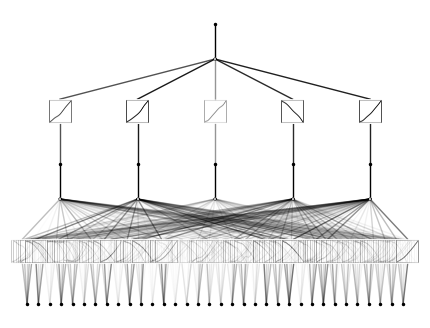

In [69]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot(beta=3, scale=0.5)

Train KAN with sparsity regularization

In [88]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=True)


# train the model
# model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);

| train_loss: nan | test_loss: nan | reg: nan | : 100%|█████████████| 50/50 [00:10<00:00,  4.70it/s]


saving model version 0.1


{'train_loss': [array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan)],
 'test_loss': [array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  array(nan),
  arra

In [366]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")


Test Classification Accuracy: 83.24%


Plot trained KAN

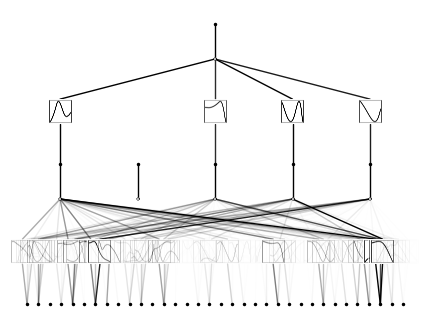

In [493]:
model.plot(beta=3, scale=0.5)

# plt.savefig("KAN_structure.svg", bbox_inches="tight")

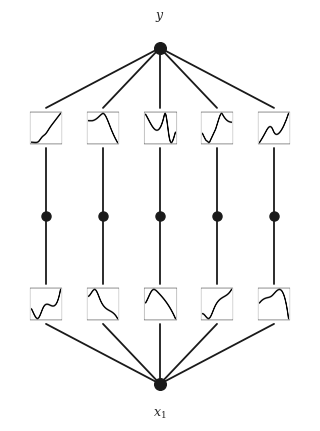

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def redraw_single_io_path_parallel(
    folder="./figures",
    i_in=2,                 # x3 -> 2
    j_out=0,                # 单输出 -> 0
    H=5,                    # 5 条并行通道
    in_label=r"$x_3$",
    out_label=r"$y$",
    scale=1.2,
    fig_w=6.0,
    fig_h=8.0,
    # 版式参数（可微调）
    x_margin=0.12,          # 左右留白
    y_in=0.08,              # x3 点的 y
    y_row0=0.28,            # 第一层小图中心 y
    y_hidden=0.50,          # 隐层圆点 y
    y_row1=0.72,            # 第二层小图中心 y
    y_out=0.92,             # y 点的 y
    img_w=0.12,             # 小图宽（归一化坐标）
    img_h=0.10,             # 小图高（归一化坐标）
    lw=2.6,                 # 连线粗细
    dot_in_size=140,
    dot_h_size=85,
    dot_out_size=140,
    savepath=None
):
    """
    需要文件（与 KAN/MultKAN plot 保存一致）：
      layer0: sp_0_{i_in}_{h}.png , h=0..H-1
      layer1: sp_1_{h}_{j_out}.png , h=0..H-1
    """

    # ====== 画布 ======
    fig = plt.figure(figsize=(fig_w*scale, fig_h*scale))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # ====== 横向位置：5 个通道居中排布 ======
    xs = np.linspace(x_margin, 1 - x_margin, H)

    # ====== 节点坐标 ======
    x_in,  y_in_  = 0.5, y_in
    x_out, y_out_ = 0.5, y_out

    # ====== 画输入/输出圆点 + 标签（居中） ======
    ax.scatter([x_in], [y_in_], s=dot_in_size*scale, c="k", zorder=10)
    ax.text(x_in, y_in_ - 0.06, in_label, ha="center", va="top",
            fontsize=18*scale)

    ax.scatter([x_out], [y_out_], s=dot_out_size*scale, c="k", zorder=10)
    ax.text(x_out, y_out_ + 0.06, out_label, ha="center", va="bottom",
            fontsize=18*scale)

    # ====== 画隐层 5 个圆点 ======
    ax.scatter(xs, [y_hidden]*H, s=dot_h_size*scale, c="k", zorder=10)

    # ====== 工具：在指定中心点贴一张 png 小图 ======
    def place_png(center_x, center_y, png_path, w=img_w, h=img_h):
        left = center_x - w/2
        bottom = center_y - h/2
        if os.path.exists(png_path):
            im = mpimg.imread(png_path)
            ax_img = fig.add_axes([left, bottom, w, h])
            ax_img.imshow(im)
            ax_img.axis("off")
            ax_img.patch.set_alpha(0.0)
        else:
            # 找不到就画红框提示
            rect = plt.Rectangle((left, bottom), w, h, fill=False, lw=1.5, ec="r")
            ax.add_patch(rect)

    # ====== 每个通道：x3 -> 第一层小图 -> 隐层点 -> 第二层小图 -> y ======
    for h in range(H):
        xh = xs[h]

        # 第一层小图（sp_0_{i_in}_{h}）
        p0 = os.path.join(folder, f"sp_0_{i_in}_{h}.png")
        place_png(xh, y_row0, p0)

        # 第二层小图（sp_1_{h}_{j_out}）
        p1 = os.path.join(folder, f"sp_1_{h}_{j_out}.png")
        place_png(xh, y_row1, p1)

        # 关键：连线结构要像你的手绘——每条通道基本竖直（只在最底/最顶扇出）
        # 1) x3 -> 第一层小图（连到小图下边缘中心）
        ax.plot([x_in, xh],
                [y_in_, y_row0 - img_h/2],
                c="k", lw=lw*scale, zorder=2)

        # 2) 第一层小图上边缘中心 -> 隐层点（竖直）
        ax.plot([xh, xh],
                [y_row0 + img_h/2, y_hidden],
                c="k", lw=lw*scale, zorder=2)

        # 3) 隐层点 -> 第二层小图下边缘中心（竖直）
        ax.plot([xh, xh],
                [y_hidden, y_row1 - img_h/2],
                c="k", lw=lw*scale, zorder=2)

        # 4) 第二层小图上边缘中心 -> y（扇出到顶点）
        ax.plot([xh, x_out],
                [y_row1 + img_h/2, y_out_],
                c="k", lw=lw*scale, zorder=2)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ====== 用法示例：只画 x3 (i_in=2) 到 y (j_out=0)，H=5 ======
redraw_single_io_path_parallel(
    folder="./figures",
    i_in=0,
    j_out=0,
    H=5,
    in_label=r"$x_1$",
    out_label=r"$y$",
    scale=0.5,
    savepath=None  # 例如 "single_path_x3_to_y.png"
    # savepath="x1_to_y.svg"
)


Prune KAN and replot

saving model version 0.3


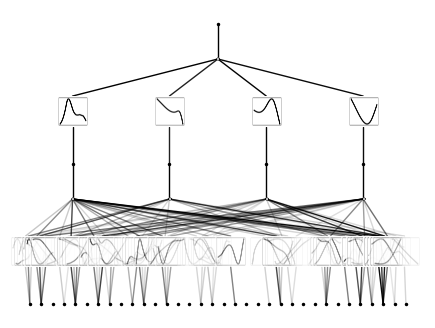

In [523]:
model = model.prune()
model.plot()

Continue training and replot

In [52]:
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False);

| train_loss: 3.11e-01 | test_loss: 3.56e-01 | reg: 2.56e+01 | : 100%|█| 50/50 [00:32<00:00,  1.55it

saving model version 0.3


In [ ]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 74.42%


In [75]:
model = model.refine(10)

saving model version 0.2


In [76]:
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False);

| train_loss: nan | test_loss: nan | reg: nan | : 100%|█████████████| 50/50 [00:06<00:00,  7.62it/s]


saving model version 0.3


In [347]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 83.24%


Automatically or manually set activation functions to be symbolic

In [121]:
mode = "auto" # "manual"

if mode == "manual":
    # manual mode
    model.fix_symbolic(0,0,0,'sin');
    model.fix_symbolic(0,1,0,'x^2');
    model.fix_symbolic(1,0,0,'exp');
elif mode == "auto":
    # automatic mode
    # lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
    lib = ['x','x^2','x^3','x^4','abs','tanh','sin']
    model.auto_symbolic(lib=lib, r2_threshold=0.999)

For (0,0,0) the best fit was x, but r^2 = 0.06346124707803256 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,1) the best fit was x, but r^2 = 0.0863023554795215 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,2) the best fit was x, but r^2 = 0.9539781905903676 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,3) the best fit was x, but r^2 = 0.6153211008536943 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,4) the best fit was x, but r^2 = 0.05863499789733226 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,1,0) the best fit was x, but r^2 = 0.966143170985466 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,1,1) the best fit was x, but r^2 = 0.7930320

Continue training till machine precision

In [ ]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=False);


| train_loss: 4.75e-01 | test_loss: 4.86e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:10<00:00,  4.70it

saving model version 0.4


In [384]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 90.19%


Obtain the symbolic formula

In [1]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

NameError: name 'model' is not defined

[INFO] Font used for plotting: DejaVu Serif


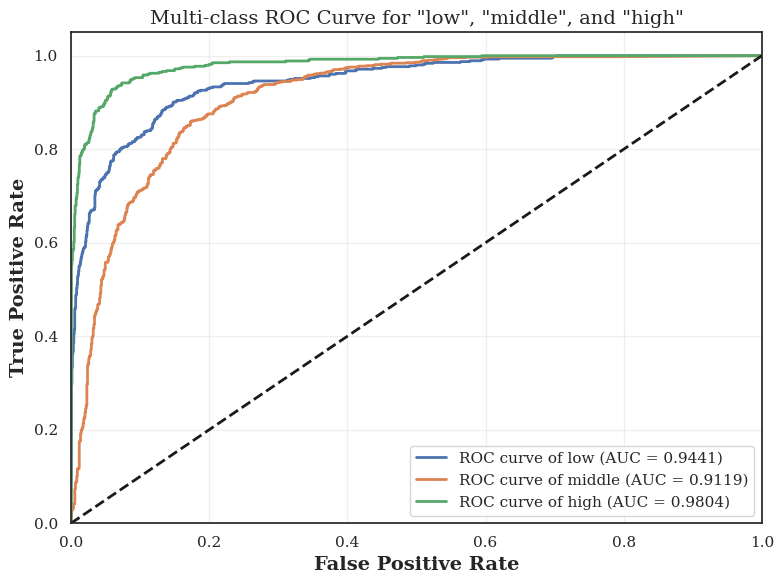

AUC summary:
  low: AUC = 0.944105
  middle: AUC = 0.911899
  high: AUC = 0.980351


In [372]:
# ================================
# Multi-class ROC (One-vs-Rest) + AUC
# Robust font handling (no findfont warning)
# ================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.font_manager as fm
import warnings

# ---------- 1. 安全设置字体（优先 TNR，失败自动回退） ----------
warnings.filterwarnings("ignore", message="findfont:")

def set_times_like_font():
    preferred_fonts = [
        "Times New Roman",   # Windows / Mac
        "Times",             # Linux 常见
        "DejaVu Serif"       # Matplotlib 默认 serif（兜底）
    ]
    available_fonts = {f.name: f.fname for f in fm.fontManager.ttflist}

    for font in preferred_fonts:
        if font in available_fonts:
            plt.rcParams["font.family"] = font
            return font

    # 理论上不会走到这
    plt.rcParams["font.family"] = "serif"
    return "serif"

font_used = set_times_like_font()
print(f"[INFO] Font used for plotting: {font_used}")

# 数学字体同步
plt.rcParams["mathtext.fontset"] = "dejavuserif"

# ---------- 2. 模型预测 ----------
model.eval()
with torch.no_grad():
    y_cont = model(dataset['test_input']).reshape(-1, 1)  # (N,1)

    centers = torch.tensor([1.0, 2.0, 3.0],
                           device=y_cont.device,
                           dtype=y_cont.dtype).view(1, -1)

    scores = -torch.abs(y_cont - centers)   # (N,3)
    probs = torch.softmax(scores, dim=1)    # (N,3)

    y_true = dataset['test_label'].detach().cpu().numpy().reshape(-1).astype(int)
    y_score = probs.detach().cpu().numpy()

# ---------- 3. One-vs-Rest ----------
classes = np.array([1, 2, 3], dtype=int)
y_true_bin = label_binarize(y_true, classes=classes)

# ---------- 4. ROC 计算 + 作图 ----------
class_names = ["low", "middle", "high"]

plt.figure(figsize=(8, 6))
roc_data = {}

for i, name in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    roc_data[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": roc_auc
    }

    plt.plot(
        fpr, tpr,
        linewidth=2,
        label=f"ROC curve of {name} (AUC = {roc_auc:.4f})"
    )

# 随机基线
plt.plot([0, 1], [0, 1], "k--", linewidth=2)

# ---------- 5. 轴标签（加粗） ----------
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate", fontsize=14, fontweight="bold")
plt.ylabel("True Positive Rate",  fontsize=14, fontweight="bold")
plt.title('Multi-class ROC Curve for "low", "middle", and "high"', fontsize=14)

plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 6. AUC 输出 ----------
print("AUC summary:")
for k, v in roc_data.items():
    print(f"  {k}: AUC = {v['auc']:.6f}")




In [373]:
# ================================
# Export ROC data to .mat for MATLAB
# ================================
import scipy.io as sio
import numpy as np

# 假设你已有 roc_data 这个 dict（前面代码已经生成）
# roc_data = {
#   "low":    {"fpr":..., "tpr":..., "thresholds":..., "auc":...},
#   "middle": {...},
#   "high":   {...}
# }

mat_data = {}

for k, v in roc_data.items():
    mat_data[f"fpr_{k}"] = np.asarray(v["fpr"])
    mat_data[f"tpr_{k}"] = np.asarray(v["tpr"])
    mat_data[f"thr_{k}"] = np.asarray(v["thresholds"])
    mat_data[f"auc_{k}"] = np.asarray(v["auc"])

# 保存
sio.savemat("ROC_data_trust_KAN.mat", mat_data)

print("ROC data saved to ROC_data_trust_KAN.mat")


ROC data saved to ROC_data_trust_KAN.mat


In [374]:
# ================================
# Confusion Matrix + metrics + export to .mat
# (Rows = Predicted, Cols = True)  <-- 和你图一致
# ================================
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import scipy.io as sio

# ---- 1) 取测试集预测（与你算 accuracy 的方式一致：round + clamp）
model.eval()
with torch.no_grad():
    y_pred_cont = model(dataset['test_input'])              # (N,1)
    y_pred_cls  = torch.round(y_pred_cont)
    y_pred_cls  = torch.clamp(y_pred_cls, 1, 3).view(-1)    # (N,)
    y_true      = dataset['test_label'].view(-1)            # (N,)

y_true_np = y_true.detach().cpu().numpy().astype(int)
y_pred_np = y_pred_cls.detach().cpu().numpy().astype(int)

classes = np.array([1, 2, 3], dtype=int)  # 1/2/3
class_names = np.array(["Low", "Medium", "High"], dtype=object)

# ---- 2) sklearn confusion_matrix 默认：rows=true, cols=pred
cm_true_pred = confusion_matrix(y_true_np, y_pred_np, labels=classes)  # (3,3)

# ---- 3) 转成你图的布局：rows=predicted, cols=true
cm_pred_true = cm_true_pred.T  # (3,3)

# ---- 4) 计算指标（与该布局一致）
total = cm_pred_true.sum()

# Precision：按“预测为某类”的行统计（row）
row_sum = cm_pred_true.sum(axis=1, keepdims=False)
precision = np.divide(np.diag(cm_pred_true), row_sum, out=np.zeros_like(row_sum, dtype=float), where=row_sum!=0)

# Recall：按“真实为某类”的列统计（col）
col_sum = cm_pred_true.sum(axis=0, keepdims=False)
recall = np.divide(np.diag(cm_pred_true), col_sum, out=np.zeros_like(col_sum, dtype=float), where=col_sum!=0)

accuracy = np.trace(cm_pred_true) / total if total > 0 else 0.0

# 每格占总样本比例（用于显示括号里的百分比）
cm_percent_total = cm_pred_true / total * 100.0 if total > 0 else np.zeros_like(cm_pred_true, dtype=float)

# ---- 5) 导出到 .mat（MATLAB 直接 load）
mat_data = {
    "cm_pred_true": cm_pred_true.astype(np.int32),           # 3x3
    "cm_percent_total": cm_percent_total.astype(np.float64), # 3x3 (% of total)
    "precision": precision.astype(np.float64),               # 3x1
    "recall": recall.astype(np.float64),                     # 3x1
    "accuracy": np.array([accuracy], dtype=np.float64),      # 1x1
    "classes": classes.astype(np.int32),                     # 1x3
    "class_names": class_names                               # 1x3 (cell-like in MATLAB)
}

out_path = "CM_data_trust_KAN.mat"
sio.savemat(out_path, mat_data)
print(f"[OK] Confusion-matrix data saved to: {out_path}")


[OK] Confusion-matrix data saved to: CM_data_trust_KAN.mat
